In [2]:
#from neural_priors.utils.data import get_all_behavioral_data, get_all_subject_ids
import pingouin as pg
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os, pickle
from scipy import stats, odr, optimize
import statsmodels.api as sm
import itertools

In [3]:
plt.rcParams['legend.frameon'] = False
np.set_printoptions(linewidth=140)
pd.set_option('display.width', 170) # 80
pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 70)

In [4]:
#import apc_utils as apc

In [5]:
# from functools import cache
# from cachetools import cached

In [6]:
NARROW = 'narrow'
WIDE = 'wide'
CONDITIONS = [NARROW, WIDE]
#COLORS_COND = {NARROW:'C0', WIDE:'C1'}
COLORS_COND = {NARROW:'#56B4E9', WIDE:'C1'}; THIRD_COLOR = '#55BB55'; FOURTH_COLOR = 'C4' # THIRD_COLOR = '#009E73'; 
M_NARROW = 17.5
M_WIDE = 25.
SD_NARROW = 15./np.sqrt(12)
SD_WIDE   = 30./np.sqrt(12)
W_NARROW = 15.
W_WIDE   = 30.
HW_NARROW = W_NARROW/2
HW_WIDE   = W_WIDE/2

In [7]:
"#00BB00"

'#00BB00'

In [8]:
def quick_ols(y, x, include_intercept=True):
    if not include_intercept:
        model = sm.OLS(y, x)
    else:
        model = sm.OLS(y, sm.add_constant(x))
    return model.fit()

In [318]:
def paired_strip_plot(ax, x1, x2, y1, y2, jitter=0.05,
                      marker='o', markersize=8, col1='C0', col2='C1',
                      color_line='grey', alpha=0.4, line_width=0.5,
                      color_incr_line=None, color_decr_line=None
                      ):
    """
    Creates a paired strip plot on the given axis.
    
    Parameters:
      ax : matplotlib.axes.Axes
          The axis to plot on.
      x1, x2 : float
          The x-axis positions for the two groups.
      y1, y2 : array-like
          The y-values for the two groups. They should have the same length.
      jitter : float, optional
          The standard deviation of the jitter to add to the x positions (default 0.05).
      marker : str, optional
          The marker style for the points (default 'o').
      markersize : int, optional
          The marker size (default 8).
      col1 : str, optional
          The color for the points in group 1 (default 'C0').
      col2 : str, optional
          The color for the points in group 2 (default 'C1').
      color_line : str, optional
          The color for the connecting lines (default 'grey').
      alpha : float, optional
          The transparency for points and lines (default 0.4).
      line_width : float, optional
          The width of the connecting lines (default 0.5).
    """
    
    color_incr_line = color_incr_line or color_line
    color_decr_line = color_decr_line or color_line

    # Create jittered x positions for each group
    xs1 = np.full(len(y1), x1) + np.random.normal(0, jitter, size=len(y1))
    xs2 = np.full(len(y2), x2) + np.random.normal(0, jitter, size=len(y2))

    # Plot the points for both groups with separate colors
    ax.plot(xs1, y1, linestyle='None', marker=marker, markersize=markersize,
            color=col1, alpha=alpha)
    ax.plot(xs2, y2, linestyle='None', marker=marker, markersize=markersize,
            color=col2, alpha=alpha)

    # Connect each paired point with a line
    for xi1, xi2, yi1, yi2 in zip(xs1, xs2, y1, y2):
        c = color_incr_line if yi2 > yi1 else color_decr_line if yi2 < yi1 else color_line
        ax.plot([xi1, xi2], [yi1, yi2], color=c,
                linewidth=line_width, alpha=alpha)

In [10]:
# def obvious_index_filter(df, **kwargs):
#     r = df
#     for k,v in kwargs.items():
#         r = r.xs(v, level=k)
#     return r

def index_filter(df, **kwargs):
    """
    Filter a DataFrame based on index level value(s) and drop levels uniquely determined
    by a single-value filter. Can also filter by column values.

    For a MultiIndex, only those levels filtered by a single element (not list-like)
    that then have only one unique value in the result are dropped.
    For a simple index, if the filtering criterion is a single element and the index
    becomes constant, the index is reset (dropped).

    Parameters:
        df (pd.DataFrame): The DataFrame to filter.
        **kwargs: Each keyword corresponds to an index level name (or column name) and its filter condition.
                  The condition may be a single value or a list/tuple/set of acceptable values.
                  If the key is not an index level, it will be treated as a column name.

    Returns:
        pd.DataFrame: The filtered DataFrame.
    """
    # No filters provided; return the original DataFrame.
    if not kwargs:
        return df

    idx = df.index
    result_df = df

    # Separate index-level filters from column filters
    index_filters = {}
    column_filters = {}
    
    if isinstance(idx, pd.MultiIndex):
        for level, value in kwargs.items():
            if level in idx.names:
                index_filters[level] = value
            elif level in df.columns:
                column_filters[level] = value
            else:
                raise KeyError(f"'{level}' not found in MultiIndex levels {idx.names} or columns.")
    else:
        for level, value in kwargs.items():
            if idx.name == level:
                index_filters[level] = value
            elif level in df.columns:
                column_filters[level] = value
            else:
                raise KeyError(f"'{level}' not found in index or columns.")

    # MultiIndex handling.
    if isinstance(idx, pd.MultiIndex) and index_filters:
        mask = np.ones(len(result_df), dtype=bool)
        # Build the mask for each provided index level.
        for level, value in index_filters.items():
            if not isinstance(value, str) and hasattr(value, '__iter__'): #isinstance(value, (list, tuple, set)):
                mask &= idx.get_level_values(level).isin(value)
            else:
                mask &= (idx.get_level_values(level) == value)
        result_df = result_df[mask]

        # Only drop levels that were filtered with a single value and are constant.
        to_drop = [level for level, value in index_filters.items() 
                   if not isinstance(value, (list, tuple, set)) 
                   and result_df.index.get_level_values(level).nunique() == 1]
        if to_drop:
            # If we're dropping all levels, reset the index instead
            if len(to_drop) == len(result_df.index.names):
                result_df = result_df.reset_index(drop=True)
            else:
                result_df = result_df.droplevel(to_drop)

    # Simple index handling.
    elif index_filters:
        if len(index_filters) > 1:
            raise ValueError("A simple index DataFrame accepts only one filtering criterion.")
        key, value = next(iter(index_filters.items()))
        # Apply the filtering.
        if not isinstance(value, str) and hasattr(value, '__iter__'): # isinstance(value, (list, tuple, set)):
            mask = idx.isin(value)
        else:
            mask = (idx == value)
        result_df = result_df[mask]

        # Drop the index (by resetting it) only if the filter was a single value and the index is constant.
        if not isinstance(value, (list, tuple, set)) and result_df.index.nunique() == 1:
            result_df = result_df.reset_index(drop=True)

    # Column filtering
    for col, value in column_filters.items():
        if not isinstance(value, str) and hasattr(value, '__iter__'): # isinstance(value, (list, tuple, set)):
            result_df = result_df[result_df[col].isin(value)]
        else:
            result_df = result_df[result_df[col] == value]

    return result_df


# Models

In [86]:
#bids_folder = Path('/data/ds-neuralpriors')
pars_ground_truth = pd.read_csv('group_roi-NPCr_desc-groundtruth_parameters 2025-09-03.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_estimates = pd.read_csv('group_roi-NPCr_desc-responses_parameters 2025-09-03.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])

pars = pd.concat([pars_ground_truth, pars_estimates], keys=['ground_truth', 'estimates'], names=['type'], axis=0)

# rename index level subject_id to subject
pars.index.set_names('subject', level='subject_id', inplace=True)

pars.index.set_names('voxel', level=-1, inplace=True)

pars.index.unique(level='smoothed')

pars

parameter                                               mu                   sd           delta_wide      amplitude            baseline                  r2      cvr2
range                                               narrow       wide    narrow      wide     narrow wide    narrow      wide    narrow      wide       nan       nan
type         subject model_label smoothed voxel                                                                                                                      
ground_truth 1       0           True     0      10.698851  10.698851  0.128387  0.128387        1.0  1.0  0.287954  0.287954 -0.117511 -0.117511  0.007678 -0.018960
                                          1      12.097051  12.097051  0.047358  0.047358        1.0  1.0  0.396764  0.396764 -0.512096 -0.512096  0.007553 -0.019339
                                          2      13.019329  13.019329  0.156827  0.156827        1.0  1.0  0.160411  0.160411 -0.514299 -0.514299  0.005133 -0.026036
                                          3      15.027272  15.027272  0.071559  0.071559        1.0  1.0  0.305217  0.305217 -0.310229 -0.310229  0.014921 -0.021961
                                          4      11.410503  11.410503  0.092538  0.092538        1.0  1.0  0.359884  0.359884 -0.109330 -0.109330  0.007671 -0.015200
...                                                    ...        ...       ...       ...        ...  ...       ...       ...       ...       ...       ...       ...
estimates    41      33          True     689    13.448326  16.896652  0.565678  0.728476        2.0  2.0  0.464496  0.518247 -0.045288 -0.045288  0.029204  0.011950
                                          690     9.908031   9.908031  0.152317  0.196154        2.0  2.0  0.108694  0.121272  0.277198  0.277198  0.006743 -0.015981
                                          691    13.634396  17.268791  0.521635  0.671758        2.0  2.0  0.387509  0.432351 -0.075840 -0.075840  0.022160  0.002292
                                          692     8.510156   8.510156  0.498837  0.642400        2.0  2.0  0.241137  0.269041 -0.121465 -0.121465  0.014179 -0.008607
                                          693    13.615266  17.230532  0.599750  0.772355        2.0  2.0  0.331217  0.369545 -0.205013 -0.205013  0.007632 -0.006012

[1160254 rows x 12 columns]

In [81]:
pars.index.get_level_values('subject').unique()

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41], dtype='int64', name='subject')

In [12]:
pars.index.get_level_values('model_label').unique()

Index([0, 1, 2, 3, 4, 5, 12, 14, 15, 18, 25, 26, 27, 28, 29, 30, 31, 32, 33], dtype='int64', name='model_label')

In [13]:
pars_groundtruth_0806 = pd.read_csv('group_roi-NPCr_desc-groundtruth_parameters 2025-08-06.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_groundtruth_0903 = pd.read_csv('group_roi-NPCr_desc-groundtruth_parameters 2025-09-03.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_groundtruth_0513 = pd.read_csv('group_roi-NPCr_desc-groundtruth_parameters 2025-05-13.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_estimates_0903 = pd.read_csv('group_roi-NPCr_desc-responses_parameters 2025-09-03.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_estimates_0806 = pd.read_csv('group_roi-NPCr_desc-responses_parameters 2025-08-06.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_estimates_0513 = pd.read_csv('group_roi-NPCr_desc-responses_parameters 2025-05-13.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
print('% cvR2>0')
print(f'Ground Truth:\tSep3: {(pars_groundtruth_0903.loc[:,15,True].cvr2["nan"] > 0).mean():.4f}, Aug 6: {(pars_groundtruth_0806.loc[:,15,True].cvr2["nan"] > 0).mean():.4f}, May 13: {(pars_groundtruth_0513.loc[:,15,True].cvr2["nan"] > 0).mean():.4f}')
print(f'Estimates:\tSep3: {(pars_estimates_0903.loc[:,15,True].cvr2["nan"] > 0).mean():.4f}, Aug 6: {(pars_estimates_0806.loc[:,15,True].cvr2["nan"] > 0).mean():.4f}, May 13: {(pars_estimates_0513.loc[:,15,True].cvr2["nan"] > 0).mean():.4f}')

% cvR2>0
Ground Truth:	Sep3: 0.2877, Aug 6: 0.2877, May 13: 0.2884
Estimates:	Sep3: 0.3189, Aug 6: 0.3189, May 13: 0.3182


In [14]:
ratiosd_groundtruth_0903 = ( pars_groundtruth_0903.loc[:,15,True].sd.wide / pars_groundtruth_0903.loc[:,15,True].sd.narrow ).groupby('subject_id').first()
ratiosd_groundtruth_0806 = ( pars_groundtruth_0806.loc[:,15,True].sd.wide / pars_groundtruth_0806.loc[:,15,True].sd.narrow ).groupby('subject_id').first()
ratiosd_groundtruth_0513 = ( pars_groundtruth_0513.loc[:,15,True].sd.wide / pars_groundtruth_0513.loc[:,15,True].sd.narrow ).groupby('subject_id').first()
ratiosd_estimates_0903 = ( pars_estimates_0903.loc[:,15,True].sd.wide / pars_estimates_0903.loc[:,15,True].sd.narrow ).groupby('subject_id').first()
ratiosd_estimates_0806 = ( pars_estimates_0806.loc[:,15,True].sd.wide / pars_estimates_0806.loc[:,15,True].sd.narrow ).groupby('subject_id').first()
ratiosd_estimates_0513 = ( pars_estimates_0513.loc[:,15,True].sd.wide / pars_estimates_0513.loc[:,15,True].sd.narrow ).groupby('subject_id').first()
print('MEAN ratio_sd')
print(f'Ground Truth SD Ratios:\tSep 3: {ratiosd_groundtruth_0903.mean():.4f}, Aug 6: {ratiosd_groundtruth_0806.mean():.4f}, May 13: {ratiosd_groundtruth_0513.mean():.4f}')
print(f'Estimates SD Ratios:\tSep 3: {ratiosd_estimates_0903.mean():.4f}, Aug 6: {ratiosd_estimates_0806.mean():.4f}, May 13: {ratiosd_estimates_0513.mean():.4f}')
print('\nMEDIAN ratio_sd')
print(f'Ground Truth SD Ratios:\tSep 3: {ratiosd_groundtruth_0903.median():.4f}, Aug 6: {ratiosd_groundtruth_0806.median():.4f}, May 13: {ratiosd_groundtruth_0513.median():.4f}')
print(f'Estimates SD Ratios:\tSep 3: {ratiosd_estimates_0903.median():.4f}, Aug 6: {ratiosd_estimates_0806.median():.4f}, May 13: {ratiosd_estimates_0513.median():.4f}')

MEAN ratio_sd
Ground Truth SD Ratios:	Sep 3: 1.2878, Aug 6: 1.2878, May 13: 1.2651
Estimates SD Ratios:	Sep 3: 1.3048, Aug 6: 1.3048, May 13: 1.2715

MEDIAN ratio_sd
Ground Truth SD Ratios:	Sep 3: 1.3093, Aug 6: 1.3093, May 13: 1.2877
Estimates SD Ratios:	Sep 3: 1.3212, Aug 6: 1.3212, May 13: 1.3026


In [15]:
ytype = 'ground_truth'
da = index_filter(pars, smoothed=True, type=ytype)
da['cvr2_pos'] = da.cvr2 > 0
rez = da.groupby(['subject', 'model_label']).cvr2_pos.mean()
rez = rez.unstack()
rez

model_label,0,1,2,3,4,5,12,14,15,18,25,26,27,28,29,30,31,32,33
subject,,,,,,,,,,,,,,,,,,,
1,0.118029,0.128405,0.102464,0.093385,0.140078,0.110246,0.133593,0.116732,0.118029,0.103761,0.160830,0.114137,0.146563,0.125811,0.141375,0.111543,0.155642,0.143969,0.143969
2,0.127907,0.124419,0.090698,0.106977,0.125581,0.108140,0.086047,0.086047,0.118605,0.094186,0.105814,0.109302,0.102326,0.117442,0.096512,0.117442,0.115116,0.105814,0.117442
3,0.070028,0.061625,0.040616,0.040616,0.065826,0.043417,0.054622,0.032213,0.040616,0.047619,0.042017,0.046218,0.039216,0.040616,0.030812,0.032213,0.047619,0.026611,0.040616
4,0.298065,0.305806,0.245161,0.209032,0.308387,0.280000,0.249032,0.243871,0.282581,0.274839,0.313548,0.272258,0.291613,0.278710,0.294194,0.243871,0.312258,0.291613,0.304516
5,0.165436,0.168390,0.078287,0.094535,0.175775,0.051699,0.135894,0.124077,0.181684,0.118168,0.177253,0.158050,0.152142,0.131462,0.152142,0.132939,0.192024,0.172821,0.172821
6,0.196273,0.240994,0.188820,0.191304,0.257143,0.214907,0.285714,0.318012,0.350311,0.277019,0.346584,0.180124,0.259627,0.218634,0.257143,0.217391,0.334161,0.311801,0.320497
7,0.445067,0.434978,0.467489,0.419283,0.449552,0.447309,0.452915,0.426009,0.477578,0.461883,0.471973,0.437220,0.440583,0.437220,0.437220,0.410314,0.465247,0.450673,0.469731
8,0.366352,0.331761,0.347484,0.279874,0.360063,0.345912,0.336478,0.319182,0.369497,0.372642,0.397799,0.316038,0.339623,0.320755,0.333333,0.290881,0.393082,0.360063,0.391509
9,0.442700,0.452119,0.445840,0.365777,0.458399,0.419152,0.463108,0.412873,0.463108,0.447410,0.466248,0.431711,0.428571,0.427002,0.431711,0.390895,0.470958,0.427002,0.463108


In [16]:
rez.columns

Index([0, 1, 2, 3, 4, 5, 12, 14, 15, 18, 25, 26, 27, 28, 29, 30, 31, 32, 33], dtype='int64', name='model_label')

In [17]:
da = index_filter(pars, smoothed=True, type='estimates')
da['cvr2_pos'] = da.cvr2 > 0
rez_est = da.groupby(['subject', 'model_label']).cvr2_pos.mean()
rez_est = rez_est.unstack()
#rez_est

In [18]:
rez_est

model_label,0,1,2,3,4,5,12,14,15,18,25,26,27,28,29,30,31,32,33
subject,,,,,,,,,,,,,,,,,,,
1,0.151751,0.123217,0.101167,0.103761,0.136187,0.112840,0.121920,0.125811,0.137484,0.132296,0.150454,1.000000,0.138781,0.125811,0.137484,0.137484,0.150454,0.143969,0.159533
2,0.116279,0.180233,0.167442,0.140698,0.186047,0.182558,0.125581,0.155814,0.166279,0.154651,0.167442,0.173256,0.177907,0.172093,0.165116,0.141860,0.172093,0.162791,0.172093
3,0.085434,0.121849,0.099440,0.049020,0.121849,0.106443,0.064426,0.061625,0.107843,0.091036,0.106443,0.096639,0.086835,0.091036,0.084034,0.067227,0.119048,0.082633,0.109244
4,0.219355,0.246452,0.174194,0.214194,0.252903,0.240000,0.285161,0.298065,0.345806,0.318710,0.360000,0.289032,0.330323,0.300645,0.325161,0.276129,0.332903,0.292903,0.321290
5,0.168390,0.153619,0.079764,0.088626,0.158050,0.116691,0.146233,0.159527,0.192024,0.146233,0.192024,0.166913,0.192024,0.162482,0.190547,0.165436,0.197932,0.175775,0.174298
6,0.180124,0.176398,0.142857,0.142857,0.176398,0.165217,0.175155,0.207453,0.275776,0.237267,0.263354,0.090683,0.202484,0.088199,0.198758,0.116770,0.244720,0.226087,0.238509
7,0.426009,0.393498,0.441704,0.378924,0.412556,0.414798,0.412556,0.395740,0.461883,0.449552,0.466368,0.423767,0.426009,0.427130,0.417040,0.364350,0.461883,0.445067,0.459641
8,0.342767,0.407233,0.356918,0.305031,0.424528,0.413522,0.353774,0.349057,0.446541,0.408805,0.438679,0.375786,0.413522,0.400943,0.404088,0.341195,0.444969,0.426101,0.444969
9,0.483516,0.477237,0.475667,0.430141,0.492936,0.488226,0.494505,0.466248,0.455259,0.448980,0.477237,0.474097,0.422292,0.444270,0.427002,0.450549,0.483516,0.463108,0.458399


In [19]:
rez_est.columns

Index([0, 1, 2, 3, 4, 5, 12, 14, 15, 18, 25, 26, 27, 28, 29, 30, 31, 32, 33], dtype='int64', name='model_label')

In [76]:
compare_gt_vs_est = []
for mo in rez_est.columns:
    ttest_result = pg.ttest(x=rez[mo], y=rez_est[mo], paired=True ) #, alternative='less')
    # Append the results to the list, including the t-test result as a row
    compare_gt_vs_est.append({
        'Model': mo,
        'Mean gt': rez[mo].mean(),
        'Mean est': rez_est[mo].mean(),
        **ttest_result.iloc[0].to_dict()  # Add all columns from the t-test result
    })
compare_gt_vs_est = pd.DataFrame(compare_gt_vs_est).set_index('Model')
compare_gt_vs_est

,Mean gt,Mean est,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model,,,,,,,,,,
0,0.259595,0.279088,-1.882874,38,two-sided,0.067390,"[-0.04, 0.0]",0.108607,0.852,0.101402
1,0.275806,0.298597,-2.407027,38,two-sided,0.021049,"[-0.04, -0.0]",0.128645,2.195,0.122694
2,0.262671,0.282952,-1.862133,38,two-sided,0.070331,"[-0.04, 0.0]",0.110401,0.824,0.103152
3,0.236117,0.259048,-2.552211,38,two-sided,0.014847,"[-0.04, -0.0]",0.136085,2.942,0.131582
4,0.282406,0.301325,-1.919531,38,two-sided,0.062449,"[-0.04, 0.0]",0.105450,0.905,0.098397
5,0.265763,0.291914,-2.573004,38,two-sided,0.014111,"[-0.05, -0.01]",0.139926,3.071,0.136381
12,0.268072,0.283433,-1.534894,38,two-sided,0.133095,"[-0.04, 0.0]",0.085340,0.506,0.081459
14,0.259189,0.285912,-3.125457,38,two-sided,0.003395,"[-0.04, -0.01]",0.151108,10.466,0.151161
15,0.286667,0.315511,-2.892568,38,two-sided,0.006292,"[-0.05, -0.01]",0.156980,6.124,0.159404


In [77]:
compare_gt_vs_est_chi2 = []
for mo in rez_est.columns:
    ttest_result = pg.(x=rez[mo], y=rez_est[mo], paired=True ) #, alternative='less')
    # Append the results to the list, including the t-test result as a row
    compare_gt_vs_est_chi2.append({
        'Model': mo,
        'Mean gt': rez[mo].mean(),
        'Mean est': rez_est[mo].mean(),
        **ttest_result.iloc[0].to_dict()  # Add all columns from the t-test result
    })
compare_gt_vs_est_chi2 = pd.DataFrame(compare_gt_vs_est_chi2).set_index('Model')
compare_gt_vs_est_chi2

,Mean gt,Mean est,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model,,,,,,,,,,
0,0.259595,0.279088,-1.882874,38,two-sided,0.067390,"[-0.04, 0.0]",0.108607,0.852,0.101402
1,0.275806,0.298597,-2.407027,38,two-sided,0.021049,"[-0.04, -0.0]",0.128645,2.195,0.122694
2,0.262671,0.282952,-1.862133,38,two-sided,0.070331,"[-0.04, 0.0]",0.110401,0.824,0.103152
3,0.236117,0.259048,-2.552211,38,two-sided,0.014847,"[-0.04, -0.0]",0.136085,2.942,0.131582
4,0.282406,0.301325,-1.919531,38,two-sided,0.062449,"[-0.04, 0.0]",0.105450,0.905,0.098397
5,0.265763,0.291914,-2.573004,38,two-sided,0.014111,"[-0.05, -0.01]",0.139926,3.071,0.136381
12,0.268072,0.283433,-1.534894,38,two-sided,0.133095,"[-0.04, 0.0]",0.085340,0.506,0.081459
14,0.259189,0.285912,-3.125457,38,two-sided,0.003395,"[-0.04, -0.01]",0.151108,10.466,0.151161
15,0.286667,0.315511,-2.892568,38,two-sided,0.006292,"[-0.05, -0.01]",0.156980,6.124,0.159404


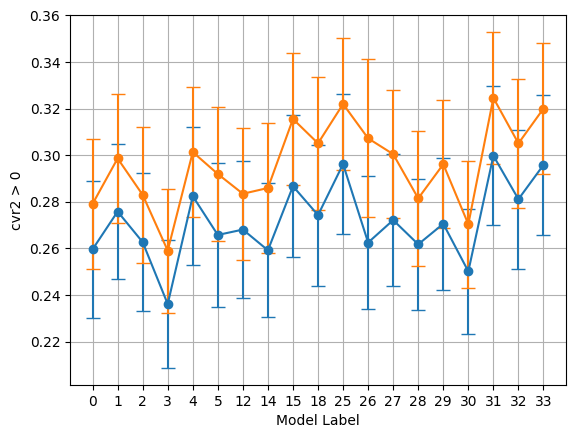

In [21]:
# plt.errorbar(x=rez.columns, y=rez.mean(), yerr=rez.sem(), fmt='-o', capsize=5)
# plt.errorbar(x=rez_est.columns, y=rez_est.mean(), yerr=rez_est.sem(), fmt='-o', capsize=5)
plt.errorbar(x=np.arange(100,100+len(rez.columns)), y=rez.mean(), yerr=rez.sem(), fmt='-o', capsize=5)
plt.errorbar(x=np.arange(100,100+len(rez.columns)), y=rez_est.mean(), yerr=rez_est.sem(), fmt='-o', capsize=5)
plt.xlabel('Model Label')
plt.ylabel('cvr2 > 0')
plt.grid()
plt.xticks(np.arange(100,100+len(rez.columns)));
plt.gca().set_xticklabels(rez.columns);

In [22]:
compare_gt_vs_est.loc[4]

Mean gt            0.282406
Mean est           0.301325
T                 -1.919531
dof                      38
alternative       two-sided
p-val              0.062449
CI95%          [-0.04, 0.0]
cohen-d             0.10545
BF10                  0.905
power              0.098397
Name: 4, dtype: object

In [23]:
compare_res_gt = []
# Iterate over the model pairs and perform paired t-tests
# for (mo1, mo2) in [(4, 12), (4, 14), (4, 15), (18, 4), (25,31)]:
for (mo1, mo2) in itertools.combinations([0, 1, 2, 3, 4, 5, 14, 15, 18, 25, 31, 32, 33], 2):
    ttest_result = pg.ttest(x=rez[mo1], y=rez[mo2], paired=True)
    # Append the results to the list, including the t-test result as a row
    compare_res_gt.append({
        'Model1': mo1,
        'Model2': mo2,
        'Mean Model 1': rez[mo1].mean(),
        'Mean Model 2': rez[mo2].mean(),
        **ttest_result.iloc[0].to_dict()  # Add all columns from the t-test result
    })
compare_res_gt = pd.DataFrame(compare_res_gt)
compare_res_gt = compare_res_gt.set_index(['Model1', 'Model2'])
compare_res_gt

Mean Model 1  Mean Model 2         T  dof alternative         p-val           CI95%   cohen-d       BF10     power
Model1 Model2                                                                                                                    
0      1           0.259595      0.275806 -2.878277   38   two-sided  6.529474e-03   [-0.03, -0.0]  0.088986      5.931  0.084249
       2           0.259595      0.262671 -0.512249   38   two-sided  6.114413e-01   [-0.02, 0.01]  0.016646      0.195  0.051178
       3           0.259595      0.236117  3.490015   38   two-sided  1.239554e-03    [0.01, 0.04]  0.132193      25.42  0.126865
       4           0.259595      0.282406 -4.214098   38   two-sided  1.488568e-04  [-0.03, -0.01]  0.123851    170.475  0.117249
       5           0.259595      0.265763 -0.997531   38   two-sided  3.248168e-01   [-0.02, 0.01]  0.032670      0.274  0.054545
...                     ...           ...       ...  ...         ...           ...             ...       ...        ...       ...
25     32          0.296175      0.281107  4.693114   38   two-sided  3.445974e-05    [0.01, 0.02]  0.080370    647.245  0.077853
       33          0.296175      0.295812  0.139398   38   two-sided  8.898716e-01    [-0.0, 0.01]  0.001932      0.174  0.050016
31     32          0.299754      0.281107  6.411029   38   two-sided  1.556739e-07    [0.01, 0.02]  0.099822  9.723e+04  0.093274
       33          0.299754      0.295812  2.714824   38   two-sided  9.918061e-03     [0.0, 0.01]  0.021093      4.143  0.051892
32     33          0.281107      0.295812 -5.418128   38   two-sided  3.573918e-06  [-0.02, -0.01]  0.078738   5229.678  0.076719

[78 rows x 10 columns]

In [24]:
compare_res_est = []
# Iterate over the model pairs and perform paired t-tests
#for (mo1, mo2) in [(4, 12), (4, 14), (4, 15), (18, 4)]:
for (mo1, mo2) in itertools.combinations([0, 1, 2, 3, 4, 5, 14, 15, 18, 25, 31, 32, 33], 2):
    ttest_result = pg.ttest(x=rez_est[mo1], y=rez_est[mo2], paired=True)
    # Append the results to the list, including the t-test result as a row
    compare_res_est.append({
        'Model1': mo1,
        'Model2': mo2,
        'Mean Model 1': rez_est[mo1].mean(),
        'Mean Model 2': rez_est[mo2].mean(),
        **ttest_result.iloc[0].to_dict()  # Add all columns from the t-test result
    })
compare_res_est = pd.DataFrame(compare_res_est)
compare_res_est = compare_res_est.set_index(['Model1', 'Model2'])
compare_res_est

Mean Model 1  Mean Model 2         T  dof alternative         p-val           CI95%   cohen-d       BF10     power
Model1 Model2                                                                                                                    
0      1           0.279088      0.298597 -2.989508   38   two-sided  4.879835e-03  [-0.03, -0.01]  0.111870      7.631  0.104606
       2           0.279088      0.282952 -0.563331   38   two-sided  5.765187e-01   [-0.02, 0.01]  0.021665        0.2  0.051996
       3           0.279088      0.259048  2.477756   38   two-sided  1.778123e-02     [0.0, 0.04]  0.117554      2.527  0.110432
       4           0.279088      0.301325 -3.633257   38   two-sided  8.242335e-04  [-0.03, -0.01]  0.127370     36.545  0.121224
       5           0.279088      0.291914 -1.995938   38   two-sided  5.314412e-02    [-0.03, 0.0]  0.072274      1.029  0.072464
...                     ...           ...       ...  ...         ...           ...             ...       ...        ...       ...
25     32          0.321951      0.305058  4.141841   38   two-sided  1.849665e-04    [0.01, 0.03]  0.096225    140.021  0.090157
       33          0.321951      0.319992  0.642586   38   two-sided  5.243511e-01    [-0.0, 0.01]  0.011088      0.209  0.050522
31     32          0.324579      0.305058  6.117373   38   two-sided  3.929561e-07    [0.01, 0.03]  0.111450  4.086e+04  0.104189
       33          0.324579      0.319992  2.355788   38   two-sided  2.374538e-02     [0.0, 0.01]  0.026023      1.985  0.052881
32     33          0.305058      0.319992 -4.900184   38   two-sided  1.812523e-05  [-0.02, -0.01]  0.085478   1167.429  0.081563

[78 rows x 10 columns]

In [25]:
compare_res_est

Mean Model 1  Mean Model 2         T  dof alternative         p-val           CI95%   cohen-d       BF10     power
Model1 Model2                                                                                                                    
0      1           0.279088      0.298597 -2.989508   38   two-sided  4.879835e-03  [-0.03, -0.01]  0.111870      7.631  0.104606
       2           0.279088      0.282952 -0.563331   38   two-sided  5.765187e-01   [-0.02, 0.01]  0.021665        0.2  0.051996
       3           0.279088      0.259048  2.477756   38   two-sided  1.778123e-02     [0.0, 0.04]  0.117554      2.527  0.110432
       4           0.279088      0.301325 -3.633257   38   two-sided  8.242335e-04  [-0.03, -0.01]  0.127370     36.545  0.121224
       5           0.279088      0.291914 -1.995938   38   two-sided  5.314412e-02    [-0.03, 0.0]  0.072274      1.029  0.072464
...                     ...           ...       ...  ...         ...           ...             ...       ...        ...       ...
25     32          0.321951      0.305058  4.141841   38   two-sided  1.849665e-04    [0.01, 0.03]  0.096225    140.021  0.090157
       33          0.321951      0.319992  0.642586   38   two-sided  5.243511e-01    [-0.0, 0.01]  0.011088      0.209  0.050522
31     32          0.324579      0.305058  6.117373   38   two-sided  3.929561e-07    [0.01, 0.03]  0.111450  4.086e+04  0.104189
       33          0.324579      0.319992  2.355788   38   two-sided  2.374538e-02     [0.0, 0.01]  0.026023      1.985  0.052881
32     33          0.305058      0.319992 -4.900184   38   two-sided  1.812523e-05  [-0.02, -0.01]  0.085478   1167.429  0.081563

[78 rows x 10 columns]

In [26]:
index_filter(compare_res_est, Model2=4,)

,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,,,,,,,,,,
0,0.279088,0.301325,-3.633257,38,two-sided,8.242335e-04,"[-0.03, -0.01]",0.127370,36.545,0.121224
1,0.298597,0.301325,-1.407472,38,two-sided,1.674151e-01,"[-0.01, 0.0]",0.015684,0.428,0.051045
2,0.282952,0.301325,-3.186236,38,two-sided,2.879455e-03,"[-0.03, -0.01]",0.103260,12.088,0.096368
3,0.259048,0.301325,-8.258465,38,two-sided,5.234141e-10,"[-0.05, -0.03]",0.248617,2.104e+07,0.327867


In [27]:
index_filter(compare_res_est, Model2=5,)

,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,,,,,,,,,,
0,0.279088,0.291914,-1.995938,38,two-sided,5.314412e-02,"[-0.03, 0.0]",0.072274,1.029,0.072464
1,0.298597,0.291914,1.687191,38,two-sided,9.976012e-02,"[-0.0, 0.01]",0.037786,0.629,0.056086
2,0.282952,0.291914,-1.974131,38,two-sided,5.566848e-02,"[-0.02, 0.0]",0.049582,0.992,0.060504
3,0.259048,0.291914,-5.836502,38,two-sided,9.542291e-07,"[-0.04, -0.02]",0.189978,1.785e+04,0.211787
4,0.301325,0.291914,2.592253,38,two-sided,1.345899e-02,"[0.0, 0.02]",0.053155,3.196,0.062084


In [28]:
1.345899e-02

0.01345899

In [29]:
compare_res_est.reset_index()[(compare_res_est.reset_index().Model1 == 18) | (compare_res_est.reset_index().Model2 == 18)].set_index(['Model1', 'Model2'])

,,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,Model2,,,,,,,,,,
0,18,0.279088,0.305074,-3.370299,38,two-sided,1.734544e-03,"[-0.04, -0.01]",0.147224,18.88,0.145890
1,18,0.298597,0.305074,-1.369453,38,two-sided,1.788971e-01,"[-0.02, 0.0]",0.036826,0.409,0.055779
2,18,0.282952,0.305074,-3.308126,38,two-sided,2.061252e-03,"[-0.04, -0.01]",0.123026,16.214,0.116334
3,18,0.259048,0.305074,-8.871793,38,two-sided,8.522324e-11,"[-0.06, -0.04]",0.267562,1.183e+08,0.370397
4,18,0.301325,0.305074,-0.801768,38,two-sided,4.276727e-01,"[-0.01, 0.01]",0.021289,0.233,0.051927
5,18,0.291914,0.305074,-2.419512,38,two-sided,2.043490e-02,"[-0.02, -0.0]",0.073543,2.25,0.073269
14,18,0.285912,0.305074,-5.557298,38,two-sided,2.304495e-06,"[-0.03, -0.01]",0.108738,7858.129,0.101529
15,18,0.315511,0.305074,2.940512,38,two-sided,5.551349e-03,"[0.0, 0.02]",0.058903,6.824,0.064861
18,25,0.305074,0.321951,-4.020461,38,two-sided,2.657435e-04,"[-0.03, -0.01]",0.094945,100.915,0.089077


In [30]:
compare_res_est.reset_index()[(compare_res_est.reset_index().Model1 == 31) | (compare_res_est.reset_index().Model2 == 31)].set_index(['Model1', 'Model2'])

,,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,Model2,,,,,,,,,,
0,31,0.279088,0.324579,-5.699292,38,two-sided,1.471962e-06,"[-0.06, -0.03]",0.258680,1.192e+04,0.350217
1,31,0.298597,0.324579,-5.122853,38,two-sided,9.039736e-06,"[-0.04, -0.02]",0.148263,2216.297,0.147286
2,31,0.282952,0.324579,-5.191272,38,two-sided,7.294156e-06,"[-0.06, -0.03]",0.232319,2702.026,0.293004
3,31,0.259048,0.324579,-10.325412,38,two-sided,1.391496e-12,"[-0.08, -0.05]",0.382431,6.02e+09,0.643437
4,31,0.301325,0.324579,-5.058881,38,two-sided,1.104442e-05,"[-0.03, -0.01]",0.132543,1842.339,0.127284
5,31,0.291914,0.324579,-5.064044,38,two-sided,1.086745e-05,"[-0.05, -0.02]",0.183198,1869.99,0.200201
14,31,0.285912,0.324579,-10.475808,38,two-sided,9.233215e-13,"[-0.05, -0.03]",0.220234,8.915e+09,0.268357
15,31,0.315511,0.324579,-5.079256,38,two-sided,1.036221e-05,"[-0.01, -0.01]",0.051364,1953.932,0.061278
18,31,0.305074,0.324579,-6.328995,38,two-sided,2.015734e-07,"[-0.03, -0.01]",0.109976,7.632e+04,0.102735


In [31]:
pg.ttest(x=rez_est[4], y=rez_est[5], paired=True, alternative='greater')

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,2.592253,38,greater,0.006729,"[0.0, inf]",0.053155,6.392,0.093623


## Figure S1

In [32]:
# Model 1: delta_wide is 2
# model 2: delta_wide is free but same across voxels
# model 4: delta_wide is 2 and identity below 10
# model 5: delta_wide is fitted, same across voxels, but identity below 10
# ===> Compare 4 vs 1, and 5 vs 2
index_filter(compare_res_est, Model1=[1,2,4,5], Model2=[1,2,4,5])

Mean Model 1  Mean Model 2         T  dof alternative     p-val           CI95%   cohen-d    BF10     power
Model1 Model2                                                                                                             
1      2           0.298597      0.282952  2.796163   38   two-sided  0.008068     [0.0, 0.03]  0.088022   4.944  0.083500
       4           0.298597      0.301325 -1.407472   38   two-sided  0.167415    [-0.01, 0.0]  0.015684   0.428  0.051045
       5           0.298597      0.291914  1.687191   38   two-sided  0.099760    [-0.0, 0.01]  0.037786   0.629  0.056086
2      4           0.282952      0.301325 -3.186236   38   two-sided  0.002879  [-0.03, -0.01]  0.103260  12.088  0.096368
       5           0.282952      0.291914 -1.974131   38   two-sided  0.055668    [-0.02, 0.0]  0.049582   0.992  0.060504
4      5           0.301325      0.291914  2.592253   38   two-sided  0.013459     [0.0, 0.02]  0.053155   3.196  0.062084

In [33]:
index_filter(compare_res_gt, Model1=[1,2,4,5], Model2=[1,2,4,5])

Mean Model 1  Mean Model 2         T  dof alternative     p-val           CI95%   cohen-d    BF10     power
Model1 Model2                                                                                                             
1      2           0.275806      0.262671  2.962197   38   two-sided  0.005244     [0.0, 0.02]  0.071720   7.169  0.072117
       4           0.275806      0.282406 -2.631460   38   two-sided  0.012216   [-0.01, -0.0]  0.036162    3.47  0.055572
       5           0.275806      0.265763  2.129636   38   two-sided  0.039739     [0.0, 0.02]  0.053653     1.3  0.062313
2      4           0.262671      0.282406 -3.853235   38   two-sided  0.000435  [-0.03, -0.01]  0.106597  64.706  0.099478
       5           0.262671      0.265763 -0.713904   38   two-sided  0.479649   [-0.01, 0.01]  0.016297   0.219  0.051129
4      5           0.282406      0.265763  3.857624   38   two-sided  0.000430    [0.01, 0.03]  0.087996  65.458  0.083480

In [34]:
pd.concat([pg.ttest(x=rez_est[1], y=rez_est[4], paired=True, alternative='less'),
           pg.ttest(x=rez_est[2], y=rez_est[5], paired=True, alternative='less'),
           pg.ttest(x=rez[1], y=rez[4], paired=True, alternative='less'),
           pg.ttest(x=rez[2], y=rez[5], paired=True, alternative='less')],
          keys=['1 vs 4 - Est', '2 vs 5 - Est', '1 vs 4 - gt', '2 vs 5 - gt'])

,,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
1 vs 4 - Est,T-test,-1.407472,38,less,0.083708,"[-inf, 0.0]",0.015684,0.857,0.060735
2 vs 5 - Est,T-test,-1.974131,38,less,0.027834,"[-inf, -0.0]",0.049582,1.983,0.090010
1 vs 4 - gt,T-test,-2.631460,38,less,0.006108,"[-inf, -0.0]",0.036162,6.939,0.077366
2 vs 5 - gt,T-test,-0.713904,38,less,0.239824,"[-inf, 0.0]",0.016297,0.438,0.061188


In [35]:
# Model 32: like model 31, but free amplitudes
# Model 33: Like model 31, but subject-specific amplitude ratios
# ===> Compare 32 vs 31, and 33 vs 31
index_filter(compare_res_est, Model1=[31], Model2=[32,33])

Mean Model 1  Mean Model 2         T  dof alternative         p-val         CI95%   cohen-d       BF10     power
Model1 Model2                                                                                                                  
31     32          0.324579      0.305058  6.117373   38   two-sided  3.929561e-07  [0.01, 0.03]  0.111450  4.086e+04  0.104189
       33          0.324579      0.319992  2.355788   38   two-sided  2.374538e-02   [0.0, 0.01]  0.026023      1.985  0.052881

In [36]:
index_filter(compare_res_gt, Model1=[31], Model2=[32,33])

Mean Model 1  Mean Model 2         T  dof alternative         p-val         CI95%   cohen-d       BF10     power
Model1 Model2                                                                                                                  
31     32          0.299754      0.281107  6.411029   38   two-sided  1.556739e-07  [0.01, 0.02]  0.099822  9.723e+04  0.093274
       33          0.299754      0.295812  2.714824   38   two-sided  9.918061e-03   [0.0, 0.01]  0.021093      4.143  0.051892

In [37]:
pd.concat([pg.ttest(x=rez_est[32], y=rez_est[31], paired=True,), # alternative='less'),
           pg.ttest(x=rez_est[33], y=rez_est[31], paired=True,), # alternative='less'),
           pg.ttest(x=rez[32], y=rez[31], paired=True,), # alternative='less'),
           pg.ttest(x=rez[33], y=rez[31], paired=True,)], # alternative='less')],
          keys=['32 vs 31 - Est', '33 vs 31 - Est', '32 vs 31 - gt', '33 vs 31 - gt'])

,,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
32 vs 31 - Est,T-test,-6.117373,38,two-sided,3.929561e-07,"[-0.03, -0.01]",0.111450,4.086e+04,0.104189
33 vs 31 - Est,T-test,-2.355788,38,two-sided,2.374538e-02,"[-0.01, -0.0]",0.026023,1.985,0.052881
32 vs 31 - gt,T-test,-6.411029,38,two-sided,1.556739e-07,"[-0.02, -0.01]",0.099822,9.723e+04,0.093274
33 vs 31 - gt,T-test,-2.714824,38,two-sided,9.918061e-03,"[-0.01, -0.0]",0.021093,4.143,0.051892


In [38]:
def star_line(ax, x1, x2, y, pval, star_size=10, star_offset=0, star_color='black', line_color='black', line_width=1, vertical_lines_length=0.05, ):
    """
    Draws a star and a line between two x positions at a specified y position on the given axis.
    """
    # Determine the number of stars based on the p-value
    stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    
    # Draw the stars at the specified position
    ax.text((x1 + x2) / 2, y + star_offset, stars, fontsize=star_size, color=star_color, ha='center', va='bottom')

    # Draw a line between the two x positions at the specified y position
    ax.plot([x1, x2], [y, y], color=line_color, linewidth=line_width)

    if vertical_lines_length != 0:
        # Draw vertical lines at the ends of the horizontal line
        ax.plot([x1, x1], [y - vertical_lines_length, y], color=line_color, linewidth=line_width)
        ax.plot([x2, x2], [y - vertical_lines_length, y], color=line_color, linewidth=line_width)

In [39]:
from matplotlib.transforms import ScaledTranslation

0.002728571649412037
1,4 est $P=0.17$, $t(38)=-1.41$
2,5 est $P=0.056$, $t(38)=-1.97$
1,4  gt $P=0.012$, $t(38)=-2.63$
2,5  gt $P=0.48$, $t(38)=-0.71$
##
2,4 est $t(38)=-3.19$, $P=0.0029$
2,4  gt $t(38)=-3.85$, $P=0.00044$
##
32,31 est $P=3.9e-07$, $t(38)=-6.12$
33,31 est $P=0.024$, $t(38)=-2.36$
32,31  gt $P=1.6e-07$, $t(38)=-6.41$
33,31  gt $P=0.0099$, $t(38)=-2.71$


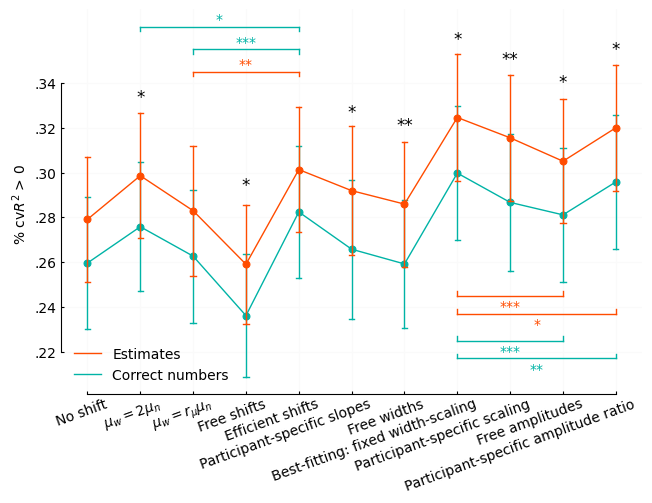

In [82]:
fig, ax = plt.subplots(figsize=(7.5, 5))
C_GT = plt.cm.winter(.7)
C_EST = plt.cm.autumn(.3)
modelz = dict( [(0, 'No shift'),(1, '$\mu_w = 2 \mu_n$'), (2, '$\mu_w = r_\mu \mu_n$'),
                                (3, 'Free shifts'), (4, 'Efficient shifts'), (5, 'Participant-specific slopes'), 
                                (14, 'Free widths'), (31, 'Best-fitting: fixed width-scaling'), (15, 'Participant-specific scaling'),
                                (32, 'Free amplitudes'), (33, 'Participant-specific amplitude ratio'),
                                (18, 'Participant-specific shift and width scaling'),
                                ] )
x_model = {mo:i for i,mo in enumerate(modelz.keys()) } # absissa positions for the models
#(4, 'No width change'),
these_rez_est = rez_est.loc[:,list(modelz.keys())].rename(columns=modelz)
these_rez = rez.loc[:,list(modelz.keys())].rename(columns=modelz)
# combine these_rez, these_rez_est, adding an index level
these_rez_combined = pd.concat([these_rez, these_rez_est], axis=1, keys=['gt', 'est'], names=['type'])
# these_comp = compare_gt_vs_est.loc[modelz.keys()].rename(modelz)
# these_comp
sns.pointplot(these_rez, errorbar='se', color=C_GT, markersize=5, linewidth=1, ax=ax, capsize=.1)
sns.pointplot(these_rez_est, errorbar='se', color=C_EST, markersize=5, linewidth=1, ax=ax, capsize=.1)
ax.set_xlabel(None)
handles = [plt.Line2D([0], [0], color=C_EST, lw=1, label='Estimates'),
           plt.Line2D([0], [0], color=C_GT, lw=1, label='Correct numbers')]
ax.legend(handles=handles, loc='lower left')
#### x ticks labels positions
ax.tick_params(axis='both', tickdir='in', length=2)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor");
# Create offset transform
dx = 12./72.; dy = 2/72. 
offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
#
ax.set_yticks([.22, .24, .26, .28, .3, .32, .34])
ax.set_yticklabels(['.22', '.24', '.26', '.28', '.30', '.32', '.34'])
ax.set_ylabel('% cv$R^2$ > 0', y=.6, ha='right')
#
ax.spines.left.set_bounds((.22, .34))
ax.spines.bottom.set_bounds((0, len(modelz)-1))
sns.despine(fig)
#
for i,k in enumerate( modelz.keys()):
    r = compare_gt_vs_est.loc[k]
    stars = '***' if r['p-val'] < 0.001 else '**' if r['p-val'] < 0.01 else '*' if r['p-val'] < 0.05 else ''
    x = i #+ 0.1
    y = r['Mean est'] + .035
    ax.text(x, y, stars, ha='center', va='center', fontsize=12)
ax.set_xlim(-.5,len(modelz)+.5)
#ax.set_title('Models fits')
#ax.set_ylim(None, .38)

# tests 1-4, 2-5
r = pg.ttest(x=rez_est[1], y=rez_est[4], paired=True, ).iloc[0] # alternative='less'
print(rez_est[4].mean() - rez_est[1].mean())
print(f"1,4 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
r = pg.ttest(x=rez_est[2], y=rez_est[5], paired=True, ).iloc[0] # alternative='less'
print(f"2,5 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
#star_line(ax, 2, 5, .345, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=.002)
r = pg.ttest(x=rez[1], y=rez[4], paired=True, ).iloc[0] # alternative='less'
print(f"1,4  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
star_line(ax, 1, 4, .365, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=.002)
r = pg.ttest(x=rez[2], y=rez[5], paired=True, ).iloc[0] # alternative='less'
print(f"2,5  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")

# print('##')
# r = pg.ttest(x=rez_est[1], y=rez_est[2], paired=True, ).iloc[0]
# print(f"1,2 est $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
# star_line(ax, 1, 2, .345, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=.002)
# r = pg.ttest(x=rez[1], y=rez[2], paired=True, ).iloc[0]
# print(f"1,2  gt $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
# star_line(ax, 1, 2, .355, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=.002)

print('##')
r = pg.ttest(x=rez_est[2], y=rez_est[4], paired=True, ).iloc[0]
print(f"2,4 est $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
star_line(ax, 2, 4, .345, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=.002)
r = pg.ttest(x=rez[2], y=rez[4], paired=True, ).iloc[0]
print(f"2,4  gt $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
star_line(ax, 2, 4, .355, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=.002)

print('##')
# tests 33, 32 vs 31
r = pg.ttest(x=rez_est[32], y=rez_est[31], paired=True,).iloc[0] # alternative='less'),
print(f"32,31 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
star_line(ax,  x_model[32], x_model[31], .245, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=-.002, star_offset=-.008)
r = pg.ttest(x=rez_est[33], y=rez_est[31], paired=True,).iloc[0] # alternative='less'),
print(f"33,31 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
star_line(ax,  x_model[33], x_model[31], .237, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=-.002, star_offset=-.008)
r = pg.ttest(x=rez[32], y=rez[31], paired=True,).iloc[0] # alternative='less'),
print(f"32,31  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
star_line(ax,  x_model[32], x_model[31], .225, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=-.002, star_offset=-.008)
r = pg.ttest(x=rez[33], y=rez[31], paired=True,).iloc[0] # alternative='less'),
print(f"33,31  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
star_line(ax,  x_model[33], x_model[31], .217, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=-.002, star_offset=-.008)

print('##')
# test 18 vs 31
r = pg.ttest(x=rez_est[18], y=rez_est[31], paired=True,).iloc[0] # alternative='less'),
print(f"18,31 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
#star_line(ax,  x_model[18], x_model[31], .245, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=-.002, star_offset=-.008)
r = pg.ttest(x=rez[18], y=rez[31], paired=True,).iloc[0] # alternative='less'),
print(f"18,31  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
#star_line(ax,  x_model[18], x_model[31], .225, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=-.002, star_offset=-.008)

ax.grid(c='#FaFaFa', zorder=-10000)

#fig.savefig('figures/models_fits.pdf', bbox_inches='tight')


In [84]:
these_rez_combined
rez_est

model_label,0,1,2,3,4,5,12,14,15,18,25,26,27,28,29,30,31,32,33
subject,,,,,,,,,,,,,,,,,,,
1,0.151751,0.123217,0.101167,0.103761,0.136187,0.112840,0.121920,0.125811,0.137484,0.132296,0.150454,1.000000,0.138781,0.125811,0.137484,0.137484,0.150454,0.143969,0.159533
2,0.116279,0.180233,0.167442,0.140698,0.186047,0.182558,0.125581,0.155814,0.166279,0.154651,0.167442,0.173256,0.177907,0.172093,0.165116,0.141860,0.172093,0.162791,0.172093
3,0.085434,0.121849,0.099440,0.049020,0.121849,0.106443,0.064426,0.061625,0.107843,0.091036,0.106443,0.096639,0.086835,0.091036,0.084034,0.067227,0.119048,0.082633,0.109244
4,0.219355,0.246452,0.174194,0.214194,0.252903,0.240000,0.285161,0.298065,0.345806,0.318710,0.360000,0.289032,0.330323,0.300645,0.325161,0.276129,0.332903,0.292903,0.321290
5,0.168390,0.153619,0.079764,0.088626,0.158050,0.116691,0.146233,0.159527,0.192024,0.146233,0.192024,0.166913,0.192024,0.162482,0.190547,0.165436,0.197932,0.175775,0.174298
6,0.180124,0.176398,0.142857,0.142857,0.176398,0.165217,0.175155,0.207453,0.275776,0.237267,0.263354,0.090683,0.202484,0.088199,0.198758,0.116770,0.244720,0.226087,0.238509
7,0.426009,0.393498,0.441704,0.378924,0.412556,0.414798,0.412556,0.395740,0.461883,0.449552,0.466368,0.423767,0.426009,0.427130,0.417040,0.364350,0.461883,0.445067,0.459641
8,0.342767,0.407233,0.356918,0.305031,0.424528,0.413522,0.353774,0.349057,0.446541,0.408805,0.438679,0.375786,0.413522,0.400943,0.404088,0.341195,0.444969,0.426101,0.444969
9,0.483516,0.477237,0.475667,0.430141,0.492936,0.488226,0.494505,0.466248,0.455259,0.448980,0.477237,0.474097,0.422292,0.444270,0.427002,0.450549,0.483516,0.463108,0.458399


In [41]:
print(r.T)

T                  -2.714824
dof                       38
alternative        two-sided
p-val               0.009918
CI95%          [-0.01, -0.0]
cohen-d             0.021093
BF10                   4.143
power               0.051892
Name: T-test, dtype: object


In [42]:
from matplotlib.colors import to_hex

to_hex(C_GT)

'#00b3a6'

In [43]:
pg.ttest(x=rez_est[1], y=rez_est[4], paired=True, alternative='less').iloc[0] #['p-val']

T                -1.407472
dof                     38
alternative           less
p-val             0.083708
CI95%          [-inf, 0.0]
cohen-d           0.015684
BF10                 0.857
power             0.060735
Name: T-test, dtype: object

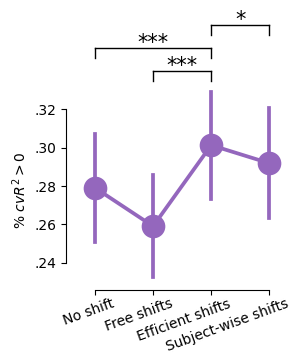

In [44]:
fig, ax = plt.subplots(figsize=(3, 3.6))
modelz = dict( [(0, 'No shift'), (3, 'Free shifts'), (4, 'Efficient shifts'), (5, 'Subject-wise shifts')] )
these_rez = rez_est.loc[:,list(modelz.keys())].rename(columns=modelz)
these_rez
#sns.stripplot(these_rez, color=FOURTH_COLOR) 
sns.pointplot(these_rez, errorbar='se', color=FOURTH_COLOR, markersize=15, ax=ax)
ax.set_xlabel(None)
#### x ticks labels positions
plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor")
# Create offset transform
dx = 12/72.; dy = 2/72. 
offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
ax.set_xlim(-.5,3.5)
#### y 
ax.set_yticks([.24, .26, .28, .3, .32])
ax.set_yticklabels(['.24', '.26', '.28', '.30', '.32'])
ax.set_ylabel('% $cvR^2 > 0$', y=.5, ha='right')
#ax.set_ylim(.23, .33)
ax.spines.left.set_bounds((.24, .32))
ax.spines.bottom.set_bounds((0, 3))
sns.despine(fig)
# (0,4), (3,4), (5,4) 
vll = 0.005
star_size = 15
star_offset = -.0025
star_line(ax, 0, 2, .352, compare_res_est.loc[(0,4)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
star_line(ax, 1, 2, .340, compare_res_est.loc[(3,4)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
star_line(ax, 3, 2, .364, compare_res_est.loc[(4,5)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)

In [45]:
these_rez

model_label,No shift,Free shifts,Efficient shifts,Subject-wise shifts
subject,,,,
1,0.151751,0.103761,0.136187,0.112840
2,0.116279,0.140698,0.186047,0.182558
3,0.085434,0.049020,0.121849,0.106443
4,0.219355,0.214194,0.252903,0.240000
5,0.168390,0.088626,0.158050,0.116691
6,0.180124,0.142857,0.176398,0.165217
7,0.426009,0.378924,0.412556,0.414798
8,0.342767,0.305031,0.424528,0.413522
9,0.483516,0.430141,0.492936,0.488226


In [46]:
df33 = index_filter(pars, type='estimates', smoothed=True, model_label=33, ) 
df33.amplitude.wide / df33.amplitude.narrow

subject     
1        0      0.930341
         1      0.930341
         2      0.930341
         3      0.930341
         4      0.930341
                  ...   
41       689    1.115719
         690    1.115719
         691    1.115719
         692    1.115719
         693    1.115719
Length: 30533, dtype: float64

(array([ 1.,  0.,  0.,  0.,  0.,  6., 15., 12.,  4.,  1.]),
 array([0.66450057, 0.70962245, 0.75474432, 0.7998662 , 0.84498807, 0.89010994, 0.93523182, 0.98035369, 1.02547557, 1.07059744, 1.11571931]),
 <BarContainer object of 10 artists>)

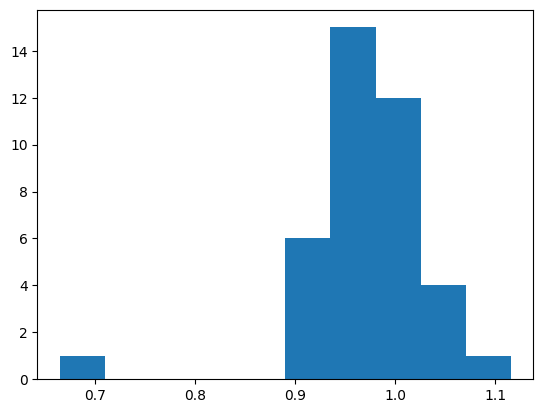

In [47]:
amp_ratios = df33.groupby('subject').first().amplitude.wide / df33.groupby('subject').first().amplitude.narrow
plt.hist(amp_ratios, bins=10)

In [48]:
amp_ratios.describe()

count    39.000000
mean      0.972722
std       0.067116
min       0.664501
25%       0.950117
50%       0.975984
75%       1.003974
max       1.115719
dtype: float64

In [49]:
pg.ttest(amp_ratios, 1)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-2.538209,38,two-sided,0.015362,"[0.95, 0.99]",0.406439,2.858,0.696266


## Median cvR2

In [107]:
model_list = [0,1,2,3,4,5,14,15,18,31,32,33,34,35] #### Only keeping these models
print(len(model_list))
cvr2s = index_filter(pars, model_label=model_list).cvr2
print( cvr2s.index.get_level_values('smoothed').unique() )
cvr2s.index = cvr2s.index.droplevel('smoothed')
cvr2s = cvr2s.squeeze("columns")
cvr2s

Index([True], dtype='bool', name='smoothed')


range                                        nan
type         subject model_label voxel          
ground_truth 1       0           0     -0.018960
                                 1     -0.019339
                                 2     -0.026036
                                 3     -0.021961
                                 4     -0.015200
...                                          ...
estimates    41      33          689    0.011950
                                 690   -0.015981
                                 691    0.002292
                                 692   -0.008607
                                 693   -0.006012

[1160254 rows x 1 columns]

In [108]:
sv = cvr2s.index.droplevel(["type", "model_label"])           # index aligned to rows, but only (subject, voxel)
mask = keep_sv.reindex(sv).to_numpy()
cvr2s_filtered = cvr2s.loc[mask]
cvr2s_filtered

In [ ]:
cvr2s[good_voxels]

In [ ]:
cvr2s_filtered.groupby(level=["subject", "voxel"]).count()

In [109]:
good_voxels

range            nan
subject voxel       
1       0       True
        1       True
        2       True
        3       True
        4       True
...              ...
41      689     True
        690     True
        691     True
        692    False
        693     True

[30533 rows x 1 columns]

In [112]:
# filter cvr2s to only keep good voxels
cvr2s_good = cvr2s[good_voxels]
cvr2s_good

ValueError: Cannot mask with non-boolean array containing NA / NaN values

In [ ]:
ytype = 'ground_truth'
da = index_filter(cvr2s_filtered, type=ytype)
rez_median = da.groupby(['subject', 'model_label']).median()
rez_median = rez_median.unstack()
rez_median

model_label,0,1,2,3,4,5,12,14,15,18,25,26,27,28,29,30,31,32,33
subject,,,,,,,,,,,,,,,,,,,
1,0.118029,0.128405,0.102464,0.093385,0.140078,0.110246,0.133593,0.116732,0.118029,0.103761,0.160830,0.114137,0.146563,0.125811,0.141375,0.111543,0.155642,0.143969,0.143969
2,0.127907,0.124419,0.090698,0.106977,0.125581,0.108140,0.086047,0.086047,0.118605,0.094186,0.105814,0.109302,0.102326,0.117442,0.096512,0.117442,0.115116,0.105814,0.117442
3,0.070028,0.061625,0.040616,0.040616,0.065826,0.043417,0.054622,0.032213,0.040616,0.047619,0.042017,0.046218,0.039216,0.040616,0.030812,0.032213,0.047619,0.026611,0.040616
4,0.298065,0.305806,0.245161,0.209032,0.308387,0.280000,0.249032,0.243871,0.282581,0.274839,0.313548,0.272258,0.291613,0.278710,0.294194,0.243871,0.312258,0.291613,0.304516
5,0.165436,0.168390,0.078287,0.094535,0.175775,0.051699,0.135894,0.124077,0.181684,0.118168,0.177253,0.158050,0.152142,0.131462,0.152142,0.132939,0.192024,0.172821,0.172821
6,0.196273,0.240994,0.188820,0.191304,0.257143,0.214907,0.285714,0.318012,0.350311,0.277019,0.346584,0.180124,0.259627,0.218634,0.257143,0.217391,0.334161,0.311801,0.320497
7,0.445067,0.434978,0.467489,0.419283,0.449552,0.447309,0.452915,0.426009,0.477578,0.461883,0.471973,0.437220,0.440583,0.437220,0.437220,0.410314,0.465247,0.450673,0.469731
8,0.366352,0.331761,0.347484,0.279874,0.360063,0.345912,0.336478,0.319182,0.369497,0.372642,0.397799,0.316038,0.339623,0.320755,0.333333,0.290881,0.393082,0.360063,0.391509
9,0.442700,0.452119,0.445840,0.365777,0.458399,0.419152,0.463108,0.412873,0.463108,0.447410,0.466248,0.431711,0.428571,0.427002,0.431711,0.390895,0.470958,0.427002,0.463108


In [ ]:
rez_median.columns

Index([0, 1, 2, 3, 4, 5, 12, 14, 15, 18, 25, 26, 27, 28, 29, 30, 31, 32, 33], dtype='int64', name='model_label')

In [ ]:
da = index_filter(pars, smoothed=True, type='estimates')
da['cvr2_pos'] = da.cvr2 > 0
rez_est = da.groupby(['subject', 'model_label']).cvr2_pos.mean()
rez_est = rez_est.unstack()
#rez_est

# Model 3 - Free mus

In [50]:
df3 = index_filter(pars, type='estimates', smoothed=True, model_label=3, ) 
df3 = df3[ df3[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
df3.index.rename(['subject', 'voxel'], inplace=True)
df3[('mu', 'delta_wn')] = df3[('mu', 'wide')] - df3[('mu', 'narrow')]

In [ ]:
df3_gt = index_filter(pars, type='ground_truth', smoothed=True, model_label=3, ) 
df3_gt = df3_gt[ df3_gt[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
df3_gt.index.rename(['subject', 'voxel'], inplace=True)
df3_gt[('mu', 'delta_wn')] = df3_gt[('mu', 'wide')] - df3_gt[('mu', 'narrow')]

In [51]:
df3

parameter             mu                   sd           delta_wide           amplitude            baseline                  r2      cvr2        mu
range             narrow       wide    narrow      wide     narrow      wide    narrow      wide    narrow      wide       nan       nan  delta_wn
subject voxel                                                                                                                                     
1       10     11.682623  16.416372  0.620960  0.620960   3.335587  3.335587  0.894001  0.894001 -1.021131 -1.021131  0.022224  0.002166  4.733749
        19     11.699798  12.155348  0.298874  0.298874   0.432271  0.432271  0.366680  0.366680 -0.324603 -0.324603  0.027029  0.000930  0.455550
        20     12.507381  13.631636  0.314411  0.314411  -0.807929 -0.807929  0.500685  0.500685 -0.589729 -0.589729  0.029938  0.007833  1.124256
        21     11.741282  12.658101  0.323126  0.323126  -0.100547 -0.100547  0.339480  0.339480 -0.182902 -0.182902  0.034864  0.015999  0.916819
        22     12.506862  13.648597  0.303899  0.303899  -1.235623 -1.235623  0.433540  0.433540 -0.416746 -0.416746  0.041086  0.028506  1.141735
...                  ...        ...       ...       ...        ...       ...       ...       ...       ...       ...       ...       ...       ...
41      683    12.316301  17.959295  0.596014  0.596014   3.070401  3.070401  0.324755  0.324755 -0.010704 -0.010704  0.036365  0.006856  5.642994
        684    15.974920  20.638970  0.141011  0.141011   1.843548  1.843548  0.254338  0.254338  0.155235  0.155235  0.041298  0.017604  4.664050
        686    11.896716  11.782497  0.284142  0.284142   0.858693  0.858693  0.308839  0.308839 -0.231846 -0.231846  0.027281  0.003801 -0.114219
        687    12.096848  11.868406  0.275633  0.275633   0.705122  0.705122  0.322327  0.322327 -0.062738 -0.062738  0.031246  0.007987 -0.228442
        689    10.982932  16.882748  1.201802  1.201802   3.649241  3.649241  1.045254  1.045254 -0.603918 -0.603918  0.027689  0.003679  5.899816

[8008 rows x 13 columns]

In [60]:
for meth in ['pearson', 'spearman', ]:
    print(pg.corr( df3.mu.narrow, df3.mu.wide, method=meth))
#
for meth in ['pearson', 'spearman', ]:
    print(pg.corr( df3_gt.mu.narrow, df3_gt.mu.wide, method=meth))

            n         r         CI95%  p-val BF10  power
pearson  8008  0.668998  [0.66, 0.68]    0.0  inf    1.0
             n         r         CI95%  p-val  power
spearman  8008  0.767203  [0.76, 0.78]    0.0    1.0


In [74]:
#meth = 'pearson'
meth = 'spearman'
print( pg.corr( df3.mu.narrow, df3.mu.wide, method=meth ) )
subject_corrs = df3.groupby(level='subject').apply(lambda g: pg.corr(g.mu.narrow, g.mu.wide, method=meth))
subject_corrs.describe()

             n         r         CI95%  p-val  power
spearman  8008  0.767203  [0.76, 0.78]    0.0    1.0


,n,r,p-val,power
count,39.000000,39.000000,3.900000e+01,39.000000
mean,205.333333,0.662091,6.327816e-06,0.998293
std,141.325554,0.160461,2.555604e-05,0.005807
min,35.000000,0.308809,2.596332e-117,0.971031
25%,86.500000,0.564486,5.737385e-40,0.999948
50%,157.000000,0.682035,2.306593e-20,1.000000
75%,294.500000,0.787672,2.850265e-08,1.000000
max,517.000000,0.958475,1.387730e-04,1.000000


In [75]:
print( subject_corrs['r'].min() )
subject_corrs['r'].describe(percentiles=[.25,.75])

0.3088086629165401


count    39.000000
mean      0.662091
std       0.160461
min       0.308809
25%       0.564486
50%       0.682035
75%       0.787672
max       0.958475
Name: r, dtype: float64

In [63]:
( subject_corrs['p-val'] < 0.001 ).mean()

1.0

In [64]:
pg.multicomp(subject_corrs['p-val'])[1].max()

0.00016635257941768178

In [65]:
df3.mu

range             narrow       wide  delta_wn
subject voxel                                
1       10     11.682623  16.416372  4.733749
        19     11.699798  12.155348  0.455550
        20     12.507381  13.631636  1.124256
        21     11.741282  12.658101  0.916819
        22     12.506862  13.648597  1.141735
...                  ...        ...       ...
41      683    12.316301  17.959295  5.642994
        684    15.974920  20.638970  4.664050
        686    11.896716  11.782497 -0.114219
        687    12.096848  11.868406 -0.228442
        689    10.982932  16.882748  5.899816

[8008 rows x 3 columns]

In [123]:
this_df = df3.mu.reset_index()
#pg.rm_corr(data=this_df, x='narrow', y='wide', subject='subject')

In [124]:
df3[df3.mu.narrow>=10].mu.delta_wn.groupby('subject').mean().mean()

2.836465998815146

In [125]:
pg.ttest( df3[df3.mu.narrow>=10].mu.delta_wn.groupby('subject').mean(), y=0 )

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,4.728859,38,two-sided,0.000031,"[1.62, 4.05]",0.757224,716.27,0.995932


37 subjects have median $\mu$ in Wide condition larger than in Narrow condition
2 subjects have median $\mu$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -8.983, p = 6.16e-11, dof = 38


/var/folders/jq/_79_qpxx3vd0thkqqmw37l1c0000gn/T/ipykernel_5791/263453751.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Paired t-test: t = {paired_test['T'][0]:.3f}, p = {paired_test['p-val'][0]:.3g}, dof = {paired_test['dof'][0]}")


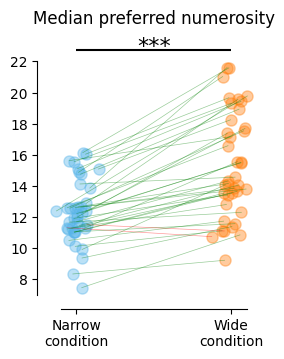

In [126]:
# Compute per-subject medians for 'mu' in 'wide' and 'narrow'
#ind = (df3.mu.narrow>=0) & (df3.mu.wide>=0) #& (df3.mu.narrow<=40) & (df3.mu.wide<=40)
mu_wide_medians = df3[('mu', 'wide')].groupby('subject').median()
mu_narrow_medians = df3[('mu', 'narrow')].groupby('subject').median()
print( (mu_wide_medians >= mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition larger than in Narrow condition' )
print( (mu_wide_medians <  mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition smaller than in Narrow condition' )

fig, ax = plt.subplots(figsize=(3, 3.6))
paired_strip_plot(ax, x1=1, x2=2, y1=mu_narrow_medians, y2=mu_wide_medians, 
                  col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='g', color_decr_line='r',)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_title("Median preferred numerosity")
ax.set_xlim(0.75, 2.25)
ax.set_ylim(6.1,23.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# paired test
paired_test = pg.ttest(mu_narrow_medians, mu_wide_medians, paired=True)
print(f"Paired t-test: t = {paired_test['T'][0]:.3f}, p = {paired_test['p-val'][0]:.3g}, dof = {paired_test['dof'][0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
ax.hlines(0.95*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
ax.text(1.5, 0.96*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')

ax.spines.left.set_bounds((7, 22))
ax.spines.bottom.set_bounds((.9, 2.1))

#fig.savefig('figures/delta_median_mu.pdf', bbox_inches='tight')

In [127]:
paired_test['p-val']

T-test    6.163888e-11
Name: p-val, dtype: float64

In [128]:
df3.index.get_level_values('subject').unique()

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41], dtype='int64', name='subject')

16.15884115884116 % of voxels have $\mu_{w} - \mu_{n} < 0$


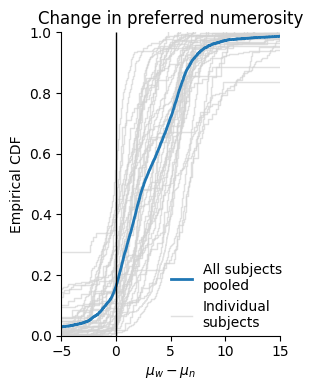

In [129]:
fig, ax = plt.subplots(figsize=(3, 4))
all_data = []
#ind = (df3.mu.narrow>=10) & (df3.mu.wide>=10) #& (df3.mu.narrow<=40) & (df3.mu.wide<=40)
subjects = df3.index.get_level_values('subject').unique()
for subject in subjects:
    data = df3.xs(subject, level='subject')[('mu', 'delta_wn')]
    all_data.append(pd.DataFrame({'mu_delta_wn': data.dropna(), 'subject': subject}))
all_data = pd.concat(all_data, ignore_index=True)
# Plot the CDFs for each subject in light grey (no hue, loop over subjects)
c_ind = 'lightgrey'
for subject in subjects:
    subj_data = all_data[all_data['subject'] == subject]
    sns.ecdfplot(data=subj_data, x='mu_delta_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False)

# Plot the pooled CDF (all subjects together) in a bold color
sns.ecdfplot(data=all_data, x='mu_delta_wn', color='C0', linewidth=2, label='All subjects pooled')
print( (all_data.mu_delta_wn<0).mean() * 100, '% of voxels have $\mu_{w} - \mu_{n} < 0$' )

#plt.title("Empirical CDF of $\mu_{w} - \mu_{n}$")
plt.gca().set_title("Change in preferred numerosity")
plt.xlabel('$\mu_{w} - \mu_{n}$')
plt.ylabel('Empirical CDF')
plt.legend(handles=[plt.Line2D([0], [0], color='C0', lw=2, label='All subjects\npooled'),
                    plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nsubjects')], loc=(.475,0), handlelength=1.5)
plt.tight_layout()
plt.xlim(-5, 15)
plt.vlines(0, 0, 1, color='black', linestyle='-', lw=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# fig.savefig('figures/cdf_delta_mu.pdf', bbox_inches='tight')

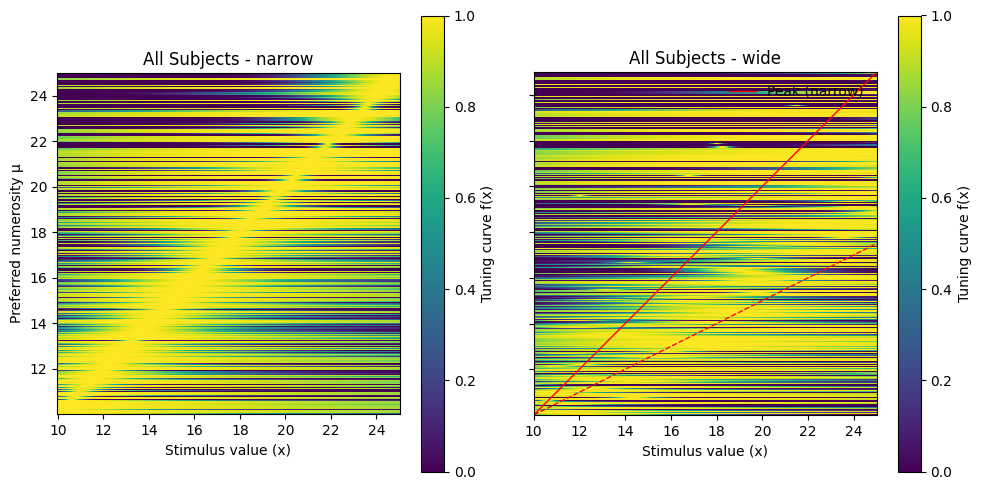

In [130]:
# Filter: only voxels with 10 <= mu (narrow) <= 25
mu_narrow_all = df3[('mu', 'narrow')]
mask = (mu_narrow_all >= 10) & (mu_narrow_all <= 25)
filtered_voxel_indices = mu_narrow_all[mask].sort_values().index          

x_vals   = np.linspace(10, 25, 200)
dx = x_vals[1] - x_vals[0]
x_edges  = np.linspace(x_vals[0]-dx/2, x_vals[-1]+dx/2, len(x_vals)+1)

# NEW  y-edges so vertical position depends only on μ, not voxel count
mu_sorted = df3.loc[filtered_voxel_indices][('mu', 'narrow')].values
y_edges   = np.concatenate(([mu_sorted[0] - (mu_sorted[1]-mu_sorted[0])/2],
                            (mu_sorted[:-1] + mu_sorted[1:]) / 2,
                            [mu_sorted[-1] + (mu_sorted[-1]-mu_sorted[-2])/2]))

conditions = ['narrow', 'wide']
fig, axes = plt.subplots(1, 2, figsize=(10, 5 ), sharey=True)

for ax in axes: 
    ax.set_aspect('equal', adjustable='box') 

peak_locs = []

for i, cond in enumerate(conditions):
    ax = axes[i]
    img = []
    for idx in filtered_voxel_indices:
        #baseline  = df3.loc[idx][('baseline',  cond)]
        #amplitude = df3.loc[idx][('amplitude', cond)]
        mu        = df3.loc[idx][('mu',       cond)]
        sd        = df3.loc[idx][('sd',       cond)]
        #fx = np.exp(-.5*((x_vals - mu) / sd) ** 2)
        fx = np.exp(-.5*((np.log(x_vals) - np.log(mu) ) / sd) ** 2)
        #fx = -.5*((np.log(x_vals) - np.log(mu) ) / sd) ** 2
        #fx = baseline + amplitude * np.exp(-.5*((np.log(x_vals) - np.log(mu) ) / sd) ** 2)
        img.append(fx)
        if i == 0:
            peak_locs.append(mu)
    img = np.array(img)

    # CHANGED ↓  imshow → pcolormesh with the pre-computed edges
    im = ax.pcolormesh(x_edges, y_edges, img, shading='auto', cmap='viridis')

    ax.set_title(f'All Subjects - {cond}')
    ax.set_xlabel('Stimulus value (x)')
    if i == 0:
        ax.set_ylabel('Preferred numerosity μ')
    fig.colorbar(im, ax=ax, label='Tuning curve f(x)')

    if i == 1:
        # CHANGED ↓  use μ values instead of row indices
        ax.plot(peak_locs, mu_sorted, 'r-',  linewidth=1, label='Peak (narrow)')
        ax.plot(10 + 2*(np.array(peak_locs) - 10), mu_sorted, 'r--', linewidth=1)
        ax.legend(loc='upper right')
        ax.set_xlim(x_vals[0], x_vals[-1])

    # # NEW  flip so small μ at top
    # ax.invert_yaxis()                                               

plt.tight_layout()
plt.show()


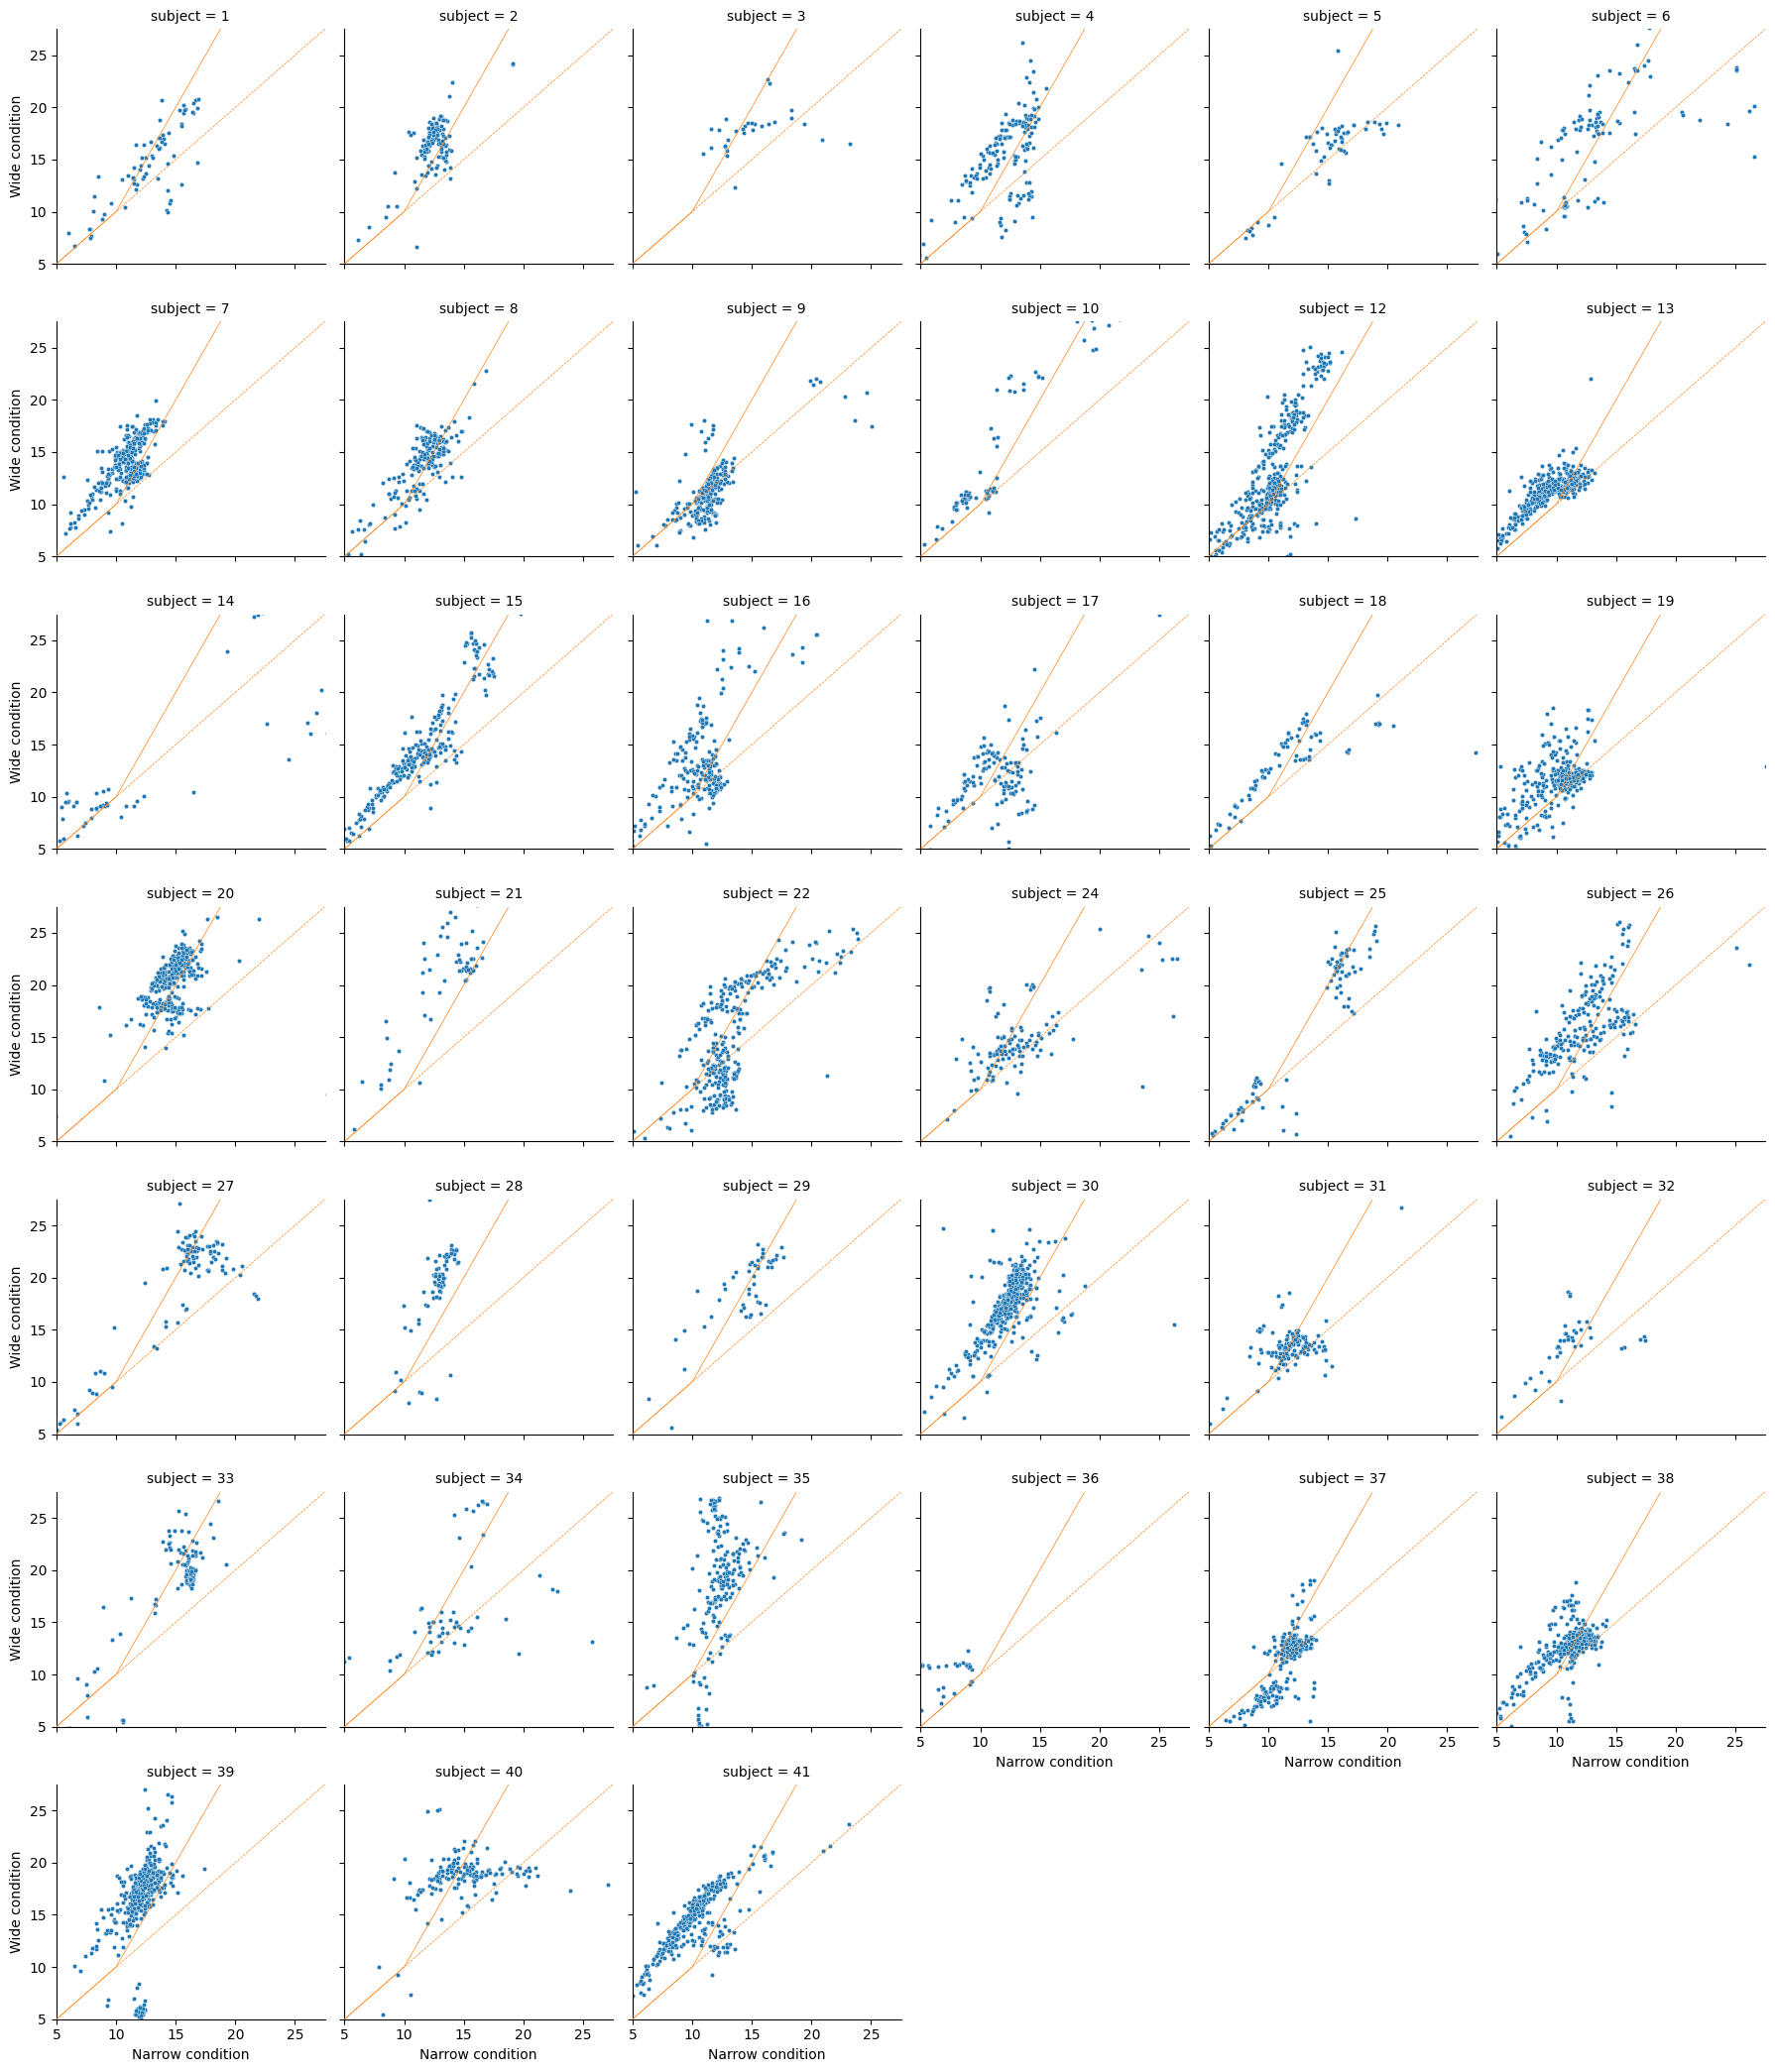

In [131]:
df_plt = df3.reset_index()
g = sns.FacetGrid(df_plt, col="subject", col_wrap=6, height=3, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x=('mu', 'narrow'), y=('mu', 'wide'),
                color='C0', s=10, alpha=1,) # edgecolor=None)
g.set_axis_labels("Narrow condition", "Wide condition")
g.set(xlim=(5,27.5), ylim=(5,27.5))
for ax in g.axes.flatten():
    ax.axline((0,0), slope=1, color='C1', ls='--', lw=.5, zorder=100)
    ax.plot([0, 10, 40], [0, 10, 70], c='C1', lw=.5, zorder=100)
plt.tight_layout()
plt.show()

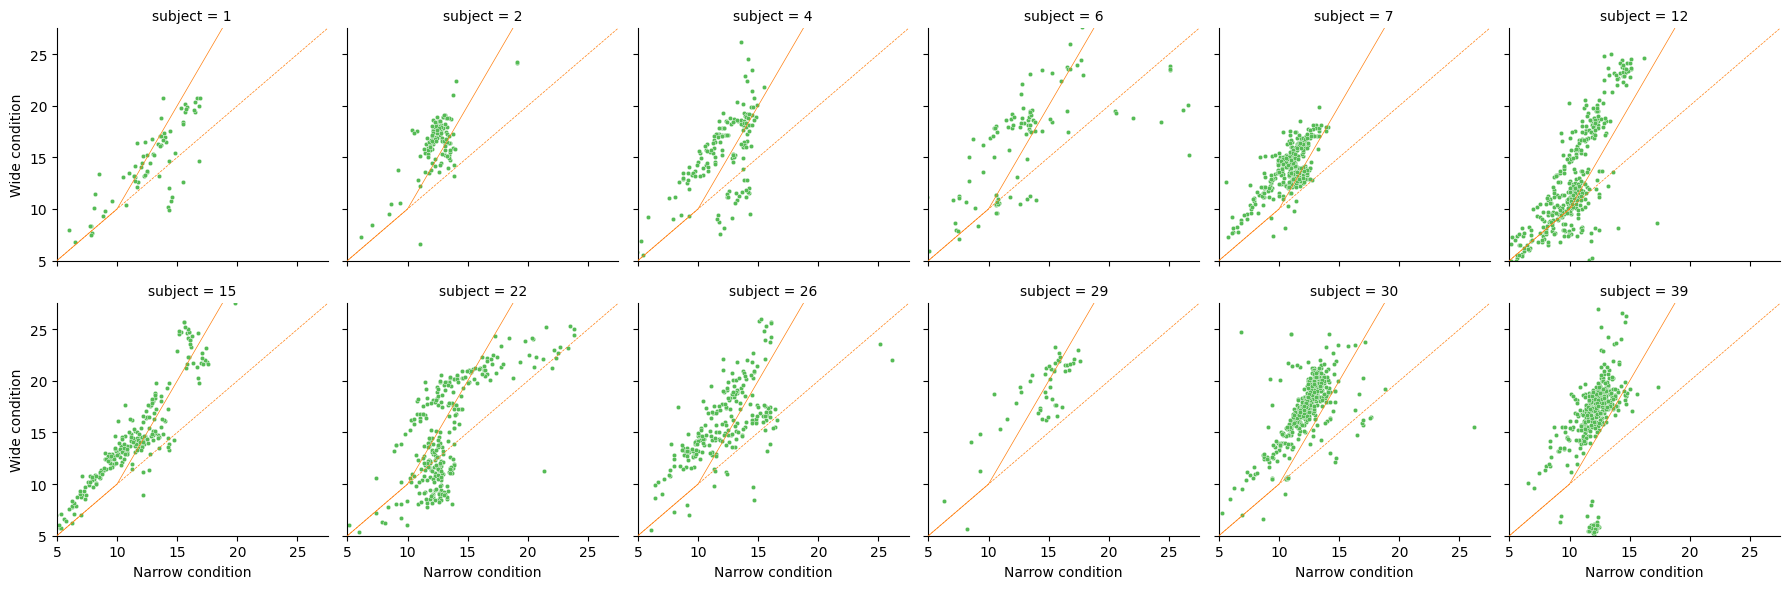

In [132]:
df_plt = index_filter(df3, subject=[1,2,4,6,7,12,15,22,26,29,30,39]).reset_index()
g = sns.FacetGrid(df_plt, col="subject", col_wrap=6, height=3, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x=('mu', 'narrow'), y=('mu', 'wide'),
                color=THIRD_COLOR, s=10, alpha=1,) # edgecolor=None)
g.set_axis_labels("Narrow condition", "Wide condition")
g.set(xlim=(5,27.5), ylim=(5,27.5))
for ax in g.axes.flatten():
    ax.axline((0,0), slope=1, color='C1', ls='--', lw=.5, zorder=100)
    ax.plot([0, 10, 40], [0, 10, 70], c='C1', lw=.5, zorder=100)
plt.tight_layout()
plt.show()

(0.0, 25.0)

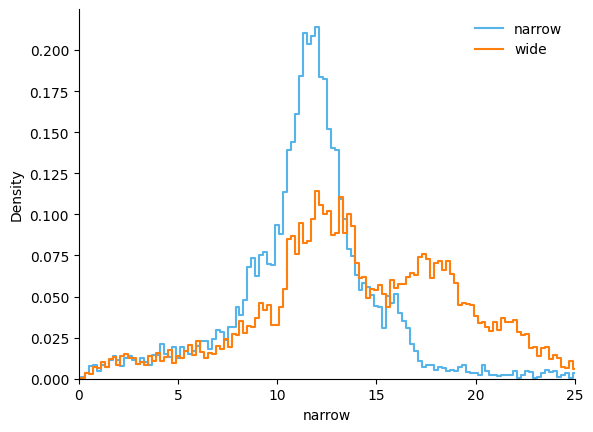

In [133]:
dx = 0.2
bins = np.arange(-dx/2, 25+dx/2+.000001, dx)
sns.histplot(df3.mu.narrow, element='step', fill=False, color=COLORS_COND[NARROW], stat='density', label=NARROW, binrange=(0, 25), bins=bins)
sns.histplot(df3.mu.wide  , element='step', fill=False, color=COLORS_COND[WIDE],   stat='density', label=WIDE,   binrange=(0, 25), bins=bins)
plt.legend()
sns.despine()
plt.xlim(0, 25)

(10.0, 25.0)

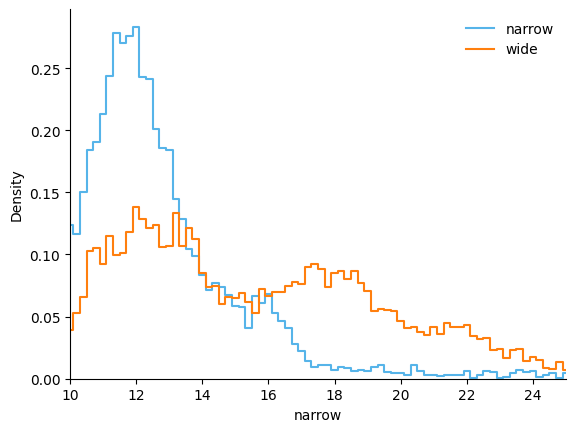

In [134]:
dx = 0.2
bins = np.arange(10-dx/2, 25+dx/2+.000001, dx)
sns.histplot(df3.mu.narrow, element='step', fill=False, color=COLORS_COND[NARROW], stat='density', label=NARROW, binrange=(10, 25), bins=bins)
sns.histplot(df3.mu.wide  , element='step', fill=False, color=COLORS_COND[WIDE],   stat='density', label=WIDE,   binrange=(10, 25), bins=bins)
plt.legend()
sns.despine()
plt.xlim(10, 25)

# Model 5 - subject-wise delta_wide

In [135]:
dfe5 = index_filter(pars, type='estimates', smoothed=True, model_label=5, ) 
dfgt5 = index_filter(pars, type='ground_truth', smoothed=True, model_label=5, ) 
dfe5  = dfe5[  dfe5[ ('cvr2', 'nan')] > 0] #.drop(columns='alpha')
dfgt5 = dfgt5[ dfgt5[('cvr2', 'nan')] > 0] #.drop(columns='alpha')

0.15619743 5.9677258 2.253248442820512 1.964078 0.18627692471764382
12
[0.         0.57142857 1.14285714 1.71428571 2.28571429 2.85714286 3.42857143 4.         4.57142857 5.14285714 5.71428571 6.28571429]
[0.28571429 0.85714286 1.42857143 2.         2.57142857 3.14285714 3.71428571 4.28571429 4.85714286 5.42857143 6.        ]


Text(1.914078, 2, 'median')

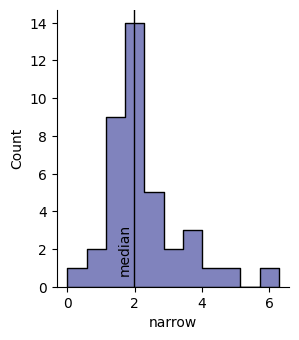

In [136]:
fig, ax = plt.subplots(figsize=(3, 3.6))
ratio_mu = dfe5.delta_wide.narrow.groupby('subject').first()
print(ratio_mu.min(), ratio_mu.max(), ratio_mu.mean(), ratio_mu.median(), ratio_mu.sem())
# nb_bins = 13
# dw = (ratio_mu.max() - ratio_mu.min()) / nb_bins
# bins = np.arange(2-dw/2-((2-ratio_mu.min()+.25)//dw)*dw, 6.+dw, dw)
#dw = .5
nb_bins_02 = 3
dw = 2 / (nb_bins_02 + 1/2)
#bins = np.arange(-dw/2, 7., dw)
bins = np.arange(0, ratio_mu.max()+dw, dw)
print(len(bins))
print(bins)
print( .5*(bins[:-1] + bins[1:]) )
sns.histplot(ratio_mu, bins=bins, ax=ax, color=plt.cm.Spectral_r(0.02), element='step', ec='k' ) # plt.cm.RdYlBu(0.4)
#sns.ecdfplot(ratio_mu, ax=ax, color='C0', linewidth=2, label='All subjects pooled')
sns.despine(fig)
#ax.axvline(2, color='k', linestyle='-', lw=1)
ax.axvline(ratio_mu.median(), color='k', linestyle='-', lw=1)
ax.text(ratio_mu.median()-.05, 2, 'median', rotation=90, va='center', ha='right')

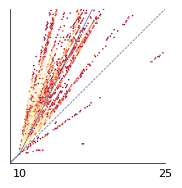

In [137]:
fig, ax = plt.subplots(figsize=(2,2))
this_df = dfe5
nmin_5, nmax_5 = 9, 25
ind = (dfe5.mu.narrow>=nmin_5) & (dfe5.mu.wide>=nmin_5) & (dfe5.mu.narrow<=nmax_5) & (dfe5.mu.wide<=nmax_5)
#sns.histplot(dfe5[ind].mu, x='narrow', y='wide', bins=161, ax=ax, pmax=1, alpha=1, color='grey')
cmap = plt.cm.RdYlBu #summer, YlOrRd_r , ---- 'RdYlBu', 'Spectral', 
ax.hexbin(dfe5[ind].mu.narrow, dfe5[ind].mu.wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=cmap, mincnt=1, edgecolors='none', bins='log')
ax.set_xlim(nmin_5,nmax_5); ax.set_ylim(nmin_5,nmax_5)
this_color = plt.cm.Spectral_r(0.02)
ax.axline((0,0), slope=1, color=this_color, ls='--', lw=.5, zorder=100)
ax.plot([0, 10, 40], [0, 10, 70], c=this_color, lw=.5, zorder=100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.set_xlabel(None); ax.set_ylabel(None)
#ax.set_title('Free-slope model', fontsize=8)
ax.set_xticks([10,25]); ax.set_yticks([10,25]); ax.set_yticklabels([None,None]);
ax.tick_params(axis='both', labelsize=8, length=0)

In [138]:
np.arange(2-((2-ratio_mu.min())//dw+.5)*dw, 6.+dw, dw)

array([0.        , 0.57142857, 1.14285714, 1.71428571, 2.28571429, 2.85714286, 3.42857143, 4.        , 4.57142857, 5.14285714, 5.71428571,
       6.28571429])

0.15619743 5.9677258 2.253248442820512 1.964078


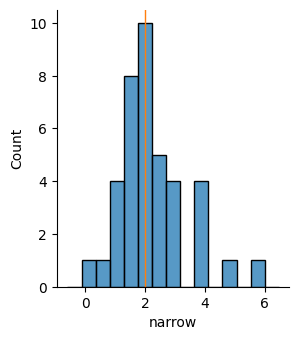

In [ ]:
fig, ax = plt.subplots(figsize=(3, 3.6))
ratio_mu = dfe5.delta_wide.narrow.groupby('subject').first()
print(ratio_mu.min(), ratio_mu.max(), ratio_mu.mean(), ratio_mu.median(), ratio_mu.sem() )
dw = .47
sns.histplot(ratio_mu, bins=np.arange(2-(2//dw+1.5)*dw, 6.+dw, dw), ax=ax,)
#sns.ecdfplot(ratio_mu, ax=ax, color='C0', linewidth=2, label='All subjects pooled')
sns.despine(fig)
ax.axvline(2, color='C1', linestyle='-', lw=1)

In [140]:
print(sorted(ratio_mu))

[0.15619743, 0.70350844, 0.8750543, 1.2300447, 1.2550579, 1.2772125, 1.3105263, 1.3152603, 1.4615268, 1.5304906, 1.5347533, 1.6909493, 1.7168945, 1.7318991, 1.7733885, 1.8004893, 1.8084729, 1.926806, 1.9592503, 1.964078, 1.9716936, 2.0470965, 2.1359594, 2.1499162, 2.2576168, 2.268883, 2.3688104, 2.4932153, 2.6186748, 2.7392347, 2.8316061, 3.161634, 3.1662412, 3.9158642, 3.9571798, 3.9969351, 4.1041055, 4.7024364, 5.9677258]


In [141]:
pg.ttest(ratio_mu, y=1)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,6.727878,38,two-sided,5.754501e-08,"[1.88, 2.63]",1.077323,2.475e+05,0.999998


In [142]:
pg.ttest(ratio_mu, y=2)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.359527,38,two-sided,0.181993,"[1.88, 2.63]",0.217698,0.404,0.263326


# Figure - preferred numerosities

In [143]:
from matplotlib import rcParams

In [144]:
from matplotlib.patches import FancyBboxPatch
import matplotlib.transforms as mtransforms

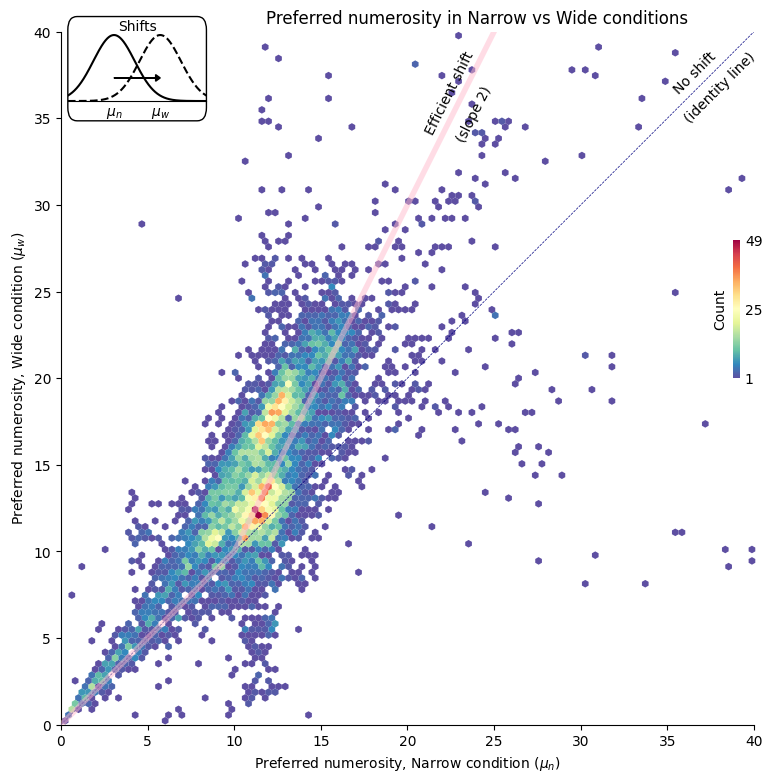

In [145]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.set_aspect('equal') #, adjustable='box')
nmax = 40
ind = (df3.mu.narrow>=0) & (df3.mu.wide>=0) & (df3.mu.narrow<=nmax) & (df3.mu.wide<=nmax)
#sns.histplot(df3[ind].mu, x='narrow', y='wide', bins=161, ax=ax, pmax=.8, alpha=1, cmap='YlGnBu_r', thresh=0) # cmap='YlGnBu_r', 'plasma
#sns.kdeplot(df3[ind].mu, x='narrow', y='wide', ax=ax, levels=6, thresh=.5, fill=True, cmap='YlGnBu')
#ax.hexbin(df3[ind].mu.narrow, df3[ind].mu.wide, gridsize=(50*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap='YlGnBu_r', mincnt=1, edgecolors='none')
cmap = plt.cm.Spectral_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', 
hb = ax.hexbin(df3[ind].mu.narrow, df3[ind].mu.wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=cmap, mincnt=1,
          edgecolors='none', clip_on=False)
#sns.regplot(df3[ind].mu, x='narrow', y='wide', ax=ax, scatter=False, lowess=True, color='#FF0000') # ci=None,
cbar_ax = ax.inset_axes([0.97, 0.5, .01, .2])
cb = fig.colorbar(hb, cax=cbar_ax, label='Count', ticks=[1,25,49], drawedges=False)
cb.ax.yaxis.set_label_position('left')
#cb.ax.yaxis.tick_left()
cbar_ax.tick_params(axis='both', length=0)
cb.outline.set_visible(False)

ax.set_xlim(0,nmax); ax.set_ylim(0,nmax)
ax.axline((0,0), slope=1, color='navy', ls='--', lw=.5, zorder=100)
ax.plot([0, 10, 40], [0, 10, 70], c="xkcd:pastel pink", alpha=.5, lw=4, zorder=100)
ax.set_xlabel('Preferred numerosity, Narrow condition ($\mu_n$)')
ax.set_ylabel('Preferred numerosity, Wide condition ($\mu_w$)')
ax.set_title('Preferred numerosity in Narrow vs Wide conditions', x=.6)
ax.text(38, 38+1, 'No shift', fontsize=10, ha='right', va='top', rotation=45)
ax.text(40.25, 38+1, '(identity line)', fontsize=10, ha='right', va='top', rotation=45)
ax.text(24, 38+1, 'Efficient shift', fontsize=10, ha='right', va='top', rotation=63.43)
ax.text(25, 36+1, '(slope 2)', fontsize=10, ha='right', va='top', rotation=63.43)

inset_width = 0.2; inset_height = .1
inset_ax = ax.inset_axes([0.01, 0.9, inset_width, inset_height], ) 
#inset_ax = fig.add_axes([inset_width/2, 0.8, inset_width, inset_width], )
xxs = np.linspace(0, 3, 1000)
inset_ax.plot(xxs, np.exp(-(xxs-1)**2/.4), color='k') 
inset_ax.plot(xxs, np.exp(-(xxs-2)**2/.4), color='k', linestyle='--')
inset_ax.arrow(x=1, y=0.35, dx=1, dy=0, color='k', lw=1, head_width=0.1, head_length=0.1, length_includes_head=True, zorder=100)
inset_ax.set_ylim(0, None)
inset_ax.set_xlim(0, 3)
inset_ax.set_yticks([])
inset_ax.set_xticks([1,2])
inset_ax.set_xticklabels(['$\mu_n$', '$\mu_w$'])
inset_ax.tick_params(axis='x', length=0)
bb = mtransforms.Bbox([[0., -.3], [3, 1.28]])
fancy = FancyBboxPatch(bb.p0, bb.width, bb.height, clip_on=False, facecolor="w", boxstyle="round,pad=0,rounding_size=0.2") # zorder=1000000)
inset_ax.add_patch(fancy)
inset_ax.set_title('Shifts', fontsize=10, y=.9, ha='center')

sns.despine(fig)
sns.despine(ax=inset_ax, left=True)
#ax.grid()
fig.savefig('figures/mu_wide_vs_narrow_test2.pdf', bbox_inches='tight')

In [146]:
from matplotlib.patches import ConnectionPatch

In [147]:
#THIRD_COLOR = '#EEFFEE'
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10

97.78% of voxels have 0 <= mu (narrow) <= 40 and 0 <= mu (wide) <= 40
2.22% of voxels have mu (narrow) or mu (wide) outside [0, 40]
32 subjects have median $\mu$ in Wide condition larger than in Narrow condition
7 subjects have median $\mu$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -4.308, p = 0.000112, dof = 38
21.654735682819386 % of voxels have $\mu_{w} - \mu_{n} < 0$
               T  dof alternative     p-val        CI95%   cohen-d   BF10     power
T-test  2.592253   38   two-sided  0.013459  [0.0, 0.02]  0.053155  3.196  0.062084


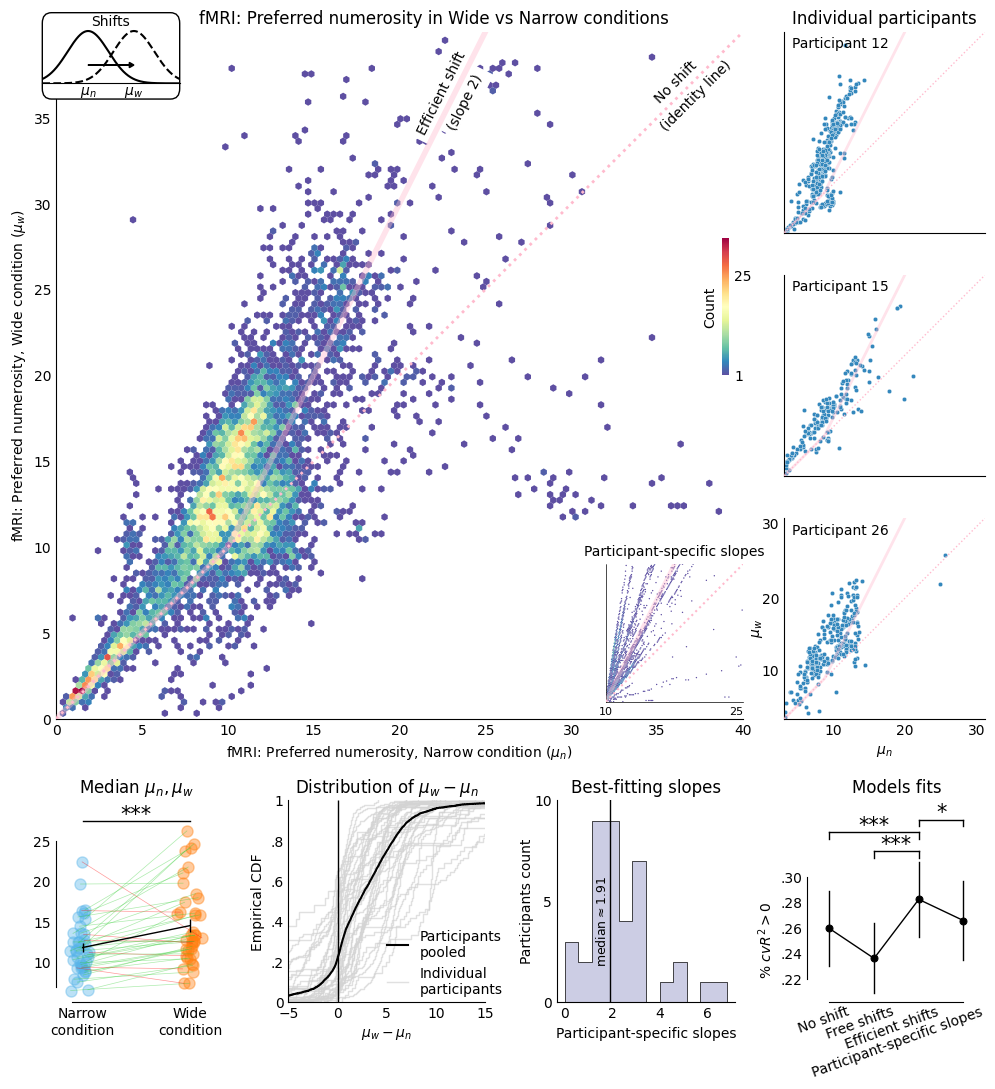

In [331]:
nrows = 4
WITH_GROUND_TRUTH = True
this_df3 = df3_gt if WITH_GROUND_TRUTH else df3
#fig = plt.figure(figsize=(12, nrows*3))
gs = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2))
#fig, axs = plt.subplots(nrows=nrows, ncols=4, figsize=(12, nrows*3), height_ratios=(1,1,1,1.2))
fig = plt.figure(figsize=(12, (nrows+.2)*3))
#ax = fig.add_subplot(nrows,4,(1,11))
ax = fig.add_subplot(gs[:3, :3])
ax.set_aspect('equal') #, adjustable='box')

cmap = plt.cm.Spectral_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', 
MUMU_COLOR = cmap(.1) # THIRD_COLOR
LINE_COLOR = 'xkcd:pastel pink' #'C1'

nmax = 40
ind = (this_df3.mu.narrow>=0) & (this_df3.mu.wide>=0) & (this_df3.mu.narrow<=nmax) & (this_df3.mu.wide<=nmax)
print(f'{ind.mean()*100:.2f}% of voxels have 0 <= mu (narrow) <= {nmax} and 0 <= mu (wide) <= {nmax}')
print(f'{(~ind).mean()*100:.2f}% of voxels have mu (narrow) or mu (wide) outside [{0}, {nmax}]')
#sns.histplot(this_df3[ind].mu, x='narrow', y='wide', bins=161, ax=ax, pmax=1, alpha=1, color=MUMU_COLOR, kde=True)
#sns.kdeplot(this_df3[ind].mu, x='narrow', y='wide', ax=ax, levels=6, thresh=.5, fill=True, cmap='YlGnBu')
hb = ax.hexbin(this_df3[ind].mu.narrow, this_df3[ind].mu.wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0.,
          cmap=cmap, mincnt=1, edgecolors='none', clip_on=False)
#sns.scatterplot(this_df3[ind].mu, x='narrow', y='wide', ax=ax, color=MUMU_COLOR, s=1)
#sns.kdeplot(this_df3[ind].mu, x='narrow', y='wide', ax=ax, levels=8, thresh=.1, fill=False, cmap='YlGnBu_r')
#sns.regplot(this_df3[ind].mu, x='narrow', y='wide', ax=ax, scatter=False, line_kws={'color': LINE_COLOR, 'lw': .5}, lowess=True) # ci=None, 
# ns = np.arange(0, 26, 1)
# ys = [ this_df3[(this_df3.mu.narrow>=n-.5) & (this_df3.mu.narrow<=n+.5)].mu.wide.mean() for n in ns]
# ysems = [ this_df3[(this_df3.mu.narrow>=n-.5) & (this_df3.mu.narrow<=n+.5)].mu.wide.sem() for n in ns]
# ax.errorbar(ns, ys, yerr=ysems, color='#FF0000', lw=2, zorder=100)

# Colorbar
cbar_ax = ax.inset_axes([0.97, 0.5, .01, .2])
cb = fig.colorbar(hb, cax=cbar_ax, label='Count', ticks=[1,25,49], drawedges=False)
cb.ax.yaxis.set_label_position('left')
#cb.ax.yaxis.tick_left()
cbar_ax.tick_params(axis='both', length=0)
cb.outline.set_visible(False)

ax.set_xlim(0,nmax); ax.set_ylim(0,nmax)
ax.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=2, zorder=100)
ax.plot([0, 10, 40], [0, 10, 70], c=LINE_COLOR, lw=4, alpha=.4, zorder=100)
ax.set_xlabel('fMRI: Preferred numerosity, Narrow condition ($\mu_n$)')
ax.set_ylabel('fMRI: Preferred numerosity, Wide condition ($\mu_w$)')
ax.set_title('fMRI: Preferred numerosity in Wide vs Narrow conditions', x=.55, y=1.)
ax.text(37.5, 37.5+1, 'No shift', fontsize=10, ha='right', va='top', rotation=45)
ax.text(39.5, 37.5+1, '(identity line)', fontsize=10, ha='right', va='top', rotation=45)
ax.text(24, 38+1,   'Efficient shift', fontsize=10, ha='right', va='top', rotation=63.43, backgroundcolor='w')
ax.text(25, 36.7+1, '(slope 2)', fontsize=10, ha='right', va='top', rotation=63.43, backgroundcolor='w')
#ax.text(22.5, 35+1,   'Efficient shift', fontsize=10, ha='right', va='top', rotation=63.43, backgroundcolor='w')
#ax.text(23.5, 33.7+1, '(slope 2)', fontsize=10, ha='right', va='top', rotation=63.43)
#ax.grid()
ax.set_yticks([0,5,10,15,20,25,30,35])

ax.tick_params(axis='both', length=0)

sns.despine(fig)

##### Icon
icon_width = 0.2; icon_height = .08
icon_ax = ax.inset_axes([-.02, 0.925, icon_width, icon_height], ) 
#inset_ax = fig.add_axes([inset_width/2, 0.8, inset_width, inset_width], )
xxs = np.linspace(0, 3, 1000)
icon_ax.plot(xxs, np.exp(-(xxs-1)**2/.4), color='k') 
icon_ax.plot(xxs, np.exp(-(xxs-2)**2/.4), color='k', linestyle='--')
icon_ax.arrow(x=1, y=0.35, dx=1, dy=0, color='k', lw=1, head_width=0.1, head_length=0.1, length_includes_head=True, zorder=100)
icon_ax.set_ylim(0, None)
icon_ax.set_xlim(0, 3)
icon_ax.set_yticks([])
icon_ax.set_xticks([1,2])
icon_ax.set_xticklabels(['$\mu_n$', '$\mu_w$'])
icon_ax.tick_params(axis='x', length=0, pad=0.5, labelsize=10)
bb = mtransforms.Bbox([[0., -.3], [3, 1.35]])
fancy = FancyBboxPatch(bb.p0, bb.width, bb.height, clip_on=False, facecolor="w", boxstyle="round,pad=0,rounding_size=0.2") # zorder=1000000)
icon_ax.add_patch(fancy)
icon_ax.set_title('Shifts', fontsize=10, y=.9, ha='center')


this_df5 = dfgt5 if WITH_GROUND_TRUTH else dfe5
if True:
    inset_width = 0.2
    #### Inset KDE
    # inset_ax = ax.inset_axes([0.575, 0.025, inset_width, inset_width], aspect='equal') 
    # sns.kdeplot(this_df3[ind].mu, x='narrow', y='wide', ax=inset_ax, levels=6, cmap=cmap, thresh=.15, linewidths=.8)
    # inset_ax.set_xlim(9,25); inset_ax.set_ylim(9,25)
    # inset_ax.axline((0,0), slope=1, color=LINE_COLOR, ls='--', lw=.5, zorder=100)
    # inset_ax.plot([0, 10, 40], [0, 10, 70], c=LINE_COLOR, lw=.5, zorder=100)
    # inset_ax.spines['top'].set_visible(False); inset_ax.spines['right'].set_visible(False)
    # inset_ax.spines['left'].set_linewidth(0.5); inset_ax.spines['bottom'].set_linewidth(0.5)
    # inset_ax.set_xlabel(None); inset_ax.set_ylabel(None)
    # inset_ax.set_xticks([10,25]); inset_ax.set_yticks([10, 25]); inset_ax.set_yticklabels([None,None]); #inset_ax.set_xticklabels([None,None]); 
    # inset_ax.tick_params(axis='both', labelsize=8, length=0)
    # inset_ax.get_xticklabels()[-1].set_ha('right')

    ### Inset Model 5
    inset_ax2 = ax.inset_axes([0.8, 0.025, inset_width, inset_width], aspect='equal')
    nmin_5, nmax_5 = 10, 25
    ind = (this_df5.mu.narrow>=nmin_5) & (this_df5.mu.wide>=nmin_5) & (this_df5.mu.narrow<=nmax_5) & (this_df5.mu.wide<=nmax_5)
    #sns.histplot(this_df[ind].mu, x='narrow', y='wide', bins=161, ax=inset_ax2, pmax=.8, cmap=plt.cm.Spectral_r ) #alpha=.4, color=THIRD_COLOR)
    this_cmap = plt.cm.Spectral_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', # plt.cm.RdYlBu #
    inset_ax2.hexbin(this_df5[ind].mu.narrow, this_df5[ind].mu.wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=this_cmap, mincnt=1, edgecolors='none', ) #bins='log')
    inset_ax2.set_xlim(nmin_5,nmax_5); inset_ax2.set_ylim(nmin_5,nmax_5)
    inset_ax2.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=1.5, zorder=100)
    inset_ax2.plot([0, 10, 40], [0, 10, 70], c=LINE_COLOR, lw=3, alpha=.4, zorder=100)
    inset_ax2.spines['top'].set_visible(False)
    inset_ax2.spines['right'].set_visible(False)
    inset_ax2.spines['left'].set_linewidth(0.5)
    inset_ax2.spines['bottom'].set_linewidth(0.5)
    inset_ax2.set_xlabel(None); inset_ax2.set_ylabel(None)
    #inset_ax2.set_title('Free-slope model', fontsize=8)
    inset_ax2.set_xticks([10,25]); inset_ax2.set_yticks([10,25]); inset_ax2.set_yticklabels([None,None]);
    inset_ax2.tick_params(axis='both', labelsize=8, length=0)
    inset_ax2.get_xticklabels()[-1].set_ha('right')
    inset_ax2.set_title('Participant-specific slopes', backgroundcolor='w', fontsize=10)



###### Individual subjects
select_subjs = [12,15,26]
axS1 = fig.add_subplot(gs[0, 3]) # fig.add_subplot(nrows,4,4)
sns.scatterplot(data=index_filter(this_df3, subject=12).mu, x='narrow', y='wide', color=MUMU_COLOR, s=10, alpha=1, ax=axS1)
axS2 = fig.add_subplot(gs[1, 3]) # fig.add_subplot(nrows,4,8)
sns.scatterplot(data=index_filter(this_df3, subject=15).mu, x='narrow', y='wide', color=MUMU_COLOR, s=10, alpha=1, ax=axS2)
axS3 = fig.add_subplot(gs[2, 3]) # fig.add_subplot(nrows,4,12)
sns.scatterplot(data=index_filter(this_df3, subject=26).mu, x='narrow', y='wide', color=MUMU_COLOR, s=10, alpha=1, ax=axS3)
for ii,ax in enumerate([axS1, axS2, axS3]):
    ax.set_aspect('equal')
    ax.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=1, zorder=100)
    ax.plot([0, 10, 40], [0, 10, 70], c=LINE_COLOR, lw=2, alpha=.4, zorder=100)
    ax.set_xlim(5, 30); ax.set_ylim(5, 30)
    ax.set_xlabel(None); ax.set_ylabel(None)
    ax.set_xticks([]); ax.set_yticks([])
    #ax.text(20, 10, f'Subject {select_subjs[ii]}', fontsize=10)
    ax.text(6, 28, f'Participant {select_subjs[ii]}', fontsize=10, ha='left')
axS1.set_title('Individual participants')
#axS3.set_xticks([5, 10, 15, 20, 25, 30]); axS3.set_yticks([5, 10, 15, 20, 25, 30]);
axS3.set_xticks([10,20,30]); axS3.set_yticks([10,20,30]);
#ax.set_xticklabels([]); ax.set_yticklabels([]);
axS3.tick_params(axis='both', length=0) # labelsize=8, 
axS3.get_xticklabels()[0].set_ha('left'); axS3.get_xticklabels()[-1].set_ha('right')
axS3.get_yticklabels()[-1].set_va('top'); axS3.get_yticklabels()[0].set_va('bottom')
axS3.set_xlabel('$\mu_n$')
axS3.set_ylabel('$\mu_w$', labelpad=-2, y=.45)

######## Bottom row
gs2 = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2), hspace=.5, width_ratios=(.9,1.1,1,1), wspace=.4)

######## Median preferred numerosities
ax = fig.add_subplot(gs2[3,0])

mu_wide_medians = this_df3[('mu', 'wide')].groupby('subject').median()
mu_narrow_medians = this_df3[('mu', 'narrow')].groupby('subject').median()
print( (mu_wide_medians >= mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition larger than in Narrow condition' )
print( (mu_wide_medians <  mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition smaller than in Narrow condition' )
paired_strip_plot(ax, x1=1, x2=2, y1=mu_narrow_medians, y2=mu_wide_medians, 
                  col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='limegreen', color_decr_line='r')
ax.errorbar([1, 2], [mu_narrow_medians.mean(), mu_wide_medians.mean()], yerr=[mu_narrow_medians.sem(), mu_wide_medians.sem()],
                color='k', lw=1, marker='none')
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
#ax.set_title("Median preferred num.")
ax.set_title("Median $\mu_n, \mu_w$")
ax.set_xlim(0.75, 2.25)
ax.set_ylim(5.1,29.999) if WITH_GROUND_TRUTH else ax.set_ylim(6.1,24.5) #23.9)
# paired test
paired_test = pg.ttest(mu_narrow_medians, mu_wide_medians, paired=True)
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
# ax.hlines(0.95*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
# ax.text(1.5, 0.96*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')
star_line(ax, 1, 2, 27.5 if WITH_GROUND_TRUTH else 22.5, paired_test['p-val'].iloc[0], star_size=15, star_offset=-.5)

ax.tick_params(axis='both', length=0)
ax.spines.left.set_bounds((7, 25 if WITH_GROUND_TRUTH else 22))
ax.spines.bottom.set_bounds((.9, 2.1))

######## CDF of change in preferred numerosity
ax = fig.add_subplot(gs2[3,1])
all_data = []
#ind = (this_df3.mu.narrow>=10) & (this_df3.mu.wide>=10) #& (this_df3.mu.narrow<=40) & (this_df3.mu.wide<=40)
subjects = this_df3.index.get_level_values('subject').unique()
for subject in subjects:
    data = this_df3.xs(subject, level='subject')[('mu', 'delta_wn')]
    all_data.append(pd.DataFrame({'mu_delta_wn': data.dropna(), 'subject': subject}))
all_data = pd.concat(all_data, ignore_index=True)
# Plot the CDFs for each subject in light grey (no hue, loop over subjects)
c_ind = 'lightgrey'
for subject in subjects:
    subj_data = all_data[all_data['subject'] == subject]
    sns.ecdfplot(data=subj_data, x='mu_delta_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False, ax=ax)
# Plot the pooled CDF (all subjects together) in a bold color
this_color = 'k'; this_lw = 1.5
sns.ecdfplot(data=all_data, x='mu_delta_wn', color=this_color, linewidth=this_lw, label='Participants pooled', ax=ax, legend=False) # THIRD_COLOR
print( (all_data.mu_delta_wn<0).mean() * 100, '% of voxels have $\mu_{w} - \mu_{n} < 0$' )
ax.set_title("Distribution of $\mu_{w} - \mu_{n}$")
#ax.set_title("Change in preferred numerosity")
ax.set_xlabel('$\mu_{w} - \mu_{n}$')
ax.set_ylabel('Empirical CDF')
ax.legend(handles=[plt.Line2D([0], [0], color=this_color, lw=this_lw, label='Participants\npooled'),
                    plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nparticipants')], loc=(.475,0),
                    handlelength=1.5, frameon=False)
ax.set_xlim(-5, 15)
ax.vlines(0, 0, 1, color='black', linestyle='-', lw=1)
ax.set_yticks([0, .2, .4, .6, .8, 1])
ax.set_yticklabels(['0', '.2', '.4', '.6', '.8', '1'])
ax.tick_params(axis='both', length=0)


########### Distribution delta_wide
ax = fig.add_subplot(gs2[3,2])
ratio_mu = this_df5.delta_wide.narrow.groupby('subject').first()
nb_bins_02 = 3
dw = 2 / (nb_bins_02 + 1/2)
bins = np.arange(0, ratio_mu.max()+dw, dw)
this_color = 1 - .4*( 1 -  np.array( plt.cm.Spectral_r(.02)[:3] ) ) # equivalent to the color with some alpha, on white. (With cB = 1 - alpha*(1-cA), color cB is like (cA,alpha) on white.)
sns.histplot(ratio_mu, bins=bins, ax=ax, color=this_color, linewidth=.5, element='step', ec='k') # plt.cm.RdYlBu(0.4)
ax.set_title("Best-fitting slopes")
ax.set_xlabel('Participant-specific slopes')
ax.set_yticks([0, 5, 10]) if WITH_GROUND_TRUTH else ax.set_yticks([0, 5, 10, 15])
ax.set_ylabel('Participants count', labelpad=0)
ax.tick_params(axis='both', length=0)
# ax.axvline(2, color=LINE_COLOR, linestyle='-', lw=1)
ax.axvline(ratio_mu.median(), color='k', linestyle='-', lw=1)
ax.text(ratio_mu.median()-.05, 4., f'median$\\approx${ratio_mu.median():.2f}', rotation=90, va='center', ha='right', fontsize=9)


########## Proportion cvR2>0
ax = fig.add_subplot(gs2[3,3])
modelz = dict( [(0, 'No shift'), (3, 'Free shifts'), (4, 'Efficient shifts'), (5, 'Participant-specific slopes')] )
these_rez = (rez if WITH_GROUND_TRUTH else rez_est).loc[:,list(modelz.keys())].rename(columns=modelz)
these_rez
#sns.stripplot(these_rez, color=FOURTH_COLOR) 
sns.pointplot(these_rez, errorbar='se', color='k', markersize=5, linewidth=1, ax=ax) # THIRD_COLOR
ax.set_xlabel(None)
#### x ticks labels positions
ax.tick_params(axis='both', length=0)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor")
# Create offset transform
dx = 12./72.; dy = 2/72. 
offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
ax.set_xlim(-.5,3.5)
#### y 
ax.set_yticks([.22, .24, .26, .28, .3]) if WITH_GROUND_TRUTH else ax.set_yticks([.24, .26, .28, .3, .32])
ax.set_yticklabels(['.22', '.24', '.26', '.28', '.30',]) if WITH_GROUND_TRUTH else ax.set_yticklabels(['.24', '.26', '.28', '.30', '.32'])
ax.set_ylabel('% $cvR^2 > 0$', y=.5, ha='right')
#ax.set_ylim(.23, .33)
ax.spines.left.set_bounds((.22, .3)) if WITH_GROUND_TRUTH else ax.spines.left.set_bounds((.24, .32))
ax.spines.bottom.set_bounds((0, 3))
sns.despine(fig)
# (0,4), (3,4), (5,4) 
vll = 0.005
star_size = 15
star_offset = -.0025
star_line(ax, 0, 2, .335 if WITH_GROUND_TRUTH else .355, compare_res_est.loc[(0,4)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
star_line(ax, 1, 2, .320 if WITH_GROUND_TRUTH else .340, compare_res_est.loc[(3,4)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
#star_line(ax, 3, 2, .365, compare_res_est.loc[(4,5)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
onesided_test = pg.ttest(x=rez_est[4], y=rez_est[5], paired=True, alternative='greater')
notonesided_test = pg.ttest(x=rez_est[4], y=rez_est[5], paired=True)
star_line(ax, 3, 2, .345 if WITH_GROUND_TRUTH else .365, notonesided_test.iloc[0]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
print(notonesided_test)
ax.set_title('Models fits')
ax.set_ylim(None, .36 if WITH_GROUND_TRUTH else .38)

sns.despine(fig)
sns.despine(ax=icon_ax, left=True)

fig.savefig(f'figures/mu_wide_vs_narrow{"_gt" if WITH_GROUND_TRUTH else ""}.pdf', bbox_inches='tight')

In [48]:
ratio_mu.median()

1.964078

In [49]:
1 - .4*( 1 -  np.array( plt.cm.Spectral_r(.02)[:3] ) )

array([0.73391772, 0.74145329, 0.86242215])

In [50]:
compare_res_est.loc[(3,4)]['p-val']

5.234140693771027e-10

In [51]:
1./np.sqrt(1+(np.pi**2/8)*.9*.1)

0.9487166248873418

In [52]:
#df3[ind]nmax = 40
#ind = (df3.mu.narrow>=0) & (df3.mu.wide>=0) & (df3.mu.narrow<=nmax) & (df3.mu.wide<=nmax)
delta = .5
print( df3[(df3.mu.narrow>=15-delta) & (df3.mu.narrow<=15+delta)].mu.wide.mean() )
print( df3[(df3.mu.narrow>=15-delta) & (df3.mu.narrow<=15+delta)].mu.wide.sem() )
#pg.ttest(df3[(df3.mu.narrow>=14.75) & (df3.mu.narrow<=15.25)].mu.wide, 15, alternative='two-sided')

20.053429095170454
0.188225206238157


In [53]:
((df3.mu.narrow>25)).mean()

0.023851148851148852

In [54]:
((df3.mu.narrow<10) & (df3.mu.wide<=10)).mean()

0.12712287712287712

37 subjects have median $\mu$ in Wide condition larger than in Narrow condition
2 subjects have median $\mu$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -8.983, p = 6.16e-11, dof = 38
16.15884115884116 % of voxels have $\mu_{w} - \mu_{n} < 0$


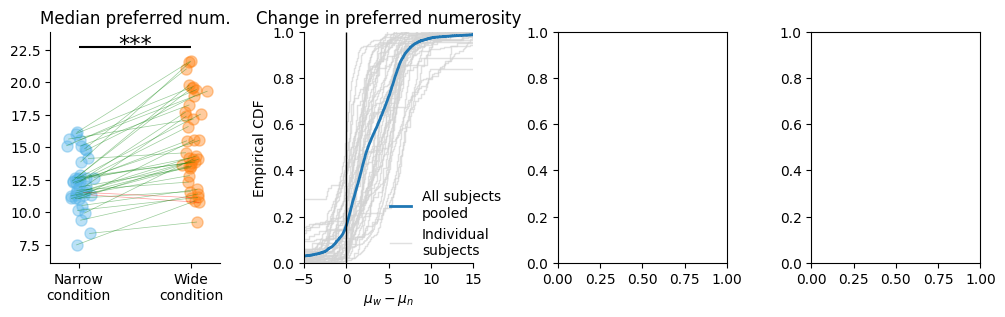

In [55]:
######## Bottom row
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(12, 3))

######## Median preferred numerosities
ax = axs[0]
mu_wide_medians = df3[('mu', 'wide')].groupby('subject').median()
mu_narrow_medians = df3[('mu', 'narrow')].groupby('subject').median()
print( (mu_wide_medians >= mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition larger than in Narrow condition' )
print( (mu_wide_medians <  mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition smaller than in Narrow condition' )
paired_strip_plot(ax, x1=1, x2=2, y1=mu_narrow_medians, y2=mu_wide_medians, 
                  col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='g', color_decr_line='r',)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_title("Median preferred num.")
ax.set_xlim(0.75, 2.25)
ax.set_ylim(6.1,23.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# paired test
paired_test = pg.ttest(mu_narrow_medians, mu_wide_medians, paired=True)
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
ax.hlines(0.95*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
ax.text(1.5, 0.96*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')


######## CDF of change in preferred numerosity
ax = axs[1]
all_data = []
#ind = (df3.mu.narrow>=10) & (df3.mu.wide>=10) #& (df3.mu.narrow<=40) & (df3.mu.wide<=40)
subjects = df3.index.get_level_values('subject').unique()
for subject in subjects:
    data = df3.xs(subject, level='subject')[('mu', 'delta_wn')]
    all_data.append(pd.DataFrame({'mu_delta_wn': data.dropna(), 'subject': subject}))
all_data = pd.concat(all_data, ignore_index=True)
# Plot the CDFs for each subject in light grey (no hue, loop over subjects)
c_ind = 'lightgrey'
for subject in subjects:
    subj_data = all_data[all_data['subject'] == subject]
    sns.ecdfplot(data=subj_data, x='mu_delta_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False, ax=ax)

# Plot the pooled CDF (all subjects together) in a bold color
sns.ecdfplot(data=all_data, x='mu_delta_wn', color='C0', linewidth=2, label='All subjects pooled', ax=ax)
print( (all_data.mu_delta_wn<0).mean() * 100, '% of voxels have $\mu_{w} - \mu_{n} < 0$' )

#plt.title("Empirical CDF of $\mu_{w} - \mu_{n}$")
ax.set_title("Change in preferred numerosity")
ax.set_xlabel('$\mu_{w} - \mu_{n}$')
ax.set_ylabel('Empirical CDF')
ax.legend(handles=[plt.Line2D([0], [0], color='C0', lw=2, label='All subjects\npooled'),
                    plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nsubjects')], loc=(.475,0), handlelength=1.5)
ax.set_xlim(-5, 15)
ax.vlines(0, 0, 1, color='black', linestyle='-', lw=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.subplots_adjust(wspace=0.5)

#fig.savefig('figures/bottom_row.pdf', bbox_inches='tight')

## For presentation

90.78% of voxels have 5 <= mu (narrow) <= 30 and 5 <= mu (wide) <= 30
9.22% of voxels have mu (narrow) or mu (wide) outside [5, 30]


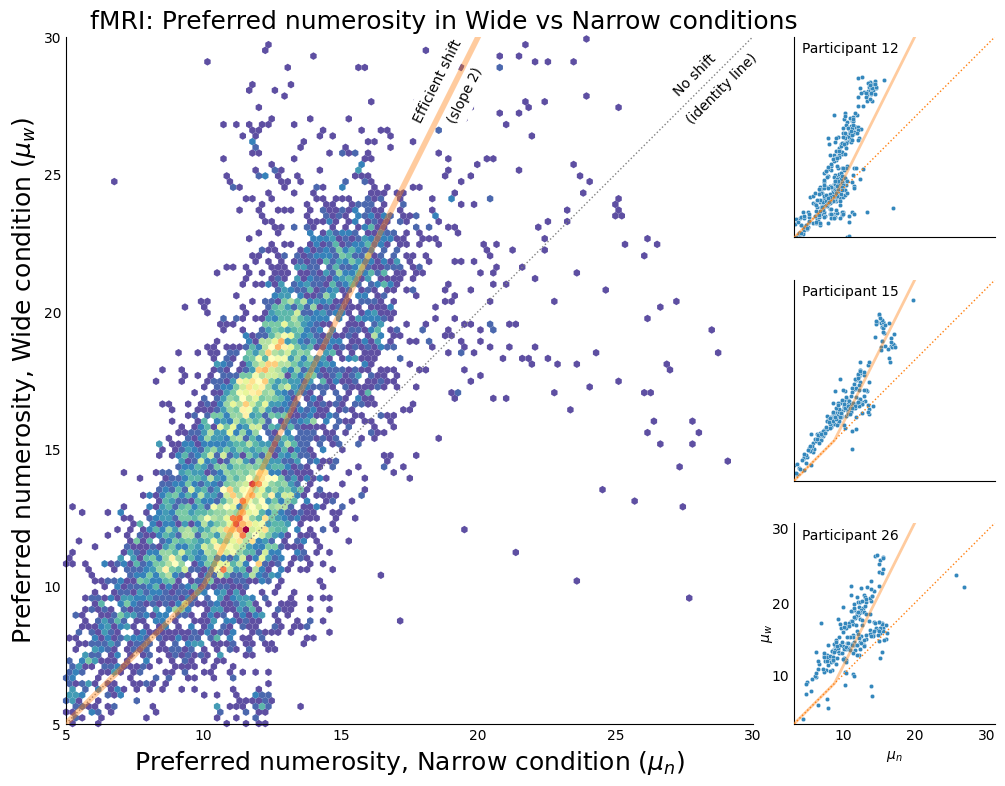

In [229]:
nrows = 4
#fig = plt.figure(figsize=(12, nrows*3))
gs = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2))
#fig, axs = plt.subplots(nrows=nrows, ncols=4, figsize=(12, nrows*3), height_ratios=(1,1,1,1.2))
fig = plt.figure(figsize=(12, (nrows+.2)*3))
#ax = fig.add_subplot(nrows,4,(1,11))
ax = fig.add_subplot(gs[:3, :3])
ax.set_aspect('equal') #, adjustable='box')

cmap = plt.cm.Spectral_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', 
MUMU_COLOR = cmap(.1) # THIRD_COLOR
LINE_COLOR = 'C1' #'xkcd:pastel pink' #'C1'

nmin = 5
nmax = 30
ind = (df3.mu.narrow>=nmin) & (df3.mu.wide>=nmin) & (df3.mu.narrow<=nmax) & (df3.mu.wide<=nmax)
print(f'{ind.mean()*100:.2f}% of voxels have {nmin} <= mu (narrow) <= {nmax} and {nmin} <= mu (wide) <= {nmax}')
print(f'{(~ind).mean()*100:.2f}% of voxels have mu (narrow) or mu (wide) outside [{nmin}, {nmax}]')
hb = ax.hexbin(df3[ind].mu.narrow, df3[ind].mu.wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0.,
          cmap=cmap, mincnt=1, edgecolors='none', clip_on=False)

# Colorbar
# cbar_ax = ax.inset_axes([0.97, 0.5, .01, .2])
# cb = fig.colorbar(hb, cax=cbar_ax, label='Count', ticks=[1,25,49], drawedges=False)
# cb.ax.yaxis.set_label_position('left')
# #cb.ax.yaxis.tick_left()
# cbar_ax.tick_params(axis='both', length=0)
# cb.outline.set_visible(False)

ax.set_xlim(nmin,nmax); ax.set_ylim(nmin,nmax)
ax.axline((nmin,nmin), slope=1, color='grey', ls=':', lw=1, zorder=100)
ax.plot([nmin, 10, 40], [nmin, 10, 70], c=LINE_COLOR, lw=4, alpha=.4, zorder=100)
ax.set_xlabel('Preferred numerosity, Narrow condition ($\mu_n$)', fontsize=18)
ax.set_ylabel('Preferred numerosity, Wide condition ($\mu_w$)', fontsize=18)
ax.set_title('fMRI: Preferred numerosity in Wide vs Narrow conditions', x=.55, y=1., fontsize=18)
ax.text(28.75, 28.5+1, 'No shift', fontsize=10, ha='right', va='top', rotation=45)
ax.text(30.25, 28.5+1, '(identity line)', fontsize=10, ha='right', va='top', rotation=45)
ax.text(19.5, 29+1,   'Efficient shift', fontsize=10, ha='right', va='top', rotation=63.43, backgroundcolor='w')
ax.text(20.25, 28+1, '(slope 2)', fontsize=10, ha='right', va='top', rotation=63.43, backgroundcolor='w')
#ax.text(22.5, 35+1,   'Efficient shift', fontsize=10, ha='right', va='top', rotation=63.43, backgroundcolor='w')
#ax.text(23.5, 33.7+1, '(slope 2)', fontsize=10, ha='right', va='top', rotation=63.43)
#ax.grid()
ax.set_yticks([5,10,15,20,25,30])

ax.tick_params(axis='both', length=0)

sns.despine(fig)

###### Individual subjects
select_subjs = [12,15,26]
axS1 = fig.add_subplot(gs[0, 3]) # fig.add_subplot(nrows,4,4)
sns.scatterplot(data=index_filter(df3, subject=12).mu, x='narrow', y='wide', color=MUMU_COLOR, s=10, alpha=1, ax=axS1)
axS2 = fig.add_subplot(gs[1, 3]) # fig.add_subplot(nrows,4,8)
sns.scatterplot(data=index_filter(df3, subject=15).mu, x='narrow', y='wide', color=MUMU_COLOR, s=10, alpha=1, ax=axS2)
axS3 = fig.add_subplot(gs[2, 3]) # fig.add_subplot(nrows,4,12)
sns.scatterplot(data=index_filter(df3, subject=26).mu, x='narrow', y='wide', color=MUMU_COLOR, s=10, alpha=1, ax=axS3)
for ii,ax in enumerate([axS1, axS2, axS3]):
    ax.set_aspect('equal')
    ax.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=1, zorder=100)
    ax.plot([0, 10, 40], [0, 10, 70], c=LINE_COLOR, lw=2, alpha=.4, zorder=100)
    ax.set_xlim(5, 30); ax.set_ylim(5, 30)
    ax.set_xlabel(None); ax.set_ylabel(None)
    ax.set_xticks([]); ax.set_yticks([])
    #ax.text(20, 10, f'Subject {select_subjs[ii]}', fontsize=10)
    ax.text(6, 28, f'Participant {select_subjs[ii]}', fontsize=10, ha='left')
#axS1.set_title('Individual participants')
#axS3.set_xticks([5, 10, 15, 20, 25, 30]); axS3.set_yticks([5, 10, 15, 20, 25, 30]);
axS3.set_xticks([10,20,30]); axS3.set_yticks([10,20,30]);
#ax.set_xticklabels([]); ax.set_yticklabels([]);
axS3.tick_params(axis='both', length=0) # labelsize=8, 
axS3.get_xticklabels()[0].set_ha('left'); axS3.get_xticklabels()[-1].set_ha('right')
axS3.get_yticklabels()[-1].set_va('top'); axS3.get_yticklabels()[0].set_va('bottom')
axS3.set_xlabel('$\mu_n$')
axS3.set_ylabel('$\mu_w$', labelpad=-2, y=.45)

######## Bottom row
gs2 = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2), hspace=.5, width_ratios=(.9,1.1,1,1), wspace=.4)

if False:
    ######## Median preferred numerosities
    ax = fig.add_subplot(gs2[3,0])

    mu_wide_medians = df3[('mu', 'wide')].groupby('subject').median()
    mu_narrow_medians = df3[('mu', 'narrow')].groupby('subject').median()
    print( (mu_wide_medians >= mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition larger than in Narrow condition' )
    print( (mu_wide_medians <  mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition smaller than in Narrow condition' )
    paired_strip_plot(ax, x1=1, x2=2, y1=mu_narrow_medians, y2=mu_wide_medians, 
                    col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='limegreen', color_decr_line='r',)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
    #ax.set_title("Median preferred num.")
    ax.set_title("Median $\mu_n, \mu_w$")
    ax.set_xlim(0.75, 2.25)
    ax.set_ylim(6.1,24.5) #23.9)
    # paired test
    paired_test = pg.ttest(mu_narrow_medians, mu_wide_medians, paired=True)
    print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
    # ax.hlines(0.95*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
    # ax.text(1.5, 0.96*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')
    star_line(ax, 1, 2, 22.5, paired_test['p-val'].iloc[0], star_size=15, star_offset=-.5)

    ax.tick_params(axis='both', length=0)
    ax.spines.left.set_bounds((7, 22))
    ax.spines.bottom.set_bounds((.9, 2.1))

    ######## CDF of change in preferred numerosity
    ax = fig.add_subplot(gs2[3,1])
    all_data = []
    #ind = (df3.mu.narrow>=10) & (df3.mu.wide>=10) #& (df3.mu.narrow<=40) & (df3.mu.wide<=40)
    subjects = df3.index.get_level_values('subject').unique()
    for subject in subjects:
        data = df3.xs(subject, level='subject')[('mu', 'delta_wn')]
        all_data.append(pd.DataFrame({'mu_delta_wn': data.dropna(), 'subject': subject}))
    all_data = pd.concat(all_data, ignore_index=True)
    # Plot the CDFs for each subject in light grey (no hue, loop over subjects)
    c_ind = 'lightgrey'
    for subject in subjects:
        subj_data = all_data[all_data['subject'] == subject]
        sns.ecdfplot(data=subj_data, x='mu_delta_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False, ax=ax)
    # Plot the pooled CDF (all subjects together) in a bold color
    this_color = 'k'; this_lw = 1.5
    sns.ecdfplot(data=all_data, x='mu_delta_wn', color=this_color, linewidth=this_lw, label='Participants pooled', ax=ax, legend=False) # THIRD_COLOR
    print( (all_data.mu_delta_wn<0).mean() * 100, '% of voxels have $\mu_{w} - \mu_{n} < 0$' )
    ax.set_title("Distribution of $\mu_{w} - \mu_{n}$")
    #ax.set_title("Change in preferred numerosity")
    ax.set_xlabel('$\mu_{w} - \mu_{n}$')
    ax.set_ylabel('Empirical CDF')
    ax.legend(handles=[plt.Line2D([0], [0], color=this_color, lw=this_lw, label='Participants\npooled'),
                        plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nparticipants')], loc=(.475,0),
                        handlelength=1.5, frameon=False)
    ax.set_xlim(-5, 15)
    ax.vlines(0, 0, 1, color='black', linestyle='-', lw=1)
    ax.set_yticks([0, .2, .4, .6, .8, 1])
    ax.set_yticklabels(['0', '.2', '.4', '.6', '.8', '1'])
    ax.tick_params(axis='both', length=0)


    ########### Distribution delta_wide
    ax = fig.add_subplot(gs2[3,2])
    ratio_mu = dfe5.delta_wide.narrow.groupby('subject').first()
    nb_bins_02 = 3
    dw = 2 / (nb_bins_02 + 1/2)
    bins = np.arange(0, ratio_mu.max()+dw, dw)
    this_color = 1 - .4*( 1 -  np.array( plt.cm.Spectral_r(.02)[:3] ) ) # equivalent to the color with some alpha, on white. (With cB = 1 - alpha*(1-cA), color cB is like (cA,alpha) on white.)
    sns.histplot(ratio_mu, bins=bins, ax=ax, color=this_color, linewidth=.5, element='step', ec='k') # plt.cm.RdYlBu(0.4)
    ax.set_title("Best-fitting slopes")
    ax.set_xlabel('Participant-specific slopes')
    ax.set_yticks([0, 5, 10, 15])
    ax.set_ylabel('Participants count', labelpad=0)
    ax.tick_params(axis='both', length=0)
    # ax.axvline(2, color=LINE_COLOR, linestyle='-', lw=1)
    ax.axvline(ratio_mu.median(), color='k', linestyle='-', lw=1)
    ax.text(ratio_mu.median()-.05, 4., f'median$\\approx${ratio_mu.median():.2f}', rotation=90, va='center', ha='right', fontsize=9)


    ########## Proportion cvR2>0
    ax = fig.add_subplot(gs2[3,3])
    modelz = dict( [(0, 'No shift'), (3, 'Free shifts'), (4, 'Efficient shifts'), (5, 'Participant-specific slopes')] )
    these_rez = rez_est.loc[:,list(modelz.keys())].rename(columns=modelz)
    these_rez
    #sns.stripplot(these_rez, color=FOURTH_COLOR) 
    sns.pointplot(these_rez, errorbar='se', color='k', markersize=5, linewidth=1, ax=ax) # THIRD_COLOR
    ax.set_xlabel(None)
    #### x ticks labels positions
    ax.tick_params(axis='both', length=0)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor")
    # Create offset transform
    dx = 12./72.; dy = 2/72. 
    offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
    # apply offset transform to all x ticklabels.
    for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
    ax.set_xlim(-.5,3.5)
    #### y 
    ax.set_yticks([.24, .26, .28, .3, .32])
    ax.set_yticklabels(['.24', '.26', '.28', '.30', '.32'])
    ax.set_ylabel('% $cvR^2 > 0$', y=.5, ha='right')
    #ax.set_ylim(.23, .33)
    ax.spines.left.set_bounds((.24, .32))
    ax.spines.bottom.set_bounds((0, 3))
    sns.despine(fig)
    # (0,4), (3,4), (5,4) 
    vll = 0.005
    star_size = 15
    star_offset = -.0025
    star_line(ax, 0, 2, .355, compare_res_est.loc[(0,4)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
    star_line(ax, 1, 2, .340, compare_res_est.loc[(3,4)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
    #star_line(ax, 3, 2, .365, compare_res_est.loc[(4,5)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
    onesided_test = pg.ttest(x=rez_est[4], y=rez_est[5], paired=True, alternative='greater')
    notonesided_test = pg.ttest(x=rez_est[4], y=rez_est[5], paired=True)
    star_line(ax, 3, 2, .365, notonesided_test.iloc[0]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
    print(notonesided_test)
    ax.set_title('Models fits')
    ax.set_ylim(None, .38)

sns.despine(fig)
#sns.despine(ax=icon_ax, left=True)

fig.savefig('figures/pres_mu_wide_vs_narrow.pdf', bbox_inches='tight')

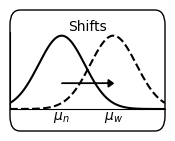

In [163]:
##### Icon
icon_width = 0.2; icon_height = .08
fig, icon_ax = plt.subplots(figsize=(2, 1))
#inset_ax = fig.add_axes([inset_width/2, 0.8, inset_width, inset_width], )
xxs = np.linspace(0, 3, 1000)
icon_ax.plot(xxs, np.exp(-(xxs-1)**2/.4), color='k') 
icon_ax.plot(xxs, np.exp(-(xxs-2)**2/.4), color='k', linestyle='--')
icon_ax.arrow(x=1, y=0.35, dx=1, dy=0, color='k', lw=1, head_width=0.1, head_length=0.1, length_includes_head=True, zorder=100)
icon_ax.set_ylim(0, None)
icon_ax.set_xlim(0, 3)
icon_ax.set_yticks([])
icon_ax.set_xticks([1,2])
icon_ax.set_xticklabels(['$\mu_n$', '$\mu_w$'])
icon_ax.tick_params(axis='x', length=0, pad=0.5, labelsize=10)
bb = mtransforms.Bbox([[0., -.3], [3, 1.35]])
fancy = FancyBboxPatch(bb.p0, bb.width, bb.height, clip_on=False, facecolor="w", boxstyle="round,pad=0,rounding_size=0.2") # zorder=1000000)
icon_ax.add_patch(fancy)
icon_ax.set_title('Shifts', fontsize=10, y=.9, ha='center')
sns.despine(fig)
fig.savefig('figures/icon_mu_shift.pdf', bbox_inches='tight')

# Model 14 (free sds)

98.06% of voxels have 0 <= mu (narrow) <= 40 and 0 <= mu (wide) <= 40
1.94% of voxels have mu (narrow) or mu (wide) outside [0, 40]
37 subjects have median $\mu$ in Wide condition larger than in Narrow condition
2 subjects have median $\mu$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -8.983, p = 6.16e-11, dof = 38
16.15884115884116 % of voxels have $\mu_{w} - \mu_{n} < 0$
               T  dof alternative     p-val        CI95%   cohen-d   BF10     power
T-test  2.592253   38   two-sided  0.013459  [0.0, 0.02]  0.053155  3.196  0.062084


98.06% of voxels have 0 <= mu (narrow) <= 40 and 0 <= mu (wide) <= 40
1.94% of voxels have mu (narrow) or mu (wide) outside [0, 40]
37 subjects have median $\mu$ in Wide condition larger than in Narrow condition
2 subjects have median $\mu$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -8.983, p = 6.16e-11, dof = 38
16.15884115884116 % of voxels have $\mu_{w} - \mu_{n} < 0$
               T  dof alternative     p-val        CI95%   cohen-d   BF10     power
T-test  2.592253   38   two-sided  0.013459  [0.0, 0.02]  0.053155  3.196  0.062084


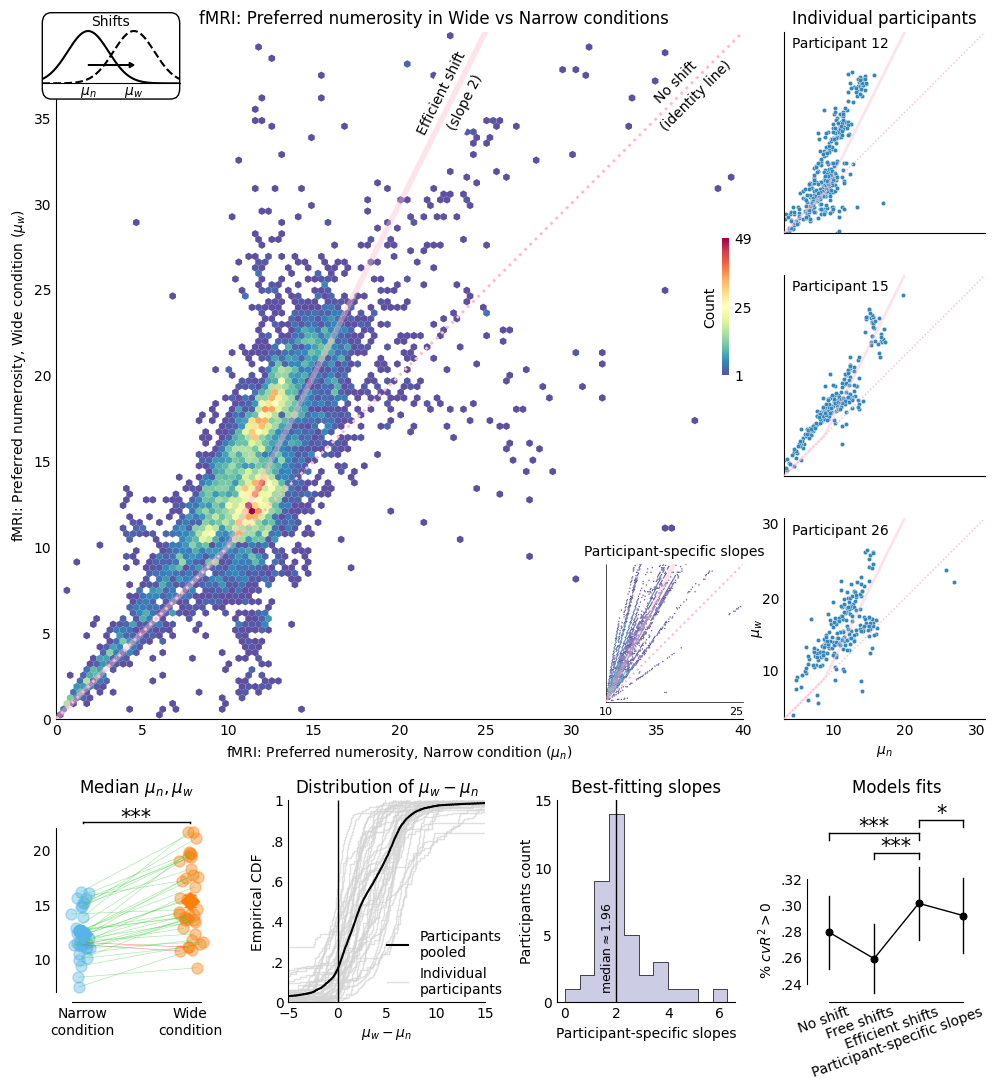

In [317]:
dfgt14 = index_filter(pars, type='ground_truth', smoothed=True, model_label=14)
dfgt14 = dfgt14[ dfgt14[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
dfgt14.index.rename(['subject', 'voxel'], inplace=True)
dfgt14

dfest14 = index_filter(pars, type='estimates', smoothed=True, model_label=14)
dfest14 = dfest14[ dfest14[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
dfest14.index.rename(['subject', 'voxel'], inplace=True)
dfest14

In [167]:
# dfest14[('sd_nat', 'narrow')] = dfest14.mu.narrow * np.sqrt( np.exp(dfest14.sd.narrow**2) - 1 )
# dfest14[('sd_nat', 'wide')] = dfest14.mu.wide * np.sqrt( np.exp(dfest14.sd.wide**2) - 1 )
# dfgt14[('sd_nat', 'narrow')] = dfgt14.mu.narrow * np.sqrt( np.exp(dfgt14.sd.narrow**2) - 1 )
# dfgt14[('sd_nat', 'wide')] = dfgt14.mu.wide * np.sqrt( np.exp(dfgt14.sd.wide**2) - 1 )

# dfest14[('fwhm_nat', 'narrow')] = 2 * dfest14.mu.narrow * np.sinh(dfest14.sd.narrow * np.sqrt(2 * np.log(2)))
# dfest14[('fwhm_nat', 'wide')]   = 2 * dfest14.mu.wide * np.sinh(dfest14.sd.wide * np.sqrt(2 * np.log(2)))
# dfgt14[('fwhm_nat', 'narrow')]  = 2 * dfgt14.mu.narrow * np.sinh(dfgt14.sd.narrow * np.sqrt(2 * np.log(2)))
# dfgt14[('fwhm_nat', 'wide')]    = 2 * dfgt14.mu.wide * np.sinh(dfgt14.sd.wide * np.sqrt(2 * np.log(2)))

In [168]:
(dfest14[dfest14.mu.narrow>=10].mu.wide-10) / (dfest14[dfest14.mu.narrow>=10].mu.narrow-10)

subject  voxel
1        10       2.0
         13       2.0
         16       2.0
         19       2.0
         20       2.0
                 ... 
41       684      2.0
         686      2.0
         687      2.0
         689      2.0
         691      2.0
Length: 7104, dtype: float64

In [169]:
print( pg.corr( dfgt14.sd.narrow, dfgt14.sd.wide ) )

            n         r         CI95%          p-val       BF10  power
pearson  7977  0.267562  [0.25, 0.29]  7.700274e-131  5.64e+126    1.0


In [170]:
#( subject_sd_corrs['p-val'] < 0.05 ).mean()

In [171]:
print( pg.corr( dfest14.sd.narrow, dfest14.sd.wide ) )
subject_sd_corrs = dfest14.groupby(level='subject').apply(lambda g: pg.corr(g.sd.narrow, g.sd.wide))
subject_sd_corrs.describe(percentiles=[.1, .15, .2, .25, .5, .75, .8, .85, .9])

            n         r         CI95%          p-val        BF10  power
pearson  8827  0.232262  [0.21, 0.25]  1.958039e-108  2.352e+104    1.0


,n,r,p-val,power
count,39.000000,39.000000,3.900000e+01,39.000000
mean,226.333333,0.550051,9.329555e-02,0.834962
std,148.421401,0.332374,2.302159e-01,0.332600
min,44.000000,-0.034489,1.843030e-278,0.050922
10%,80.200000,0.090830,1.691834e-169,0.101648
15%,90.700000,0.171532,6.776104e-148,0.408210
20%,95.800000,0.226611,4.547283e-109,0.795047
25%,101.000000,0.313933,1.663686e-76,0.966005
50%,171.000000,0.511777,2.858754e-13,1.000000
75%,332.000000,0.892801,1.769752e-04,1.000000


In [172]:
( subject_sd_corrs['r'] > 0. ).sum(), ( subject_sd_corrs['r'] <= 0. ).sum()

(38, 1)

In [173]:
subject_sd_corrs[subject_sd_corrs['r'] > 0.].describe()

,n,r,p-val,power
count,38.000000,38.000000,3.800000e+01,38.000000
mean,226.289474,0.565433,7.984494e-02,0.854797
std,150.413468,0.322459,2.172217e-01,0.312818
min,44.000000,0.010965,1.843030e-278,0.050922
25%,100.500000,0.327926,1.294529e-76,0.974760
50%,169.000000,0.521195,1.431524e-13,1.000000
75%,342.500000,0.905195,1.280906e-04,1.000000
max,535.000000,0.983901,9.216275e-01,1.000000


In [174]:
# this should be corrected for multiple tests
( subject_sd_corrs[subject_sd_corrs['r'] > 0.]['p-val'] < 0.05 ).mean()

0.868421052631579

In [175]:
rej, pvals_corr = pg.multicomp(subject_sd_corrs[subject_sd_corrs['r'] > 0.]['p-val'])
rej.mean(), (pvals_corr < 0.05).mean(), (pvals_corr < 0.01).mean(), (pvals_corr < 0.001).mean()

(0.8157894736842105,
 0.8157894736842105,
 0.7894736842105263,
 0.7368421052631579)

In [176]:
dfest14

parameter             mu                   sd           delta_wide      amplitude            baseline                  r2      cvr2
range             narrow       wide    narrow      wide     narrow wide    narrow      wide    narrow      wide       nan       nan
subject voxel                                                                                                                      
1       10     12.181757  14.363514  0.692355  1.001164        2.0  2.0  1.356081  1.356081 -1.472868 -1.472868  0.024319  0.007944
        13     11.979450  13.958900  0.401673  0.546460        2.0  2.0  0.632903  0.632903 -0.612679 -0.612679  0.029108  0.008833
        16     11.622056  13.244112  0.359948  0.441931        2.0  2.0  0.422997  0.422997 -0.392825 -0.392825  0.023620  0.000943
        19     10.287462  10.574924  0.395287  0.442017        2.0  2.0  0.400638  0.400638 -0.349652 -0.349652  0.026793  0.001557
        20     10.003069  10.006138  0.572352  0.672433        2.0  2.0  0.665699  0.665699 -0.738390 -0.738390  0.029158  0.010135
...                  ...        ...       ...       ...        ...  ...       ...       ...       ...       ...       ...       ...
41      684    15.565413  21.130827  0.095523  0.149099        2.0  2.0  0.279757  0.279757  0.164614  0.164614  0.041674  0.016693
        686    11.275817  12.551634  0.311528  0.221549        2.0  2.0  0.315620  0.315620 -0.230035 -0.230035  0.027359  0.002267
        687    11.196170  12.392340  0.310941  0.198242        2.0  2.0  0.332232  0.332232 -0.056568 -0.056568  0.031147  0.004594
        689    13.385760  16.771520  0.743725  1.033240        2.0  2.0  0.764908  0.764908 -0.328955 -0.328955  0.027378  0.002505
        691    13.528701  17.057402  0.654947  0.945158        2.0  2.0  0.603408  0.603408 -0.276618 -0.276618  0.021567  0.002261

[8827 rows x 12 columns]

In [177]:
pg.rm_corr

<function pingouin.correlation.rm_corr(data=None, x=None, y=None, subject=None)>

In [102]:
# print( pg.corr( dfgt14.fwhm_nat.narrow, dfgt14.fwhm_nat.wide ) )
# dfgt14.groupby(level='subject').apply(lambda g: pg.corr(g.fwhm_nat.narrow, g.fwhm_nat.wide)).describe(percentiles=[.5, .75, .8, .85, .9])

In [103]:
# print( pg.corr( dfest14.fwhm_nat.narrow, dfest14.fwhm_nat.wide ) )
# dfest14.groupby(level='subject').apply(lambda g: pg.corr(g.fwhm_nat.narrow, g.fwhm_nat.wide)).describe(percentiles=[.5, .75, .8, .85, .9])

In [104]:
for zz in ['sd',]: # 'sd_nat', 'fwhm_nat']:
    dfgt14[zz, 'delta_wn'] = dfgt14[zz, 'wide'] - dfgt14[zz, 'narrow']
    dfgt14[zz, 'ratio_wn'] = dfgt14[zz, 'wide'] / dfgt14[zz, 'narrow']
    dfest14[zz, 'delta_wn'] = dfest14[zz, 'wide'] - dfest14[zz, 'narrow']
    dfest14[zz, 'ratio_wn'] = dfest14[zz, 'wide'] / dfest14[zz, 'narrow']

32 subjects have median $\sigma$ in Wide condition larger than in Narrow condition
7 subjects have median $\sigma$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -6.268, p = 2.44e-07, dof = 38


/var/folders/jq/_79_qpxx3vd0thkqqmw37l1c0000gn/T/ipykernel_28505/2538833436.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Paired t-test: t = {paired_test['T'][0]:.3f}, p = {paired_test['p-val'][0]:.3g}, dof = {paired_test['dof'][0]}")


Text(1.5, 1.4725, '***')

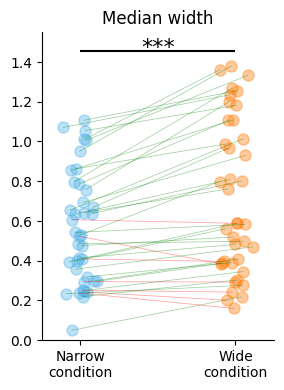

In [105]:
# Compute per-subject medians for 'mu' in 'wide' and 'narrow'
#nmax = 40
this_df = dfest14
#ind = this_df == this_df # true everywhere (except nans but idc)
#ind = (this_df.mu.narrow>=0) & (this_df.mu.wide>=0) & (this_df.mu.narrow<=nmax) & (this_df.mu.wide<=nmax)
sd_wide_medians = this_df[('sd', 'wide')].groupby('subject').median()
sd_narrow_medians = this_df[('sd', 'narrow')].groupby('subject').median()
print( (sd_wide_medians >= sd_narrow_medians).sum(), 'subjects have median $\sigma$ in Wide condition larger than in Narrow condition' )
print( (sd_wide_medians <  sd_narrow_medians).sum(), 'subjects have median $\sigma$ in Wide condition smaller than in Narrow condition' )

fig, ax = plt.subplots(figsize=(3, 4))
paired_strip_plot(ax, x1=1, x2=2, y1=sd_narrow_medians, y2=sd_wide_medians, 
                  col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='g', color_decr_line='r',)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_title("Median width")
ax.set_xlim(0.75, 2.25)
ax.set_ylim(0.,1.55)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# paired test
paired_test = pg.ttest(sd_narrow_medians, sd_wide_medians, paired=True)
print(f"Paired t-test: t = {paired_test['T'][0]:.3f}, p = {paired_test['p-val'][0]:.3g}, dof = {paired_test['dof'][0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
ax.hlines(0.94*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
ax.text(1.5, 0.95*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')

#fig.savefig('figures/delta_median_sd.pdf', bbox_inches='tight')

22.544465843434917 % of voxels have $\sigma_{w} - \sigma_{n} < 0$


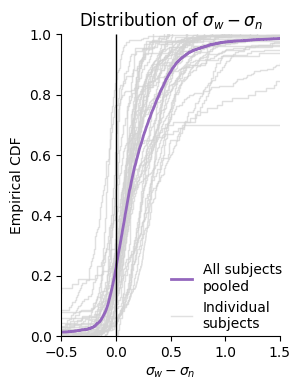

In [106]:
fig, ax = plt.subplots(figsize=(3, 4))
all_data = []
this_df = dfest14
#ind = (df3.mu.narrow>=10) & (df3.mu.wide>=10) #& (df3.mu.narrow<=40) & (df3.mu.wide<=40)
qty = 'delta' # delta or ratio
subjects = this_df.index.get_level_values('subject').unique()
for subject in subjects:
    data = this_df.xs(subject, level='subject')[('sd', f'{qty}_wn')]
    all_data.append(pd.DataFrame({f'sd_{qty}_wn': data.dropna(), 'subject': subject}))
all_data = pd.concat(all_data, ignore_index=True)
# Plot the CDFs for each subject in light grey (no hue, loop over subjects)
c_ind = 'lightgrey'
for subject in subjects:
    subj_data = all_data[all_data['subject'] == subject]
    sns.ecdfplot(data=subj_data, x=f'sd_{qty}_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False)

# Plot the pooled CDF (all subjects together) in a bold color
sns.ecdfplot(data=all_data, x=f'sd_{qty}_wn', color=FOURTH_COLOR, linewidth=2, label='All subjects pooled')
print( (all_data.sd_delta_wn<0).mean() * 100, '% of voxels have $\sigma_{w} - \sigma_{n} < 0$' )

#plt.title("Empirical CDF of $\sigma_{w} - \sigma_{n}$")
plt.gca().set_title("Distribution of $\sigma_{w} - \sigma_{n}$")
plt.xlabel('$\sigma_{w} - \sigma_{n}$')
plt.ylabel('Empirical CDF')
plt.legend(handles=[plt.Line2D([0], [0], color=FOURTH_COLOR, lw=2, label='All subjects\npooled'),
                    plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nsubjects')], loc=(.475,0), handlelength=1.5)
plt.tight_layout()
if qty=='delta':
    plt.xlim(-.5, 1.5)
else:
    plt.xlim(0.5, 3.)
    #plt.vlines(np.sqrt(2), 0, 1, color='black', linestyle='-', lw=1)
plt.vlines(0 if qty=='delta' else 1, 0, 1, color='black', linestyle='-', lw=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#fig.savefig('figures/cdf_delta_sd.pdf', bbox_inches='tight')

2.435708621275632% of the data not shown in the figure (σ>3)


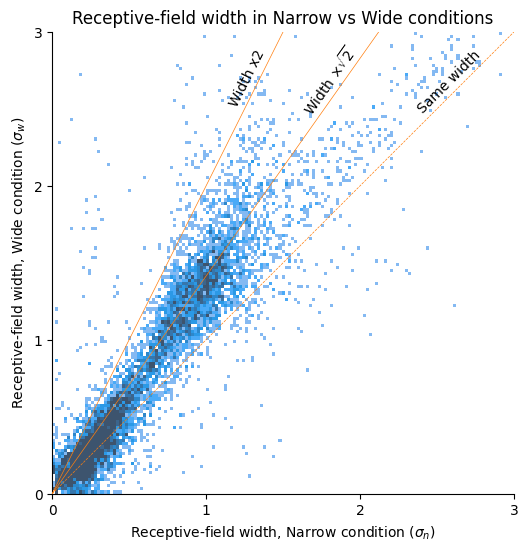

In [107]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal') #, adjustable='box')
#nmax = 40
this_df = dfest14
ind = this_df == this_df # true everywhere (except nans but idc)
#ind = (this_df.mu.narrow>=10) & (this_df.mu.wide>=10) #& (this_df.mu.narrow<=nmax) & (this_df.mu.wide<=nmax)
#sns.displot(this_df[ind].mu, x='narrow', y='wide', kind='hist', bins=41)
sns.histplot(this_df[ind].sd, x='narrow', y='wide', bins=801, ax=ax, pmax=.6, alpha=1)
#sns.scatterplot(this_df[ind].mu, x='narrow', y='wide', color='C0', s=1, ax=ax, alpha=1, ec='none')
#sns.displot(this_df[ind].mu, x='narrow', y='wide', kind='kde', bins=41, ax=ax)
#sns.kdeplot(this_df[ind].mu, x='narrow', y='wide', ax=ax, levels=5, color='lightgrey', thresh=.1, linewidth=1, zorder=-1000)
σmax = 3
print( f'{( (this_df[ind].sd.narrow > σmax) | (this_df[ind].sd.wide > σmax) ).mean()*100}% of the data not shown in the figure (σ>{σmax})' )
ax.set_xlim(0,σmax); ax.set_ylim(0,σmax)
ax.axline((0,0), slope=1, color='C1', ls='--', lw=.5, zorder=100)
ax.plot([0, σmax], [0, 2*σmax], c='C1', lw=.5, zorder=100)
ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c='C1', lw=.5, zorder=100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Receptive-field width, Narrow condition ($\sigma_n$)')
ax.set_ylabel('Receptive-field width, Wide condition ($\sigma_w$)')
ax.set_title('Receptive-field width in Narrow vs Wide conditions')
ax.text(2.8, 2.8+.1, 'Same width', fontsize=10, ha='right', va='top', rotation=45)
ax.text(1.4, 2.8+.1, 'Width x2', fontsize=10, ha='right', va='top', rotation=63.43)
ax.text(2., 2.*np.sqrt(2)+.1, 'Width $\\times\sqrt{2}$', fontsize=10, ha='right', va='top', rotation=54.74)
ax.set_yticks([0, 1, 2, 3])
ax.set_xticks([0, 1, 2, 3]);
# #ax.grid()
#fig.savefig('figures/sd_wide_vs_narrow.pdf', bbox_inches='tight')

KstestResult(statistic=0.10479211510139345, pvalue=1.3449304601018732e-42, statistic_location=0.1892282093172289, statistic_sign=-1)
KstestResult(statistic=0.07658321060382917, pvalue=6.262444195901533e-23, statistic_location=0.19185430278445154, statistic_sign=-1)


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,5.658235,8826,two-sided,1.577141e-08,"[0.05, 0.1]",0.074875,1.039e+05,1.0


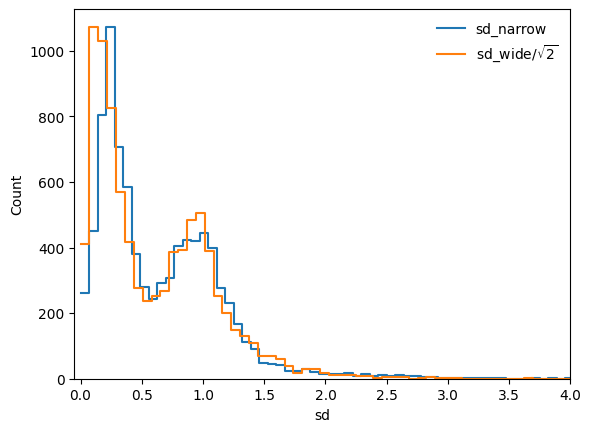

In [287]:
cu = False
dfx14 = dfest14
sns.histplot( dfx14.sd.narrow, label='sd_narrow', cumulative=cu, element='step', fill=False);
plt.gca().set_xlabel('sd')
sns.histplot( dfx14.sd.wide/np.sqrt(2), label='sd_wide$/\sqrt{2}$', cumulative=cu, element='step', fill=False)
plt.xlim(-.05,4); plt.legend()
print( stats.ks_2samp(dfx14.sd.narrow, dfx14.sd.wide/np.sqrt(2)))
print( stats.ks_2samp(dfx14.sd.narrow, dfx14.sd.wide/1.287794))
pg.ttest(x=dfx14.sd.narrow, y=dfx14.sd.wide/np.sqrt(2), paired=True)

8827


Text(0.5, 0, 'Receptive-field width (σ)')

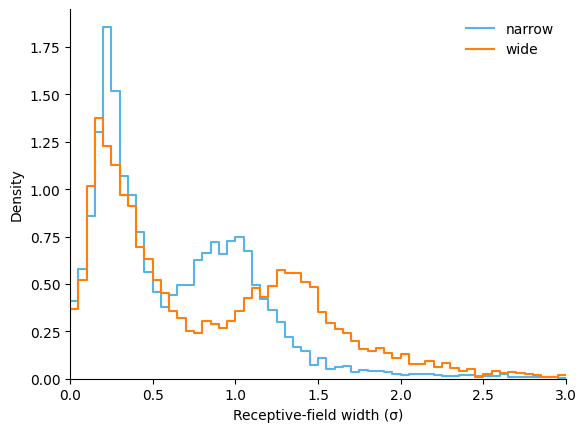

In [288]:
dx = 0.05
bins = np.arange(0., 3.+.000001, dx)
wscale = 1. #/np.sqrt(2)
# ind  = such that dfest14[ind] is dfest14
ind = dfest14.sd.narrow.notna()
#ind = dfest14.mu.narrow <= 10
print(sum(ind))
sns.histplot(dfest14[ind].sd.narrow, element='step', fill=False, color=COLORS_COND[NARROW], stat='density', label=NARROW,  binrange=(0, 3), bins=bins)
sns.histplot(dfest14[ind].sd.wide*wscale, element='step', fill=False, color=COLORS_COND[WIDE],   stat='density', label=WIDE,   binrange=(0, 3), bins=bins)
plt.legend()
sns.despine()
plt.xlim(0, 3)
plt.xlabel('Receptive-field width (σ)')

In [233]:
def odr_1dregression(x, y, data=None):
    if data is None:
        dat = odr.Data(x, y)
    else:
        dat = odr.Data(data[x], data[y])
    myodr = odr.ODR(dat, odr.unilinear, beta0=[1., 0.]) # start point = identity
    res = myodr.run()
    return res

def odr_pred(odr_res, x):
    B = odr_res.beta
    return B[0]*np.asarray(x) + B[1]

1688
[ 1.24194856 -0.02479528]
6924
[ 1.5223242  -0.11190925]
3355
[ 1.94075186 -0.55061768]
3569
[ 2.88080486 -0.4116956 ]


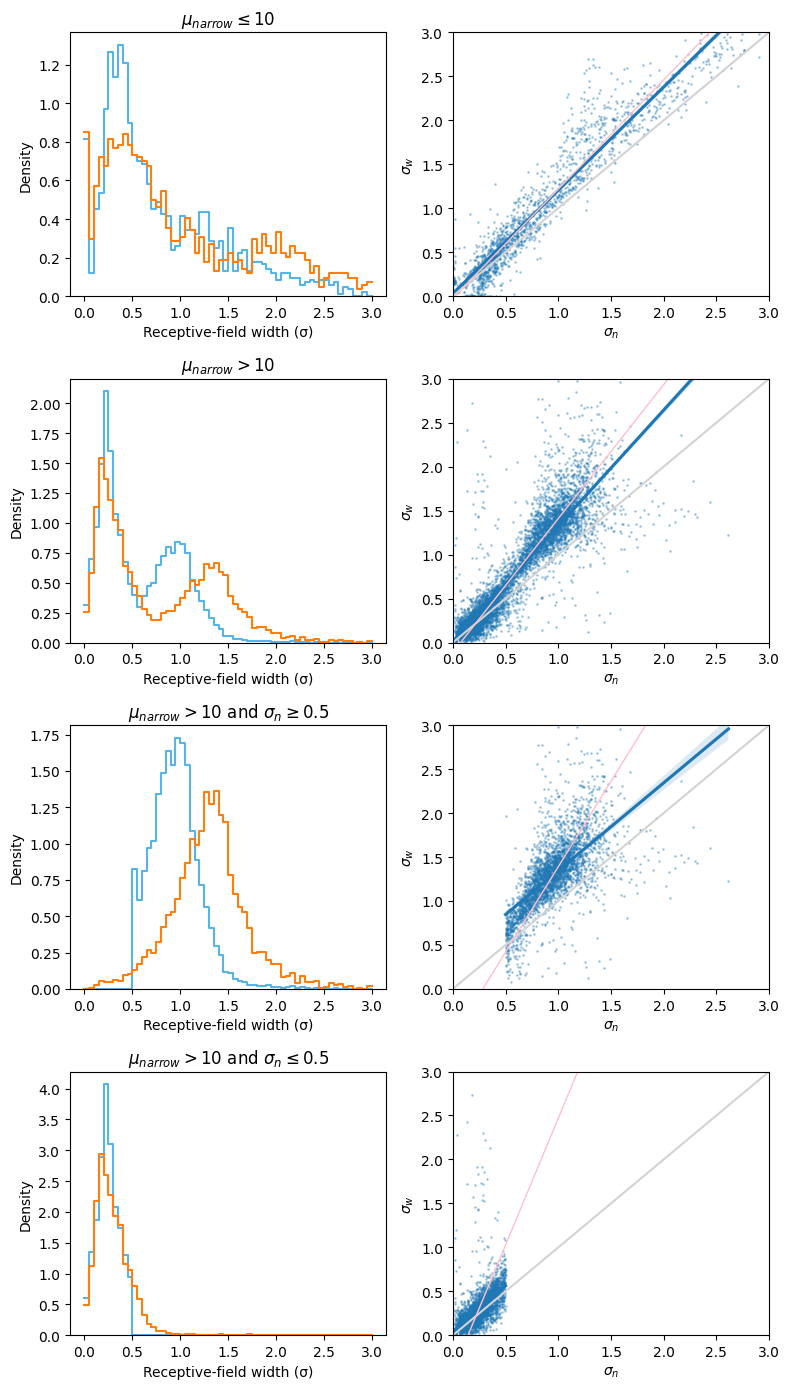

In [294]:
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(8, 14))

# sigma vs sigma when mu_narrow <= 10
ind = (dfest14.mu.narrow<=10) & (dfest14.sd.narrow<=3) & (dfest14.sd.wide<=3)
print(sum(ind))
ax = axs[0,0]
ax.set_title('$\mu_{narrow} \leq 10$')
ax.set_xlabel('Receptive-field width (σ)')
dx = 0.05
bins = np.arange(0., 3.+.000001, dx)
sns.histplot(dfest14[ind].sd.narrow, element='step', fill=False, color=COLORS_COND[NARROW], stat='density', label=NARROW,  binrange=(0, 3), bins=bins, ax=ax)
sns.histplot(dfest14[ind].sd.wide,   element='step', fill=False, color=COLORS_COND[WIDE],   stat='density', label=WIDE,   binrange=(0, 3), bins=bins, ax=ax)
ax = axs[0,1]
sns.regplot(x=dfest14.sd.narrow[ind], y=dfest14.sd.wide[ind], scatter_kws={'s':1, 'alpha':.3}, ax=ax)
ax.axline((0, 0), slope=1, color='lightgrey', linestyle='-')
#ax.axline((0,0), slope=1.3, color='pink', linestyle='-', lw=1)
res = odr_1dregression(dfest14[ind].sd.narrow, dfest14[ind].sd.wide); print(res.beta)
ax.plot( [0,3], odr_pred(res, [0,3]), color='pink', linestyle='-', lw=1)
ax.set_xlabel('$\sigma_n$'); ax.set_ylabel('$\sigma_w$')
ax.set_xlim(0,3); ax.set_ylim(0,3)

# sigma vs sigma when mu_narrow > 10
ind = (dfest14.mu.narrow>10) & (dfest14.sd.narrow<=3) & (dfest14.sd.wide<=3)
print(sum(ind))
ax = axs[1,0]
ax.set_title('$\mu_{narrow} > 10$')
ax.set_xlabel('Receptive-field width (σ)')
dx = 0.05
bins = np.arange(0., 3.+.000001, dx)
sns.histplot(dfest14[ind].sd.narrow, element='step', fill=False, color=COLORS_COND[NARROW], stat='density', label=NARROW,  binrange=(0, 3), bins=bins, ax=ax)
sns.histplot(dfest14[ind].sd.wide*wscale, element='step', fill=False, color=COLORS_COND[WIDE],   stat='density', label=WIDE,   binrange=(0, 3), bins=bins, ax=ax)
ax = axs[1,1]
sns.regplot(x=dfest14.sd.narrow[ind], y=dfest14.sd.wide[ind], scatter_kws={'s':1, 'alpha':.3}, ax=ax)
ax.axline((0, 0), slope=1, color='lightgrey', linestyle='-')
#ax.axline((0,0), slope=1.3, color='pink', linestyle='-', lw=1)
#ax.plot([.5, 2.], [.5, .5+1.5*2], color='pink', linestyle='-', lw=1)
res = odr_1dregression(dfest14[ind].sd.narrow, dfest14[ind].sd.wide); print(res.beta)
ax.plot( [0,3], odr_pred(res, [0,3]), color='pink', linestyle='-', lw=1)
ax.set_xlabel('$\sigma_n$'); ax.set_ylabel('$\sigma_w$')
ax.set_xlim(0,3); ax.set_ylim(0,3)

# sigma vs sigma when mu_narrow > 10 and sd_narrow >= .5
ind = (dfest14.mu.narrow>10) & (dfest14.sd.narrow>=.5) &  (dfest14.sd.narrow<=3) & (dfest14.sd.wide<=3)
print(sum(ind))
ax = axs[2,0]
ax.set_title('$\mu_{narrow} > 10$ and $\sigma_n \geq 0.5$')
ax.set_xlabel('Receptive-field width (σ)')
dx = 0.05
bins = np.arange(0., 3.+.000001, dx)
sns.histplot(dfest14[ind].sd.narrow, element='step', fill=False, color=COLORS_COND[NARROW], stat='density', label=NARROW,  binrange=(0, 3), bins=bins, ax=ax)
sns.histplot(dfest14[ind].sd.wide,   element='step', fill=False, color=COLORS_COND[WIDE],   stat='density', label=WIDE,   binrange=(0, 3), bins=bins, ax=ax)
ax = axs[2,1]
sns.regplot(x=dfest14.sd.narrow[ind], y=dfest14.sd.wide[ind], scatter_kws={'s':1, 'alpha':.3}, ax=ax)
ax.axline((0, 0), slope=1, color='lightgrey', linestyle='-')
#ax.axline((0,0), slope=1.3, color='pink', linestyle='-', lw=1)
#ax.plot([.5, 2.], [.5, .5+1.5*2], color='pink', linestyle='-', lw=1)
ax.set_xlabel('$\sigma_n$'); ax.set_ylabel('$\sigma_w$')
res = odr_1dregression(dfest14[ind].sd.narrow, dfest14[ind].sd.wide); print(res.beta)
ax.plot( [0,3], odr_pred(res, [0,3]), color='pink', linestyle='-', lw=1)
ax.set_xlim(0,3); ax.set_ylim(0,3)

# sigma vs sigma when mu_narrow > 10 and sd_narrow <= .5
ind = (dfest14.mu.narrow>10) & (dfest14.sd.narrow<=.5) &  (dfest14.sd.wide<=3)
print(sum(ind))
ax = axs[3,0]
ax.set_title('$\mu_{narrow} > 10$ and $\sigma_n \leq 0.5$')
ax.set_xlabel('Receptive-field width (σ)')
dx = 0.05
bins = np.arange(0., 3.+.000001, dx)
sns.histplot(dfest14[ind].sd.narrow, element='step', fill=False, color=COLORS_COND[NARROW], stat='density', label=NARROW,  binrange=(0, 3), bins=bins, ax=ax)
sns.histplot(dfest14[ind].sd.wide,   element='step', fill=False, color=COLORS_COND[WIDE],   stat='density', label=WIDE,   binrange=(0, 3), bins=bins, ax=ax)
ax = axs[3,1]
sns.regplot(x=dfest14.sd.narrow[ind], y=dfest14.sd.wide[ind], scatter_kws={'s':1, 'alpha':.3}, ax=ax)
ax.axline((0, 0), slope=1, color='lightgrey', linestyle='-')
#ax.axline((0,0), slope=1.3, color='pink', linestyle='-', lw=1)
#ax.plot([.5, 2.], [.5, .5+1.5*2], color='pink', linestyle='-', lw=1)
ax.set_xlabel('$\sigma_n$'); ax.set_ylabel('$\sigma_w$')
res = odr_1dregression(dfest14[ind].sd.narrow, dfest14[ind].sd.wide); print(res.beta)
ax.plot( [0,3], odr_pred(res, [0,3]), color='pink', linestyle='-', lw=1)
ax.set_xlim(0,3); ax.set_ylim(0,3)

fig.tight_layout()

[-0.04396433  1.54481736]
[0.00713726 0.16056435]


(0.0, 80.0)

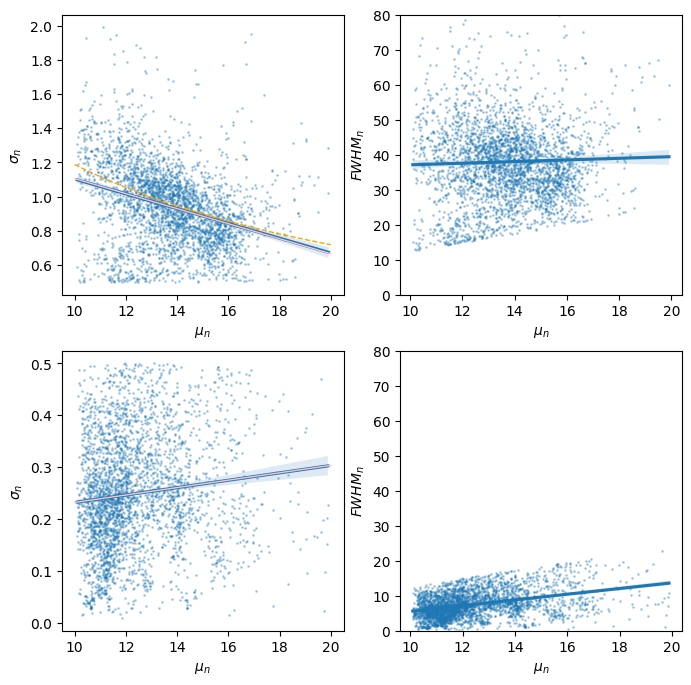

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

ind = (dfest14.mu.narrow>=10.1) & (dfest14.mu.narrow<=20) & (dfest14.sd.narrow<=2) & (dfest14.sd.narrow>=.5)
ax = axs[0,0]
sns.regplot(x=dfest14.mu.narrow[ind], y=dfest14.sd.narrow[ind], scatter_kws={'s':1, 'alpha':.3}, ax=ax)
ax.set_xlabel('$\mu_n$'); ax.set_ylabel('$\sigma_n$')
res = odr_1dregression(dfest14[ind].mu.narrow, dfest14[ind].sd.narrow); print(res.beta)
ax.plot( [10,20], odr_pred(res, [10,20]), color='pink', linestyle='-', lw=1)
xxx = np.linspace(10, 20, 100)
ax.plot(xxx, np.arcsinh(38/(2*xxx))/np.sqrt(2*np.log(2)), color='orange', linestyle='--', lw=1) # sigma if fwhm is constant
ax = axs[0,1]
fwhms = 2 * dfest14.mu.narrow[ind] * np.sinh( dfest14.sd.narrow[ind] * np.sqrt(2 * np.log(2)) )
sns.regplot(x=dfest14.mu.narrow[ind], y=fwhms, scatter_kws={'s':1, 'alpha':.3}, ax=ax)
ax.set_xlabel('$\mu_n$'); ax.set_ylabel('$FWHM_n$')
# res = odr_1dregression(dfest14[ind].mu.narrow, fwhms); print(res.beta); res.pprint()
# ax.plot( [10,20], odr_pred(res, [10,20]), color='pink', linestyle='-', lw=1)
ax.set_ylim(0,80)


ax = axs[1,0]
ind = (dfest14.mu.narrow>=10.1) & (dfest14.mu.narrow<=20) & (dfest14.sd.narrow<=.5)
sns.regplot(x=dfest14.mu.narrow[ind], y=dfest14.sd.narrow[ind], scatter_kws={'s':1, 'alpha':.3}, ax=ax)
ax.set_xlabel('$\mu_n$'); ax.set_ylabel('$\sigma_n$')
res = odr_1dregression(dfest14[ind].mu.narrow, dfest14[ind].sd.narrow); print(res.beta)
ax.plot( [10,20], odr_pred(res, [10,20]), color='pink', linestyle='-', lw=1)
# xxx = np.linspace(10, 20, 100)
# ax.plot(xxx, np.arcsinh(38/(2*xxx))/np.sqrt(2*np.log(2)), color='orange', linestyle='--', lw=1)
ax = axs[1,1]
fwhms = 2 * dfest14.mu.narrow[ind] * np.sinh( dfest14.sd.narrow[ind] * np.sqrt(2 * np.log(2)) )
sns.regplot(x=dfest14.mu.narrow[ind], y=fwhms, scatter_kws={'s':1, 'alpha':.3}, ax=ax)
ax.set_xlabel('$\mu_n$'); ax.set_ylabel('$FWHM_n$')
ax.set_ylim(0,80)

In [264]:
np.arcsinh(5.) / np.sqrt(2*np.log(2))

1.9640042950648147

# Model 15 (r_sd)

In [179]:
# Model 15 is better
# print(rez[14].mean(), rez[15].mean())
# print( pg.ttest(x=rez[14], y=rez[15], paired=True) )
# Model 15 is better than 14
print(rez_est[14].mean(), rez_est[15].mean())
pg.ttest(x=rez_est[14], y=rez_est[15], paired=True)
# Model 15 is better than 4
print(rez_est[4].mean(), rez_est[15].mean())
pg.ttest(x=rez_est[4], y=rez_est[15], paired=True)

0.2859119711697223 0.3155111920740877
0.30132535593290977 0.3155111920740877


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-2.653206,38,two-sided,0.011574,"[-0.03, -0.0]",0.080935,3.633,0.078252


In [180]:
dfest15 = index_filter(pars, type='estimates', smoothed=True, model_label=15)
dfest15 = dfest15[ dfest15[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
dfest15.index.rename(['subject', 'voxel'], inplace=True)
dfest15[('sd','ratio_wn')] = dfest15.sd.wide / dfest15.sd.narrow
dfest15

dfgt15 = index_filter(pars, type='ground_truth', smoothed=True, model_label=15)
dfgt15 = dfgt15[ dfgt15[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
dfgt15.index.rename(['subject', 'voxel'], inplace=True)
dfgt15[('sd','ratio_wn')] = dfgt15.sd.wide / dfgt15.sd.narrow
dfgt15

parameter             mu                   sd           delta_wide      amplitude            baseline                  r2      cvr2        sd
range             narrow       wide    narrow      wide     narrow wide    narrow      wide    narrow      wide       nan       nan  ratio_wn
subject voxel                                                                                                                                
1       10     11.706925  13.413851  0.114662  0.150516        2.0  2.0  0.698721  0.698721 -0.462405 -0.462405  0.044681  0.018702  1.312699
        13     11.599907  13.199814  0.116986  0.153567        2.0  2.0  0.659813  0.659813 -0.359337 -0.359337  0.049357  0.021686  1.312699
        14     11.700312  13.400623  0.103045  0.135268        2.0  2.0  0.601583  0.601583 -0.616483 -0.616483  0.035233  0.002891  1.312699
        16     11.356297  12.712593  0.127587  0.167484        2.0  2.0  0.464056  0.464056 -0.285340 -0.285340  0.036573  0.014237  1.312699
        17     11.470483  12.940966  0.106346  0.139600        2.0  2.0  0.579976  0.579976 -0.430054 -0.430054  0.045050  0.011577  1.312699
...                  ...        ...       ...       ...        ...  ...       ...       ...       ...       ...       ...       ...       ...
41      687    10.001306  10.002611  0.406871  0.560031        2.0  2.0  0.316199  0.316199 -0.112485 -0.112485  0.026977  0.007772  1.376434
        688    13.352640  16.705280  0.827879  1.139521        2.0  2.0  0.732903  0.732903 -0.568818 -0.568818  0.017233  0.010196  1.376433
        689    11.856775  13.713551  0.969636  1.334640        2.0  2.0  0.803345  0.803345 -0.389811 -0.389811  0.024026  0.010816  1.376433
        691    12.157406  14.314812  0.884795  1.217861        2.0  2.0  0.785061  0.785061 -0.468486 -0.468486  0.026154  0.015875  1.376433
        693    11.992874  13.985748  0.986476  1.357819        2.0  2.0  0.729405  0.729405 -0.585881 -0.585881  0.012501  0.004123  1.376434

[8785 rows x 13 columns]

In [181]:
rez_est.loc[:,[14,15]].mean()

model_label
14    0.285912
15    0.315511
dtype: float64

In [ ]:
print( dfest15[('sd', 'ratio_wn')].groupby('subject').first().mean(), dfest15[('sd', 'ratio_wn')].groupby('subject').first().std() )
print( dfest15[('sd', 'ratio_wn')].groupby('subject').first().median() )
print( dfgt15 [('sd', 'ratio_wn')].groupby('subject').first().mean(), dfgt15 [('sd', 'ratio_wn')].groupby('subject').first().std() )
print( dfgt15 [('sd', 'ratio_wn')].groupby('subject').first().median() )
np.sqrt(2)

1.304754457830862 0.24664963098064527
1.321174469451246
1.2877944588717374
1.309339674301479


1.4142135623730951

In [ ]:
# test if the mean is significantly different from 1
print( stats.ttest_1samp(dfest15[('sd', 'ratio_wn')].groupby('subject').first(), 1) )
#print( pg.ttest(x=dfest15[('sd', 'ratio_wn')].groupby('subject').first(), y=1) )
print( stats.ttest_1samp(dfgt15[('sd', 'ratio_wn')].groupby('subject').first(), 1) )

TtestResult(statistic=7.716172011244838, pvalue=2.6987830478430184e-09, df=38)
               T  dof alternative         p-val         CI95%   cohen-d       BF10  power
T-test  7.716172   38   two-sided  2.698783e-09  [1.22, 1.38]  1.235576  4.443e+06    1.0
TtestResult(statistic=7.2300299295274275, pvalue=1.2036774014055539e-08, df=38)


In [184]:
# test if the mean is significantly different from sqrt(2)
print( stats.ttest_1samp(dfest15[('sd', 'ratio_wn')].groupby('subject').first(), np.sqrt(2) ) )
print( stats.ttest_1samp(dfgt15[('sd', 'ratio_wn')].groupby('subject').first(), np.sqrt(2) ) )
# ratio_wn_gt15 = dfgt15[('sd', 'ratio_wn')].groupby('subject').first()
# ratio_wn_est15 = dfest15[('sd', 'ratio_wn')].groupby('subject').first()
# Using bootstrap to test if the median is significantly different from sqrt(2) ?

TtestResult(statistic=-2.77142879174373, pvalue=0.008593168432867927, df=38)
TtestResult(statistic=-3.1759259909385356, pvalue=0.002961285029114354, df=38)


In [185]:
# test if the mean is significantly different from 2
print( stats.ttest_1samp(dfest15[('sd', 'ratio_wn')].groupby('subject').first(), 2) )
print( stats.ttest_1samp(dfgt15[('sd', 'ratio_wn')].groupby('subject').first(), 2) )

TtestResult(statistic=-17.60313608408512, pvalue=7.276866362959838e-20, df=38)
TtestResult(statistic=-17.892169983118098, pvalue=4.182052724464494e-20, df=38)


TtestResult(statistic=7.716172011244838, pvalue=2.6987830478430184e-09, df=38)


Text(0.5, 1.0, 'Sd ratio_wn parameter (Model 15)')

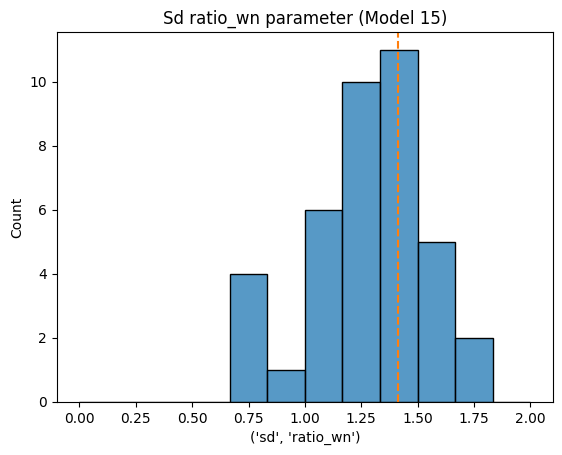

In [186]:
sns.histplot( dfgt15[('sd','ratio_wn')].groupby('subject').first(), bins=np.linspace(0,2,13))
plt.axvline(np.sqrt(2), ls='--', color='C1')
print( stats.ttest_1samp( dfest15[('sd','ratio_wn')].groupby('subject').first(), popmean=1) )
#stats.ttest_1samp( dfest15[('sd','ratio_wn')].groupby('subject').first(), popmean=np.sqrt(2))
plt.title('Sd ratio_wn parameter (Model 15)')

In [187]:
print( dfest15.sd.ratio_wn.groupby('subject').first().mean(), dfgt15.sd.ratio_wn.groupby('subject').first().mean() )
print( dfest15.sd.ratio_wn.groupby('subject').first().median(), dfgt15.sd.ratio_wn.groupby('subject').first().median() )

1.304754457830862 1.2877944588717374
1.321174469451246 1.309339674301479


1.304754457830862


count    39.000000
mean      1.304754
std       0.246650
min       0.808450
25%       1.177294
50%       1.321174
75%       1.406219
max       2.245313
Name: ratio_wn, dtype: float64

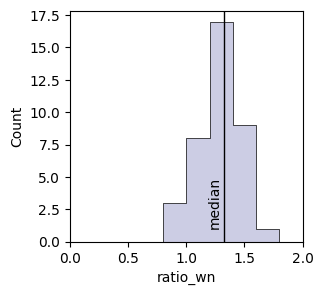

In [188]:
fig, ax = plt.subplots(figsize=(3, 3))
ratio_sd = dfest15.sd.ratio_wn.groupby('subject').first()
print(ratio_sd.mean())
dw = .2
bins = np.arange(-dw, ratio_sd.max()+dw, dw)
this_color = 1 - .4*( 1 -  np.array( plt.cm.Spectral_r(.02)[:3] ) ) # equivalent to the color with some alpha, on white. (With cB = 1 - alpha*(1-cA), color cB is like (cA,alpha) on white.)
sns.histplot(ratio_sd, ax=ax, bins=bins, color=this_color, linewidth=.5, element='step', ec='k') # bins=bins, 
ax.set_xlim(0,2)
ax.axvline(ratio_sd.median(), color='k', linestyle='-', lw=1)
ax.text(ratio_sd.median()-.02, 3, 'median', rotation=90, va='center', ha='right')
ratio_sd.describe()

0.2259190798932019% of the data not shown in the figure (σ>3)


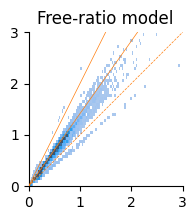

In [189]:
fig, ax = plt.subplots(figsize=(2, 2))
ax.set_aspect('equal') #, adjustable='box')
nmax = 40
this_df = dfest15
ind = this_df == this_df # true everywhere (except nans but idc)
#ind = (this_df.mu.narrow>=0) & (this_df.mu.wide>=0) & (this_df.mu.narrow<=nmax) & (this_df.mu.wide<=nmax)
#sns.displot(this_df[ind].sd, x='narrow', y='wide', kind='hist', bins=41)
sns.histplot(this_df[ind].sd, x='narrow', y='wide', bins=161, ax=ax, pmax=.6, alpha=1)
#sns.scatterplot(this_df[ind].sd, x='narrow', y='wide', color='C0', s=1, ax=ax, alpha=1, ec='none')
#sns.displot(this_df[ind].sd, x='narrow', y='wide', kind='kde', bins=41, ax=ax)
#sns.kdeplot(this_df[ind].sd, x='narrow', y='wide', ax=ax, levels=5, color='lightgrey', thresh=.1, linewidth=1, zorder=-1000)
σmax = 3
print( f'{( (this_df[ind].sd.narrow > σmax) | (this_df[ind].sd.wide > σmax) ).mean()*100}% of the data not shown in the figure (σ>{σmax})' )
ax.set_xlim(0,σmax); ax.set_ylim(0,σmax)
ax.axline((0,0), slope=1, color='C1', ls='--', lw=.5, zorder=100)
ax.plot([0, σmax], [0, 2*σmax], c='C1', lw=.5, zorder=100)
ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c='C1', lw=.5, zorder=100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.set_title('Free-ratio model')
ax.set_yticks([0, 1, 2, 3])
ax.set_xticks([0, 1, 2, 3]);
#ax.get_xticklabels()[-1].set_ha('right')
#ax.text(38, 38+1, 'No shift', fontsize=10, ha='right', va='top', rotation=45)
#ax.text(24, 38+1, 'Efficient shift', fontsize=10, ha='right', va='top', rotation=63.43)
#ax.grid()
#fig.savefig('figures/sd_wide_vs_narrow_freeratio.pdf', bbox_inches='tight')

# Figure - widths

In [79]:
mean_ratio_sd = dfest15.sd.ratio_wn.groupby('subject').first().mean()
mean_ratio_sd

1.304754457830862

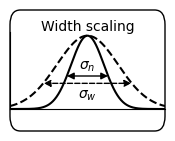

In [164]:
##### Icon
icon_width = 0.2; icon_height = .08
fig, icon_ax = plt.subplots(figsize=(2,1))
#inset_ax = fig.add_axes([inset_width/2, 0.8, inset_width, inset_width], )
xxs = np.linspace(0, 3, 1000)
icon_ax.plot(xxs, np.exp(-(xxs-1.5)**2/.2), color='k') 
icon_ax.plot(xxs, np.exp(-(xxs-1.5)**2/.7), color='k', linestyle='--')
#icon_ax.arrow(x=1, y=0.35, dx=1, dy=0, color='k', lw=1, head_width=0.1, head_length=0.1, length_includes_head=True, zorder=100, )
icon_ax.annotate("", xytext=(1.05, .45), xy=(1.95, .45), arrowprops=dict(arrowstyle="<|-|>", color='k'))
icon_ax.annotate("", xytext=(.6, .35), xy=(2.4, .35), arrowprops=dict(arrowstyle="<|-|>", ls='--', color='k'))
icon_ax.set_ylim(0, None)
icon_ax.set_xlim(0, 3)
icon_ax.set_yticks([])
icon_ax.set_xticks([])
#icon_ax.set_xticklabels(['$\sigma_n$', '$\sigma_w$'])
icon_ax.text(1.5, .475, '$\sigma_n$', fontsize=10, ha='center', va='bottom')
icon_ax.text(1.5, .275, '$\sigma_w$', fontsize=10, ha='center', va='top')
icon_ax.tick_params(axis='x', length=0, pad=0.5, labelsize=10)
bb = mtransforms.Bbox([[0., -.3], [3, 1.35]])
fancy = FancyBboxPatch(bb.p0, bb.width, bb.height, clip_on=False, facecolor="w", boxstyle="round,pad=0,rounding_size=0.2") # zorder=1000000)
icon_ax.add_patch(fancy)
icon_ax.set_title('Width scaling', fontsize=10, y=.9, ha='center')
sns.despine(ax=icon_ax)
fig.savefig('figures/icon_width_scaling.pdf', bbox_inches='tight')

In [81]:
ratio_sd.mean(), ratio_sd.median()

(1.304754457830862, 1.321174469451246)

3.78588441770089% of the data not shown in the figure (σ>3)
31 subjects have median $\sigma$ in Wide condition larger than in Narrow condition
8 subjects have median $\sigma$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -4.878, p = 1.94e-05, dof = 38
19.46847185658769 % of voxels have $\sigma_{w} - \sigma_{n} < 0$
1.2877944588717374


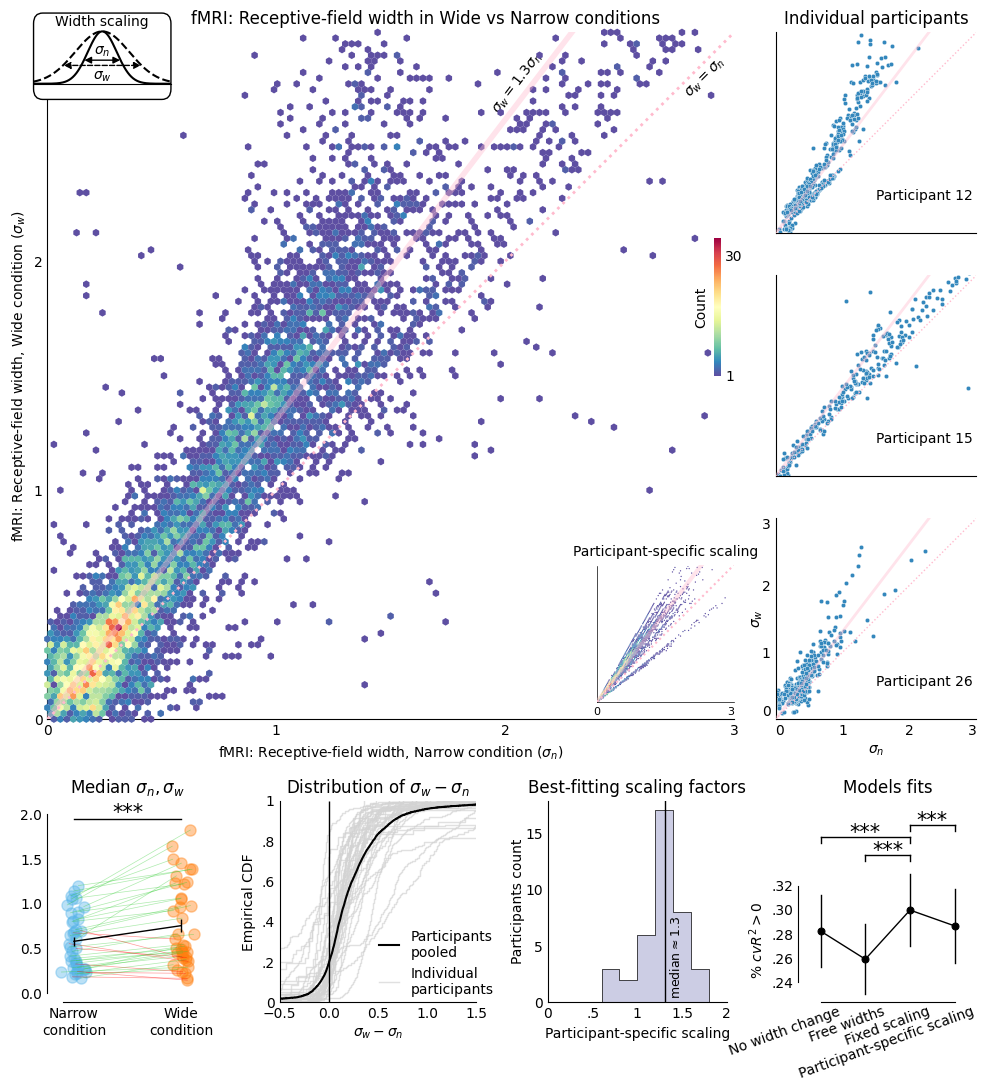

In [342]:
nrows = 4
WITH_GROUND_TRUTH = True
this_df14 = dfgt14 if WITH_GROUND_TRUTH else dfest14
this_df15 = dfgt15 if WITH_GROUND_TRUTH else dfest15
#fig = plt.figure(figsize=(12, nrows*3))
gs = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2))
#fig, axs = plt.subplots(nrows=nrows, ncols=4, figsize=(12, nrows*3), height_ratios=(1,1,1,1.2))
fig = plt.figure(figsize=(12, (nrows+.2)*3))
#ax = fig.add_subplot(nrows,4,(1,11))
ax = fig.add_subplot(gs[:3, :3])
ax.set_aspect('equal') #, adjustable='box')

cmap = plt.cm.Spectral_r #RdYlBu_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', 
SDSD_COLOR = cmap(.1) # THIRD_COLOR
LINE_COLOR = 'xkcd:pastel pink' #'C1' 

σmax = 3
ind = (this_df14.sd.narrow <= σmax) & (this_df14.sd.wide <= σmax)
#sns.histplot(dfest14[ind].sd, x='narrow', y='wide', bins=801, ax=ax, pmax=.6, alpha=1, color=SDSD_COLOR)
#sns.kdeplot(dfest14[ind].sd, x='narrow', y='wide', ax=ax, levels=6, thresh=.5, fill=True, cmap='YlGnBu')
hb = ax.hexbin(this_df14[ind].sd.narrow, this_df14[ind].sd.wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=cmap, mincnt=1, edgecolors='none', clip_on=False, zorder=10)
#sns.scatterplot(dfest14[ind].sd, x='narrow', y='wide', ax=ax, color=SDSD_COLOR, s=1)
#sns.kdeplot(dfest14[ind].sd, x='narrow', y='wide', ax=ax, levels=8, thresh=.1, fill=False, cmap='YlGnBu_r')
#sns.regplot(dfest14[ind].sd, x='narrow', y='wide', ax=ax, scatter=False, line_kws={'color': LINE_COLOR, 'lw': .5}, lowess=True) # ci=None, 
print( f'{(~ind).mean()*100}% of the data not shown in the figure (σ>{σmax})' )
ax.set_xlim(0,σmax); ax.set_ylim(0,σmax)

# Colorbar
cbar_ax = ax.inset_axes([0.97, 0.5, .01, .2])
cb = fig.colorbar(hb, cax=cbar_ax, label='Count', ticks=[1, 30, 59], drawedges=False)
cb.ax.yaxis.set_label_position('left')
#cb.ax.yaxis.tick_left()
cbar_ax.tick_params(axis='both', length=0)
cb.outline.set_visible(False)


ax.tick_params(axis='both', length=0)

median_ratio_sd = this_df15.sd.ratio_wn.groupby('subject').first().median()

ax.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=2, zorder=100)
ax.plot([0, σmax], [0, median_ratio_sd*σmax], c=LINE_COLOR, lw=4, alpha=.4, zorder=100)
#ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c=LINE_COLOR, lw=.5, zorder=100)

ax.set_xlabel('fMRI: Receptive-field width, Narrow condition ($\sigma_n$)')
ax.set_ylabel('fMRI: Receptive-field width, Wide condition ($\sigma_w$)')
ax.set_title('fMRI: Receptive-field width in Wide vs Narrow conditions', x=.55, y=1)

ax.text(2.975, 2.8+.1, '$\sigma_w=\sigma_n$', fontsize=10, ha='right', va='top', rotation=45) # Same width
ax.text(2.18 , 2.18*median_ratio_sd+.07, f'$\sigma_w={median_ratio_sd:.1f}\sigma_n$', fontsize=10, ha='right', va='top',
        rotation=np.arctan(median_ratio_sd)*180/np.pi,) # backgroundcolor='w', zorder=100)
#ax.text(2., 2.*np.sqrt(2)+.1, 'Width $\\times\sqrt{2}$', fontsize=10, ha='right', va='top', rotation=54.74)
ax.set_yticks([0, 1, 2, 3])
ax.set_xticks([0, 1, 2, 3]);


##### Icon
icon_width = 0.2; icon_height = .08
icon_ax = ax.inset_axes([-.02, 0.925, icon_width, icon_height], zorder=1000)
#inset_ax = fig.add_axes([inset_width/2, 0.8, inset_width, inset_width], )
xxs = np.linspace(0, 3, 1000)
icon_ax.plot(xxs, np.exp(-(xxs-1.5)**2/.2), color='k') 
icon_ax.plot(xxs, np.exp(-(xxs-1.5)**2/.7), color='k', linestyle='--')
#icon_ax.arrow(x=1, y=0.35, dx=1, dy=0, color='k', lw=1, head_width=0.1, head_length=0.1, length_includes_head=True, zorder=100, )
icon_ax.annotate("", xytext=(1.05, .45), xy=(1.95, .45), arrowprops=dict(arrowstyle="<|-|>", color='k'))
icon_ax.annotate("", xytext=(.6, .35), xy=(2.4, .35), arrowprops=dict(arrowstyle="<|-|>", ls='--', color='k'))
icon_ax.set_ylim(0, None)
icon_ax.set_xlim(0, 3)
icon_ax.set_yticks([])
icon_ax.set_xticks([])
#icon_ax.set_xticklabels(['$\sigma_n$', '$\sigma_w$'])
icon_ax.text(1.5, .475, '$\sigma_n$', fontsize=10, ha='center', va='bottom')
icon_ax.text(1.5, .275, '$\sigma_w$', fontsize=10, ha='center', va='top')
icon_ax.tick_params(axis='x', length=0, pad=0.5, labelsize=10)
bb = mtransforms.Bbox([[0., -.3], [3, 1.35]])
fancy = FancyBboxPatch(bb.p0, bb.width, bb.height, clip_on=False, facecolor="w", boxstyle="round,pad=0,rounding_size=0.2") # zorder=1000000)
icon_ax.add_patch(fancy)
icon_ax.set_title('Width scaling', fontsize=10, y=.9, ha='center')
sns.despine(ax=icon_ax)


if True:
    inset_width = 0.2
    #### Inset KDE
    # # inset_ax = ax.inset_axes([0.8, 0.3, inset_width, inset_width], aspect='equal') 
    # # inset_ax = ax.inset_axes([0.025, 0.79, inset_width, inset_width], aspect='equal') 
    # inset_ax = ax.inset_axes([0.575, 0.025, inset_width, inset_width], aspect='equal') 
    # sns.kdeplot(dfest14[ind].sd, x='narrow', y='wide', ax=inset_ax, levels=6, cmap=cmap, thresh=.15, linewidths=.8)
    # inset_ax.set_xlim(0,3); inset_ax.set_ylim(0,3)
    # inset_ax.axline((0,0), slope=1, color=LINE_COLOR, ls='--', lw=.5, zorder=100)
    # inset_ax.plot([0, σmax], [0, mean_ratio_sd*σmax], c=LINE_COLOR, lw=.5, zorder=100)
    # #inset_ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c=LINE_COLOR, lw=.5, zorder=100)
    # inset_ax.spines['top'].set_visible(False); inset_ax.spines['right'].set_visible(False)
    # inset_ax.spines['left'].set_linewidth(0.5); inset_ax.spines['bottom'].set_linewidth(0.5)
    # inset_ax.set_xlabel(None); inset_ax.set_ylabel(None)
    # #inset_ax.set_title('KDE', fontsize=8)
    # inset_ax.set_xticks([0,3]); inset_ax.set_yticks([0, 3]); inset_ax.set_yticklabels([None,None]); #inset_ax.set_xticklabels([None,None]); 
    # inset_ax.tick_params(axis='both', labelsize=8, length=0)
    # inset_ax.get_xticklabels()[-1].set_ha('right')

    ### Inset Model 15
    inset_ax2 = ax.inset_axes([0.8, 0.025, inset_width, inset_width], aspect='equal')
    ind = (this_df15.sd.narrow<=σmax) & (this_df15.sd.wide<=σmax)
    this_cmap = plt.cm.Spectral_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', # plt.cm.RdYlBu #
    #sns.histplot(dfest15[ind].sd, x='narrow', y='wide', bins=161, ax=inset_ax2, pmax=.8, alpha=1, color=THIRD_COLOR)
    inset_ax2.hexbin(this_df15[ind].sd.narrow, this_df15[ind].sd.wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=this_cmap, mincnt=1, edgecolors='none')
    inset_ax2.set_xlim(0,3); inset_ax2.set_ylim(0,3)
    inset_ax2.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=1.5, zorder=100)
    inset_ax2.plot([0, σmax], [0, median_ratio_sd*σmax], c=LINE_COLOR, lw=3, alpha=.4, zorder=100)
    #inset_ax2.plot([0, σmax], [0, np.sqrt(2)*σmax], c=LINE_COLOR, lw=.5, zorder=100)
    inset_ax2.spines['top'].set_visible(False); inset_ax2.spines['right'].set_visible(False)
    inset_ax2.spines['left'].set_linewidth(0.5); inset_ax2.spines['bottom'].set_linewidth(0.5)
    inset_ax2.set_xlabel(None); inset_ax2.set_ylabel(None)
    #inset_ax2.set_title('Free-slope model', fontsize=8)
    inset_ax2.set_xticks([0,3]); inset_ax2.set_yticks([0,3]); inset_ax2.set_yticklabels([None,None]);
    inset_ax2.tick_params(axis='both', labelsize=8, length=0)
    inset_ax2.get_xticklabels()[-1].set_ha('right')
    inset_ax2.set_title('Participant-specific scaling', fontsize=10, backgroundcolor='w')

###### Individual subjects
select_subjs = [12,15,26]
axS1 = fig.add_subplot(gs[0, 3]) # fig.add_subplot(nrows,4,4)
sns.scatterplot(data=index_filter(this_df14, subject=12).sd, x='narrow', y='wide', color=SDSD_COLOR, s=10, alpha=1, ax=axS1)
axS2 = fig.add_subplot(gs[1, 3]) # fig.add_subplot(nrows,4,8)
sns.scatterplot(data=index_filter(this_df14, subject=15).sd, x='narrow', y='wide', color=SDSD_COLOR, s=10, alpha=1, ax=axS2)
axS3 = fig.add_subplot(gs[2, 3]) # fig.add_subplot(nrows,4,12)
sns.scatterplot(data=index_filter(this_df14, subject=26).sd, x='narrow', y='wide', color=SDSD_COLOR, s=10, alpha=1, ax=axS3)
for ii,ax in enumerate([axS1, axS2, axS3]):
    ax.set_aspect('equal')
    ax.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=1, zorder=100)
    ax.plot([0, σmax], [0, median_ratio_sd*σmax], c=LINE_COLOR, lw=2, alpha=.4, zorder=100)
    #ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c=LINE_COLOR, lw=.5, zorder=100)
    ax.set_xlim(0, 3); ax.set_ylim(0, 3)
    ax.set_xlabel(None); ax.set_ylabel(None)
    ax.set_xticks([]); ax.set_yticks([])
    #ax.set_title(f'Subject {select_subjs[ii]}', x=.6, y=.1, fontsize=10)
    ax.text(1.5, .5, f'Participant {select_subjs[ii]}', fontsize=10)
axS1.set_title('Individual participants')
axS3.set_xticks([0,1,2,3]); axS3.set_yticks([0,1,2,3]);
#ax.set_xticklabels([]); ax.set_yticklabels([]);
axS3.tick_params(axis='both', length=0) # labelsize=8, 
axS3.get_xticklabels()[0].set_ha('left'); axS3.get_xticklabels()[-1].set_ha('right')
axS3.get_yticklabels()[-1].set_va('top'); axS3.get_yticklabels()[0].set_va('bottom')
axS3.set_xlabel('$\sigma_n$')
axS3.set_ylabel('$\sigma_w$', labelpad=-2,) # y=.45)

######## Bottom row
gs2 = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2), hspace=.5, width_ratios=(.9,1.1,1,1), wspace=.4)

######## Median preferred numerosities
ax = fig.add_subplot(gs2[3,0])

sd_wide_medians = this_df14[('sd', 'wide')].groupby('subject').median()
sd_narrow_medians = this_df14[('sd', 'narrow')].groupby('subject').median()
print( (sd_wide_medians >= sd_narrow_medians).sum(), 'subjects have median $\sigma$ in Wide condition larger than in Narrow condition' )
print( (sd_wide_medians <  sd_narrow_medians).sum(), 'subjects have median $\sigma$ in Wide condition smaller than in Narrow condition' )
paired_strip_plot(ax, x1=1, x2=2, y1=sd_narrow_medians, y2=sd_wide_medians, 
                  col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='limegreen', color_decr_line='r',)
ax.errorbar([1, 2], [sd_narrow_medians.mean(), sd_wide_medians.mean()], yerr=[sd_narrow_medians.sem(), sd_wide_medians.sem()], color='k', lw=1) 
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_title("Median $\sigma_n, \sigma_w$")
ax.set_xlim(0.75, 2.25)
ax.set_ylim(-.1,2.15 if WITH_GROUND_TRUTH else 1.75)
# paired test
paired_test = pg.ttest(sd_narrow_medians, sd_wide_medians, paired=True)
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
#ax.hlines(0.94*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
#ax.text(1.5, 0.95*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')
star_line(ax, 1, 2, 1.95 if WITH_GROUND_TRUTH else 1.55, paired_test['p-val'].iloc[0], star_size=15, star_offset=-.05, vertical_lines_length=0.)
ax.tick_params(axis='both', length=0)
ax.spines.left.set_bounds((0, 2. if WITH_GROUND_TRUTH else 1.55))
ax.spines.bottom.set_bounds((.9, 2.1))
ax.set_yticks([0, .5, 1, 1.5, 2.]) if WITH_GROUND_TRUTH else ax.set_yticks([0, .5, 1, 1.5])


######## CDF of change in preferred numerosity

ax = fig.add_subplot(gs2[3,1])
all_data = []
subjects = this_df14.index.get_level_values('subject').unique()
for subject in subjects:
    data = this_df14.xs(subject, level='subject')[('sd', 'delta_wn')]
    all_data.append(pd.DataFrame({'sd_delta_wn': data.dropna(), 'subject': subject}))
all_data = pd.concat(all_data, ignore_index=True)
# Plot the CDFs for each subject in light grey (no hue, loop over subjects)
c_ind = 'lightgrey'
for subject in subjects:
    subj_data = all_data[all_data['subject'] == subject]
    sns.ecdfplot(data=subj_data, x='sd_delta_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False, ax=ax)
# Plot the pooled CDF (all subjects together) in a bold color
this_color = 'k'; this_lw = 1.5
sns.ecdfplot(data=all_data, x='sd_delta_wn', color=this_color, linewidth=this_lw, label='Participants pooled', ax=ax)
print( (all_data.sd_delta_wn<0).mean() * 100, '% of voxels have $\sigma_{w} - \sigma_{n} < 0$' )
ax.set_title("Distribution of $\sigma_{w} - \sigma_{n}$")
#ax.set_title("Change in preferred numerosity")
ax.set_xlabel('$\sigma_{w} - \sigma_{n}$')
ax.set_ylabel('Empirical CDF')
ax.legend(handles=[plt.Line2D([0], [0], color=this_color, lw=this_lw, label='Participants\npooled'),
                    plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nparticipants')],
                    loc=(.475,0), handlelength=1.5, frameon=False)
ax.set_xlim(-.5, 1.5)
ax.vlines(0, 0, 1, color='black', linestyle='-', lw=1)
ax.set_yticks([0, .2, .4, .6, .8, 1])
ax.set_yticklabels(['0', '.2', '.4', '.6', '.8', '1'])
ax.tick_params(axis='both', length=0)



########### Distribution ratio_sd
ax = fig.add_subplot(gs2[3,2])
ratio_sd = this_df15.sd.ratio_wn.groupby('subject').first()
print(ratio_sd.mean())
dw = .2
bins = np.arange(-dw, ratio_sd.max()+dw, dw)
this_color = 1 - .4*( 1 -  np.array( plt.cm.Spectral_r(.02)[:3] ) ) # equivalent to the color with some alpha, on white. (With cB = 1 - alpha*(1-cA), color cB is like (cA,alpha) on white.)
sns.histplot(ratio_sd, ax=ax, bins=bins, color=this_color, linewidth=.5, element='step', ec='k') # bins=bins, 
ax.set_xlim(0,2)
ax.axvline(ratio_sd.median(), color='k', linestyle='-', lw=1)
ax.text(ratio_sd.median()+ (.2 if WITH_GROUND_TRUTH else -.02), 4., f'median$\\approx${ratio_sd.median():.1f}', rotation=90, va='center', ha='right', fontsize=9)
ax.set_title("Best-fitting scaling factors")
ax.set_xlabel('Participant-specific scaling')
ax.set_yticks([0, 5, 10, 15])
ax.set_xticks([0, .5, 1, 1.5, 2])
ax.set_xticklabels(['0', '.5', '1', '1.5', '2'])
ax.set_ylabel('Participants count', labelpad=0)
ax.tick_params(axis='both', length=0)


########## Proportion cvR2>0
ax = fig.add_subplot(gs2[3,3])
####
modelz = dict( [(4, 'No width change'), (14, 'Free widths'), (31, 'Fixed scaling'), (15, 'Participant-specific scaling')] ) # 
these_rez = (rez if WITH_GROUND_TRUTH else rez_est).loc[:,list(modelz.keys())].rename(columns=modelz)
these_rez
#sns.stripplot(these_rez, color=FOURTH_COLOR) 
sns.pointplot(these_rez, errorbar='se', color='k', markersize=5, linewidth=1, ax=ax)
ax.set_xlabel(None)
#### x ticks labels positions
ax.tick_params(axis='both', length=0)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor")
# Create offset transform
dx = 12./72.; dy = 2/72. 
offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
ax.set_xlim(-.5,3.5)
#### y 
ax.set_yticks([.24, .26, .28, .3, .32,]) if WITH_GROUND_TRUTH else ax.set_yticks([.26, .28, .3, .32, .34])
ax.set_yticklabels(['.24', '.26', '.28', '.30', '.32']) if WITH_GROUND_TRUTH else ax.set_yticklabels(['.26', '.28', '.30', '.32', '.34'])
ax.set_ylabel('% $cvR^2 > 0$', y=.5, ha='right')
ax.spines.left.set_bounds((.24, .32)) if WITH_GROUND_TRUTH else ax.spines.left.set_bounds((.26, .34))
ax.spines.bottom.set_bounds((0, 3))
sns.despine(fig)
# (0,4), (3,4), (5,4) 
vll = 0.005
star_size = 15
star_offset = -.005
star_line(ax, 0, 2, .36  if WITH_GROUND_TRUTH else .38,  compare_res_est.loc[(4,31)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
star_line(ax, 1, 2, .345 if WITH_GROUND_TRUTH else .365, compare_res_est.loc[(14,31)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
star_line(ax, 3, 2, .37  if WITH_GROUND_TRUTH else .39,  compare_res_est.loc[(15,31)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
ax.set_title('Models fits')
ax.set_ylim(None, .39 if WITH_GROUND_TRUTH else .41)

sns.despine(fig)
sns.despine(ax=icon_ax, left=True)

fig.savefig(f'figures/sd_wide_vs_narrow{"_gt" if WITH_GROUND_TRUTH else ""}.pdf', bbox_inches='tight')

0.045298963461501925

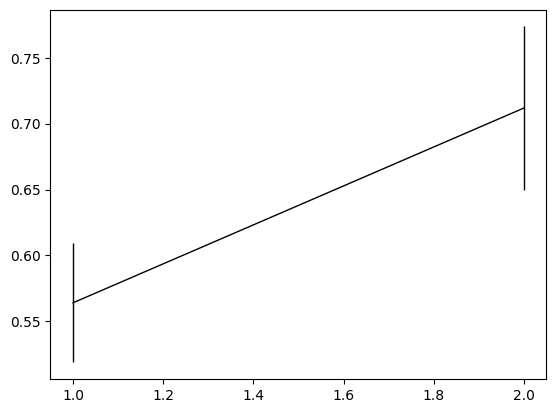

In [337]:
plt.errorbar([1,2], [sd_narrow_medians.mean(), sd_wide_medians.mean()], yerr=[sd_narrow_medians.sem(), sd_wide_medians.sem()], color='k', lw=1)
sd_narrow_medians.sem()

In [84]:
compare_res_est

Mean Model 1  Mean Model 2          T  dof alternative         p-val           CI95%   cohen-d       BF10     power
Model1 Model2                                                                                                                     
0      3           0.279088      0.259048   2.477756   38   two-sided  1.778123e-02     [0.0, 0.04]  0.117554      2.527  0.110432
       4           0.279088      0.301325  -3.633257   38   two-sided  8.242335e-04  [-0.03, -0.01]  0.127370     36.545  0.121224
       5           0.279088      0.291914  -1.995938   38   two-sided  5.314412e-02    [-0.03, 0.0]  0.072274      1.029  0.072464
       14          0.279088      0.285912  -0.890781   38   two-sided  3.786519e-01   [-0.02, 0.01]  0.039057       0.25  0.056503
       15          0.279088      0.315511  -4.386505   38   two-sided  8.829722e-05  [-0.05, -0.02]  0.207314    274.021  0.243261
       18          0.279088      0.305074  -3.370299   38   two-sided  1.734544e-03  [-0.04, -0.01]  0.147224      18.88  0.145890
       25          0.279088      0.321951  -4.867659   38   two-sided  2.005614e-05  [-0.06, -0.03]  0.243181   1063.669  0.316044
       31          0.279088      0.324579  -5.699292   38   two-sided  1.471962e-06  [-0.06, -0.03]  0.258680  1.192e+04  0.350217
       32          0.279088      0.305058  -3.057909   38   two-sided  4.069229e-03  [-0.04, -0.01]  0.148992      8.936  0.148271
       33          0.279088      0.319992  -5.289302   38   two-sided  5.360906e-06  [-0.06, -0.03]  0.233181   3592.227  0.294803
3      4           0.259048      0.301325  -8.258465   38   two-sided  5.234141e-10  [-0.05, -0.03]  0.248617  2.104e+07  0.327867
       5           0.259048      0.291914  -5.836502   38   two-sided  9.542291e-07  [-0.04, -0.02]  0.189978  1.785e+04  0.211787
       14          0.259048      0.285912  -5.647908   38   two-sided  1.731278e-06  [-0.04, -0.02]  0.157854  1.025e+04  0.160659
       15          0.259048      0.315511  -7.761179   38   two-sided  2.352568e-09  [-0.07, -0.04]  0.329843  5.059e+06  0.519065
       18          0.259048      0.305074  -8.871793   38   two-sided  8.522324e-11  [-0.06, -0.04]  0.267562  1.183e+08  0.370397
       25          0.259048      0.321951  -8.613689   38   two-sided  1.819421e-10  [-0.08, -0.05]  0.366214  5.746e+07  0.606043
       31          0.259048      0.324579 -10.325412   38   two-sided  1.391496e-12  [-0.08, -0.05]  0.382431   6.02e+09  0.643437
       32          0.259048      0.305058  -8.922875   38   two-sided  7.341546e-11  [-0.06, -0.04]  0.271033  1.363e+08  0.378390
       33          0.259048      0.319992 -10.277476   38   two-sided  1.586814e-12  [-0.07, -0.05]  0.356603  5.308e+09  0.583387
4      5           0.301325      0.291914   2.592253   38   two-sided  1.345899e-02     [0.0, 0.02]  0.053155      3.196  0.062084
       14          0.301325      0.285912   3.452399   38   two-sided  1.378281e-03    [0.01, 0.02]  0.088430     23.138  0.083816
       15          0.301325      0.315511  -2.653206   38   two-sided  1.157367e-02   [-0.03, -0.0]  0.080935      3.633  0.078252
       18          0.301325      0.305074  -0.801768   38   two-sided  4.276727e-01   [-0.01, 0.01]  0.021289      0.233  0.051927
       25          0.301325      0.321951  -3.456318   38   two-sided  1.363162e-03  [-0.03, -0.01]  0.117294     23.365  0.110160
       31          0.301325      0.324579  -5.058881   38   two-sided  1.104442e-05  [-0.03, -0.01]  0.132543   1842.339  0.127284
       32          0.301325      0.305058  -0.734171   38   two-sided  4.673506e-01   [-0.01, 0.01]  0.021464      0.222  0.051959
       33          0.301325      0.319992  -4.043654   38   two-sided  2.480289e-04  [-0.03, -0.01]  0.106666    107.399  0.099543
5      14          0.291914      0.285912   1.029888   38   two-sided  3.095736e-01   [-0.01, 0.02]  0.033876      0.282  0.054888
       15          0.291914      0.315511  -3.281312   38   two-sided  2.219578e-03  

## For pres

2.435708621275632% of the data not shown in the figure (σ>3)


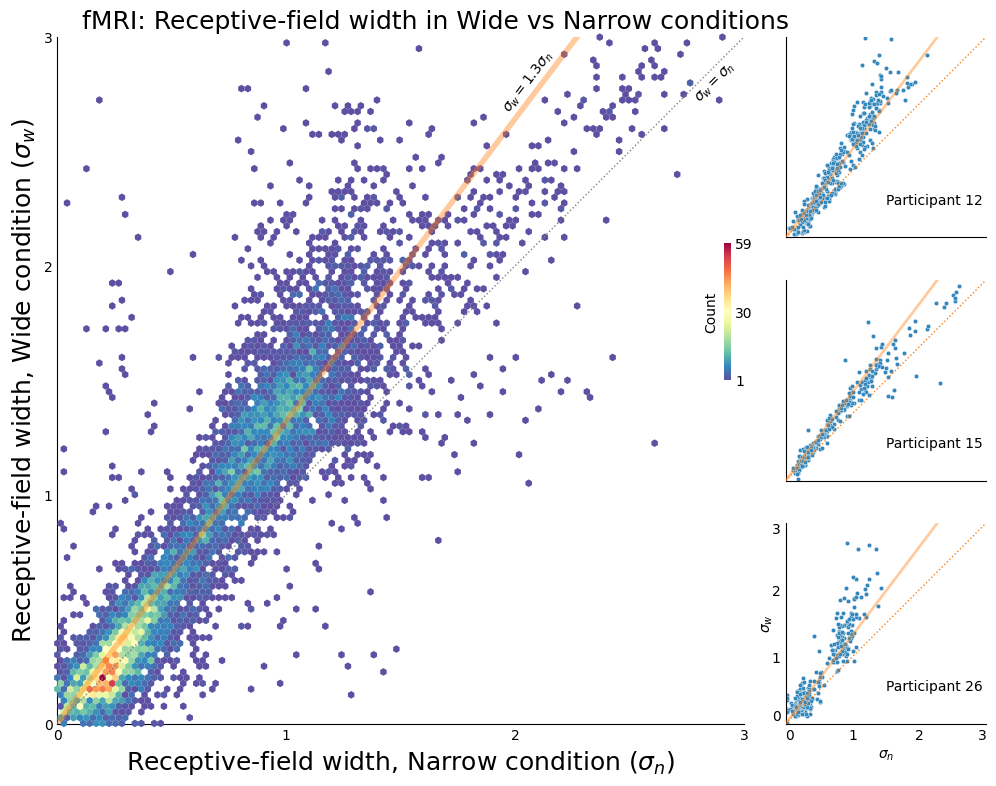

In [232]:
nrows = 4
#fig = plt.figure(figsize=(12, nrows*3))
gs = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2))
#fig, axs = plt.subplots(nrows=nrows, ncols=4, figsize=(12, nrows*3), height_ratios=(1,1,1,1.2))
fig = plt.figure(figsize=(12, (nrows+.2)*3))
#ax = fig.add_subplot(nrows,4,(1,11))
ax = fig.add_subplot(gs[:3, :3])
ax.set_aspect('equal') #, adjustable='box')

cmap = plt.cm.Spectral_r #RdYlBu_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', 
SDSD_COLOR = cmap(.1) # THIRD_COLOR
LINE_COLOR = 'C1' # 'xkcd:pastel pink' #'C1' 

σmax = 3
ind = (dfest14.sd.narrow <= σmax) & (dfest14.sd.wide <= σmax)
hb = ax.hexbin(dfest14[ind].sd.narrow, dfest14[ind].sd.wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=cmap, mincnt=1, edgecolors='none', clip_on=False, zorder=10)
print( f'{(~ind).mean()*100}% of the data not shown in the figure (σ>{σmax})' )

# Colorbar
cbar_ax = ax.inset_axes([0.97, 0.5, .01, .2])
cb = fig.colorbar(hb, cax=cbar_ax, label='Count', ticks=[1, 30, 59], drawedges=False)
cb.ax.yaxis.set_label_position('left')
#cb.ax.yaxis.tick_left()
cbar_ax.tick_params(axis='both', length=0)
cb.outline.set_visible(False)

ax.set_xlim(0,σmax); ax.set_ylim(0,σmax)
ax.tick_params(axis='both', length=0)

median_ratio_sd = dfest15.sd.ratio_wn.groupby('subject').first().median()

ax.axline((0,0), slope=1, color='grey', ls=':', lw=1, zorder=100)
ax.plot([0, σmax], [0, median_ratio_sd*σmax], c=LINE_COLOR, lw=4, alpha=.4, zorder=100)
#ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c=LINE_COLOR, lw=.5, zorder=100)

ax.set_xlabel('Receptive-field width, Narrow condition ($\sigma_n$)', fontsize=18)
ax.set_ylabel('Receptive-field width, Wide condition ($\sigma_w$)', fontsize=18)
ax.set_title('fMRI: Receptive-field width in Wide vs Narrow conditions', x=.55, y=1., fontsize=18)

ax.text(2.975, 2.8+.1, '$\sigma_w=\sigma_n$', fontsize=10, ha='right', va='top', rotation=45) # Same width
ax.text(2.18 , 2.18*median_ratio_sd+.07, f'$\sigma_w={median_ratio_sd:.1f}\sigma_n$', fontsize=10, ha='right', va='top',
        rotation=np.arctan(median_ratio_sd)*180/np.pi,) # backgroundcolor='w', zorder=100)
#ax.text(2., 2.*np.sqrt(2)+.1, 'Width $\\times\sqrt{2}$', fontsize=10, ha='right', va='top', rotation=54.74)
ax.set_yticks([0, 1, 2, 3])
ax.set_xticks([0, 1, 2, 3]);

###### Individual subjects
select_subjs = [12,15,26]
axS1 = fig.add_subplot(gs[0, 3]) # fig.add_subplot(nrows,4,4)
sns.scatterplot(data=index_filter(dfest14, subject=12).sd, x='narrow', y='wide', color=SDSD_COLOR, s=10, alpha=1, ax=axS1)
axS2 = fig.add_subplot(gs[1, 3]) # fig.add_subplot(nrows,4,8)
sns.scatterplot(data=index_filter(dfest14, subject=15).sd, x='narrow', y='wide', color=SDSD_COLOR, s=10, alpha=1, ax=axS2)
axS3 = fig.add_subplot(gs[2, 3]) # fig.add_subplot(nrows,4,12)
sns.scatterplot(data=index_filter(dfest14, subject=26).sd, x='narrow', y='wide', color=SDSD_COLOR, s=10, alpha=1, ax=axS3)
for ii,ax in enumerate([axS1, axS2, axS3]):
    ax.set_aspect('equal')
    ax.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=1, zorder=100)
    ax.plot([0, σmax], [0, median_ratio_sd*σmax], c=LINE_COLOR, lw=2, alpha=.4, zorder=100)
    #ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c=LINE_COLOR, lw=.5, zorder=100)
    ax.set_xlim(0, 3); ax.set_ylim(0, 3)
    ax.set_xlabel(None); ax.set_ylabel(None)
    ax.set_xticks([]); ax.set_yticks([])
    #ax.set_title(f'Subject {select_subjs[ii]}', x=.6, y=.1, fontsize=10)
    ax.text(1.5, .5, f'Participant {select_subjs[ii]}', fontsize=10)
#axS1.set_title('Individual participants')
axS3.set_xticks([0,1,2,3]); axS3.set_yticks([0,1,2,3]);
#ax.set_xticklabels([]); ax.set_yticklabels([]);
axS3.tick_params(axis='both', length=0) # labelsize=8, 
axS3.get_xticklabels()[0].set_ha('left'); axS3.get_xticklabels()[-1].set_ha('right')
axS3.get_yticklabels()[-1].set_va('top'); axS3.get_yticklabels()[0].set_va('bottom')
axS3.set_xlabel('$\sigma_n$')
axS3.set_ylabel('$\sigma_w$', labelpad=-2,) # y=.45)

######## Bottom row
gs2 = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2), hspace=.5, width_ratios=(.9,1.1,1,1), wspace=.4)

if False:
    ######## Median preferred numerosities
    ax = fig.add_subplot(gs2[3,0])

    sd_wide_medians = dfest14[('sd', 'wide')].groupby('subject').median()
    sd_narrow_medians = dfest14[('sd', 'narrow')].groupby('subject').median()
    print( (sd_wide_medians >= sd_narrow_medians).sum(), 'subjects have median $\sigma$ in Wide condition larger than in Narrow condition' )
    print( (sd_wide_medians <  sd_narrow_medians).sum(), 'subjects have median $\sigma$ in Wide condition smaller than in Narrow condition' )
    paired_strip_plot(ax, x1=1, x2=2, y1=sd_narrow_medians, y2=sd_wide_medians, 
                    col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='limegreen', color_decr_line='r',)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
    ax.set_title("Median $\sigma_n, \sigma_w$")
    ax.set_xlim(0.75, 2.25)
    ax.set_ylim(-.1,1.75)
    # paired test
    paired_test = pg.ttest(sd_narrow_medians, sd_wide_medians, paired=True)
    print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
    # add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
    #ax.hlines(0.94*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
    #ax.text(1.5, 0.95*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')
    star_line(ax, 1, 2, 1.55, paired_test['p-val'].iloc[0], star_size=15, star_offset=-.05, vertical_lines_length=0.)
    ax.tick_params(axis='both', length=0)
    ax.spines.left.set_bounds((0, 1.5))
    ax.spines.bottom.set_bounds((.9, 2.1))
    ax.set_yticks([0, .5, 1, 1.5])


    ######## CDF of change in preferred numerosity

    ax = fig.add_subplot(gs2[3,1])
    all_data = []
    subjects = dfest14.index.get_level_values('subject').unique()
    for subject in subjects:
        data = dfest14.xs(subject, level='subject')[('sd', 'delta_wn')]
        all_data.append(pd.DataFrame({'sd_delta_wn': data.dropna(), 'subject': subject}))
    all_data = pd.concat(all_data, ignore_index=True)
    # Plot the CDFs for each subject in light grey (no hue, loop over subjects)
    c_ind = 'lightgrey'
    for subject in subjects:
        subj_data = all_data[all_data['subject'] == subject]
        sns.ecdfplot(data=subj_data, x='sd_delta_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False, ax=ax)
    # Plot the pooled CDF (all subjects together) in a bold color
    this_color = 'k'; this_lw = 1.5
    sns.ecdfplot(data=all_data, x='sd_delta_wn', color=this_color, linewidth=this_lw, label='Participants pooled', ax=ax)
    print( (all_data.sd_delta_wn<0).mean() * 100, '% of voxels have $\sigma_{w} - \sigma_{n} < 0$' )
    ax.set_title("Distribution of $\sigma_{w} - \sigma_{n}$")
    #ax.set_title("Change in preferred numerosity")
    ax.set_xlabel('$\sigma_{w} - \sigma_{n}$')
    ax.set_ylabel('Empirical CDF')
    ax.legend(handles=[plt.Line2D([0], [0], color=this_color, lw=this_lw, label='Participants\npooled'),
                        plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nparticipants')],
                        loc=(.475,0), handlelength=1.5, frameon=False)
    ax.set_xlim(-.5, 1.5)
    ax.vlines(0, 0, 1, color='black', linestyle='-', lw=1)
    ax.set_yticks([0, .2, .4, .6, .8, 1])
    ax.set_yticklabels(['0', '.2', '.4', '.6', '.8', '1'])
    ax.tick_params(axis='both', length=0)



    ########### Distribution ratio_sd
    ax = fig.add_subplot(gs2[3,2])
    ratio_sd = dfest15.sd.ratio_wn.groupby('subject').first()
    print(ratio_sd.mean())
    dw = .2
    bins = np.arange(-dw, ratio_sd.max()+dw, dw)
    this_color = 1 - .4*( 1 -  np.array( plt.cm.Spectral_r(.02)[:3] ) ) # equivalent to the color with some alpha, on white. (With cB = 1 - alpha*(1-cA), color cB is like (cA,alpha) on white.)
    sns.histplot(ratio_sd, ax=ax, bins=bins, color=this_color, linewidth=.5, element='step', ec='k') # bins=bins, 
    ax.set_xlim(0,2)
    ax.axvline(ratio_sd.median(), color='k', linestyle='-', lw=1)
    ax.text(ratio_sd.median()-.02, 4., f'median$\\approx${ratio_sd.median():.1f}', rotation=90, va='center', ha='right', fontsize=9)
    ax.set_title("Best-fitting scaling factors")
    ax.set_xlabel('Participant-specific scaling')
    ax.set_yticks([0, 5, 10, 15])
    ax.set_xticks([0, .5, 1, 1.5, 2])
    ax.set_xticklabels(['0', '.5', '1', '1.5', '2'])
    ax.set_ylabel('Participants count', labelpad=0)
    ax.tick_params(axis='both', length=0)


    ########## Proportion cvR2>0
    ax = fig.add_subplot(gs2[3,3])
    ####
    modelz = dict( [(4, 'No width change'), (14, 'Free widths'), (31, 'Fixed scaling'), (15, 'Participant-specific scaling')] ) # 
    these_rez = rez_est.loc[:,list(modelz.keys())].rename(columns=modelz)
    these_rez
    #sns.stripplot(these_rez, color=FOURTH_COLOR) 
    sns.pointplot(these_rez, errorbar='se', color='k', markersize=5, linewidth=1, ax=ax)
    ax.set_xlabel(None)
    #### x ticks labels positions
    ax.tick_params(axis='both', length=0)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor")
    # Create offset transform
    dx = 12./72.; dy = 2/72. 
    offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
    # apply offset transform to all x ticklabels.
    for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
    ax.set_xlim(-.5,3.5)
    #### y 
    ax.set_yticks([.26, .28, .3, .32, .34])
    ax.set_yticklabels(['.26', '.28', '.30', '.32', '.34'])
    ax.set_ylabel('% $cvR^2 > 0$', y=.5, ha='right')
    ax.spines.left.set_bounds((.26, .34))
    ax.spines.bottom.set_bounds((0, 3))
    sns.despine(fig)
    # (0,4), (3,4), (5,4) 
    vll = 0.005
    star_size = 15
    star_offset = -.005
    star_line(ax, 0, 2, .38 , compare_res_est.loc[(4,31)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
    star_line(ax, 1, 2, .365, compare_res_est.loc[(14,31)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
    star_line(ax, 3, 2, .39 , compare_res_est.loc[(15,31)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
    ax.set_title('Models fits')
    ax.set_ylim(None, .41)

sns.despine(fig)

fig.savefig('figures/pres_sd_wide_vs_narrow.pdf', bbox_inches='tight')